In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
import random
import math
from copy import deepcopy
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure
from pytorch_msssim import ssim
from IPython.display import display

In [3]:
SEED = 42
FILE_PATH = 'Diffusion_jets_procesados_por_canal_2.hdf5'
CHANNEL_NAMES = ['TRACKER', 'ECAL', 'HCAL']
NORMALIZATION_PERCENTILE = 99.5
SPLIT_SEED = 42
USE_SMALL_SUBSET = True
TRAIN_SMALL_SIZE = 10000
VAL_SMALL_SIZE = 2500
TEST_SMALL_SIZE = 2500
BATCH_SIZE = 16
NUM_EPOCHS = 40
LEARNING_RATE = 0.0002
LATENT_CHANNELS = 4
BASE_CHANNELS = 64
BETA_MAX = 0.001
KL_START_EPOCH = 5
KL_WARMUP_EPOCHS = 15
ACTIVE_THRESHOLD_01 = 0.0001
ACTIVE_WEIGHT = 5.0
BACKGROUND_WEIGHT = 1.0
ENERGY_WEIGHT = 1.0
BACKGROUND_ENERGY_WEIGHT = 0.01
OCCUPANCY_WEIGHT = 2.0
FALSE_POSITIVE_WEIGHT = 0.5
PEAK_WEIGHT = 1.0
GATE_TEMPERATURE = 0.05
TOPK_PEAK_PIXELS = 8
MASK_WEIGHT = 0.1
OCCUPANCY_THRESHOLD = 0.8
TRACKER_OCCUPANCY_THRESHOLD = 0.79202
ECAL_OCCUPANCY_THRESHOLD = 0.79697
HCAL_OCCUPANCY_THRESHOLD = 0.826667


def get_occupancy_thresholds(reference_tensor):
    return reference_tensor.new_tensor([TRACKER_OCCUPANCY_THRESHOLD, ECAL_OCCUPANCY_THRESHOLD, HCAL_OCCUPANCY_THRESHOLD]).view(1, 3, 1, 1)

In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: mps


In [5]:
def raw_to_01(x):
    if x.min() < 0:
        x = (x + 1.0) / 2.0

    return np.clip(x, 0.0, None)


def make_split_indices(total_size, train_fraction=0.8, val_fraction=0.1, seed=42):
    train_size = int(train_fraction * total_size)
    val_size = int(val_fraction * total_size)
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(total_size, generator=generator).numpy()
    train_indices = permutation[:train_size]
    val_indices = permutation[train_size:train_size + val_size]
    test_indices = permutation[train_size + val_size:]

    return (train_indices, val_indices, test_indices)


def compute_channel_active_scales(file_path, train_indices, percentile=99.5, chunk_size=512):
    sorted_indices = np.sort(np.asarray(train_indices, dtype=np.int64))
    active_chunks = [[], [], []]

    with h5py.File(file_path, 'r') as file:
        dataset = file['X_diffusion']

        for start in range(0, len(sorted_indices), chunk_size):
            batch_indices = sorted_indices[start:start + chunk_size]
            x = dataset[batch_indices].astype(np.float32)
            x_01 = raw_to_01(x)

            for channel in range(3):
                channel_values = x_01[..., channel]
                active_values = channel_values[channel_values > 0.0]

                if active_values.size:
                    active_chunks[channel].append(active_values)

    scales = np.ones(3, dtype=np.float32)

    for channel in range(3):
        if active_chunks[channel]:
            values = np.concatenate(active_chunks[channel])
            scales[channel] = np.percentile(values, percentile)

    if not np.isfinite(scales).all() or np.any(scales <= 0.0):
        raise RuntimeError(f'Escalas inválidas: {scales}')

    return scales

In [6]:
class IndexedJetsDataset(Dataset):

    def __init__(self, file_path, indices, channel_scales):
        super().__init__()
        self.indices = np.asarray(indices, dtype=np.int64)
        self.channel_scales = np.asarray(channel_scales, dtype=np.float32)

        if self.channel_scales.shape != (3,):
            raise ValueError('channel_scales debe tener shape (3,)')

        if not np.isfinite(self.channel_scales).all() or np.any(self.channel_scales <= 0.0):
            raise ValueError(f'Escalas inválidas: {self.channel_scales}')

        order = np.argsort(self.indices)
        sorted_indices = self.indices[order]

        with h5py.File(file_path, 'r') as file:
            x_sorted = file['X_diffusion'][sorted_indices].astype(np.float32)
            y_sorted = file['y'][sorted_indices].astype(np.int64)

        inverse_order = np.argsort(order)
        x = x_sorted[inverse_order]
        self.y = y_sorted[inverse_order]
        x_01 = raw_to_01(x)
        scales = self.channel_scales.reshape(1, 1, 1, 3)
        x_01 = x_01 / (scales + 1e-08)
        x_01 = np.clip(x_01, 0.0, 1.0)
        self.x = (2.0 * x_01 - 1.0).astype(np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        image = torch.from_numpy(self.x[index]).permute(2, 0, 1).float()
        label = torch.tensor(self.y[index], dtype=torch.long)

        return (image, label)

In [7]:
with h5py.File(FILE_PATH, 'r') as file:
    total_size = file['X_diffusion'].shape[0]

train_indices_full, val_indices_full, test_indices_full = make_split_indices(total_size=total_size, seed=SPLIT_SEED)

if USE_SMALL_SUBSET:
    train_indices = train_indices_full[:TRAIN_SMALL_SIZE]
    val_indices = val_indices_full[:VAL_SMALL_SIZE]
    test_indices = test_indices_full[:TEST_SMALL_SIZE]
else:
    train_indices = train_indices_full
    val_indices = val_indices_full
    test_indices = test_indices_full

channel_train_scales = compute_channel_active_scales(file_path=FILE_PATH, train_indices=train_indices, percentile=NORMALIZATION_PERCENTILE)
print(f'P{NORMALIZATION_PERCENTILE} por canal:')

for name, scale in zip(CHANNEL_NAMES, channel_train_scales):
    print(f'{name:7s}: {scale:.8f}')

train_dataset = IndexedJetsDataset(FILE_PATH, train_indices, channel_train_scales)
val_dataset = IndexedJetsDataset(FILE_PATH, val_indices, channel_train_scales)
test_dataset = IndexedJetsDataset(FILE_PATH, test_indices, channel_train_scales)
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Total:', total_size)
print('Train:', len(train_dataset))
print('Validation:', len(val_dataset))
print('Test:', len(test_dataset))

P99.5 por canal:
TRACKER: 0.02158912
ECAL   : 0.02940525
HCAL   : 0.03209078
Total: 139306
Train: 10000
Validation: 2500
Test: 2500


In [8]:
def inspect_dataset_channels(dataset, channel_names=CHANNEL_NAMES):
    x = (dataset.x + 1.0) / 2.0
    print('ESTADÍSTICAS DESPUÉS DE LA NORMALIZACIÓN\n')

    for channel, name in enumerate(channel_names):
        values = x[..., channel]
        active = values[values > 0.0]
        active_fraction = (values > 0.0).mean()
        saturation_fraction = (active >= 1.0 - 1e-07).mean()

        print(name)
        print(f'  active fraction : {active_fraction:.6f}')
        print(f'  active mean     : {active.mean():.6f}')
        print(f'  active median   : {np.median(active):.6f}')
        print(f'  active max      : {active.max():.6f}')
        print(f'  saturation      : {saturation_fraction:.6f}')
        print()

inspect_dataset_channels(train_dataset)

ESTADÍSTICAS DESPUÉS DE LA NORMALIZACIÓN

TRACKER
  active fraction : 0.041394
  active mean     : 0.043996
  active median   : 0.018143
  active max      : 1.000000
  saturation      : 0.005000

ECAL
  active fraction : 0.053313
  active mean     : 0.034032
  active median   : 0.009058
  active max      : 1.000000
  saturation      : 0.005000

HCAL
  active fraction : 0.044953
  active mean     : 0.055650
  active median   : 0.017190
  active max      : 1.000000
  saturation      : 0.005000



In [9]:
images_batch, labels_batch = next(iter(train_loader))
print('Images:', images_batch.shape)
print('Labels:', labels_batch.shape)
print('Min:', images_batch.min().item())
print('Max:', images_batch.max().item())
print('Mean:', images_batch.mean().item())
print('Std:', images_batch.std().item())

Images: torch.Size([16, 3, 64, 64])
Labels: torch.Size([16])
Min: -1.0
Max: 1.0
Mean: -0.9963114261627197
Std: 0.04899769276380539


In [10]:
def ejemplo_imagenes(images, labels):
    num_images = len(images)
    fig, axs = plt.subplots(nrows=4, ncols=num_images, figsize=(3 * num_images, 11))
    channel_names = ['Tracker', 'ECAL', 'HCAL']

    for i in range(num_images):
        image = np.transpose(images[i], (1, 2, 0))
        image_01 = np.clip((image + 1.0) / 2.0, 0.0, 1.0)
        label_val = labels[i].item() if hasattr(labels[i], 'item') else labels[i]

        for channel in range(3):
            axs[channel, i].imshow(image_01[:, :, channel], origin='lower', vmin=0.0, vmax=1.0)

            if i == 0:
                axs[channel, i].set_ylabel(channel_names[channel])

            axs[channel, i].set_xticks([])
            axs[channel, i].set_yticks([])

        axs[3, i].imshow(image_01, origin='lower', vmin=0.0, vmax=1.0)
        axs[3, i].set_title(f'Label: {label_val}')
        axs[3, i].set_xticks([])
        axs[3, i].set_yticks([])

        if i == 0:
            axs[3, i].set_ylabel('Combined')

    plt.tight_layout()
    plt.show()

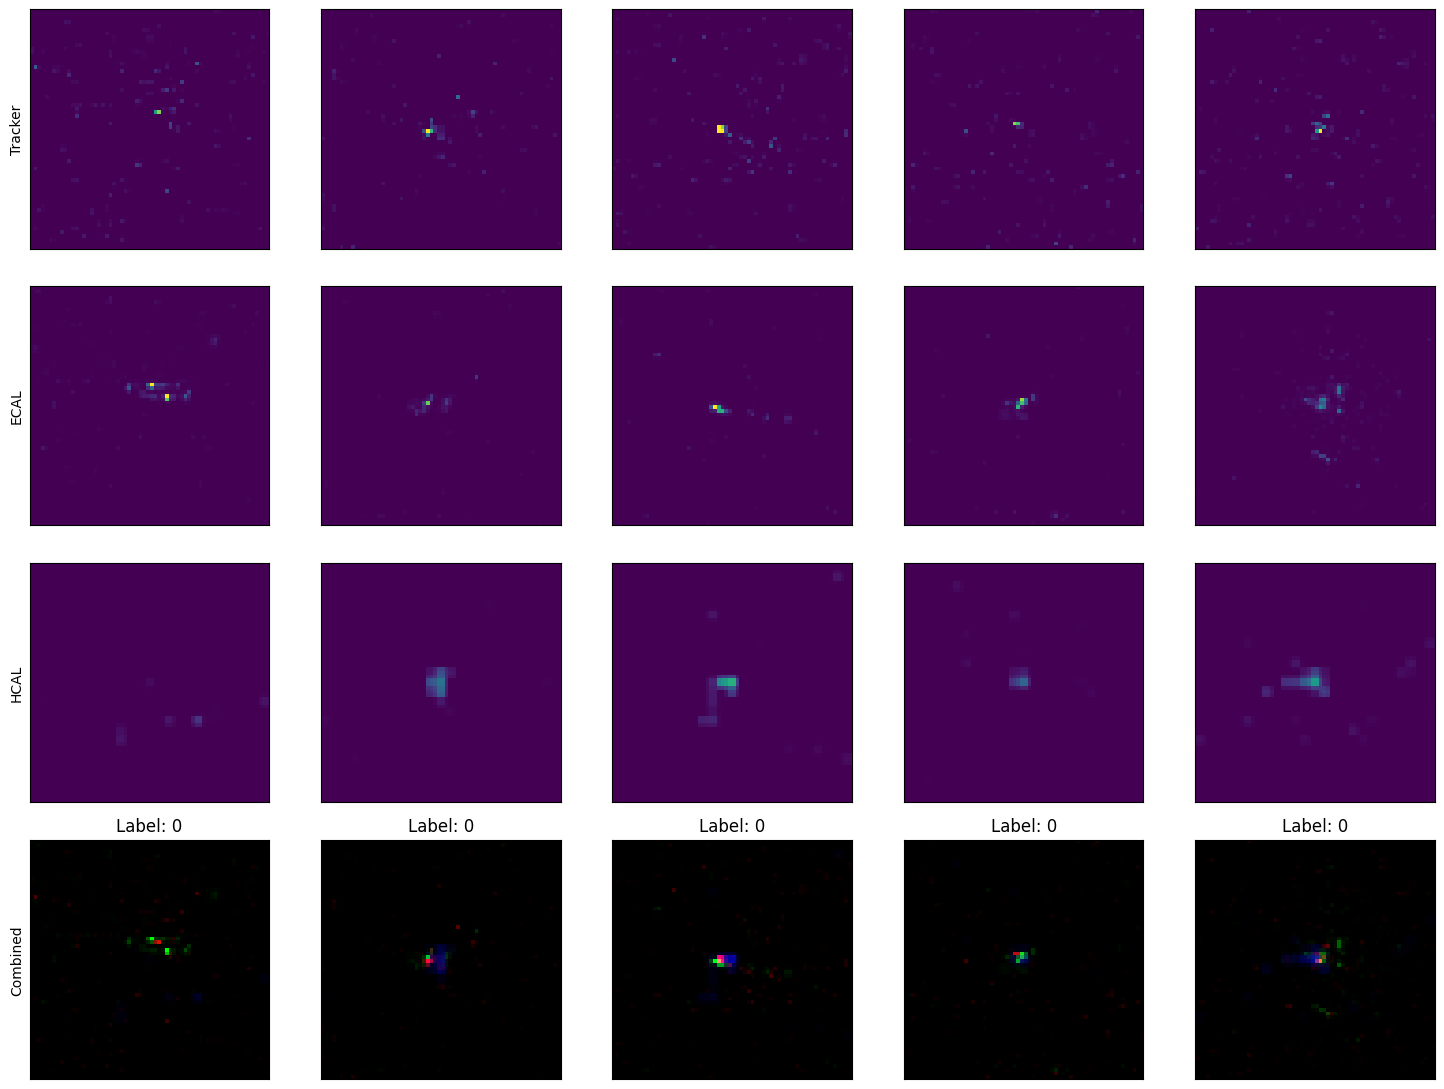

In [11]:
imagenes_ejemplo = np.stack([train_dataset[i][0].numpy() for i in range(5)])
etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]
ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

## Latent Compression and Reconstruction

The convolutional VAE maps each $64\times64$ three-channel jet image to a standardized latent tensor with shape $4\times16\times16$. Its occupancy-aware decoder and physics diagnostics are reused throughout the classical and quantum diffusion experiments.

In [12]:
class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                out_channels,
            ),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.block(x)

In [13]:
class SimpleConvVAE16Occupancy(nn.Module):

    def __init__(
        self,
        in_channels=3,
        latent_channels=4,
        base_channels=64,
    ):
        super().__init__()

        self.latent_channels = latent_channels

        self.encoder = nn.Sequential(

            ConvBlock(
                in_channels,
                base_channels,
                stride=1,
            ),

            ConvBlock(
                base_channels,
                base_channels * 2,
                stride=2,
            ),

            ConvBlock(
                base_channels * 2,
                base_channels * 4,
                stride=2,
            ),
        )

        self.to_mu = nn.Conv2d(
            base_channels * 4,
            latent_channels,
            kernel_size=3,
            padding=1,
        )

        self.to_log_var = nn.Conv2d(
            base_channels * 4,
            latent_channels,
            kernel_size=3,
            padding=1,
        )

        self.dec_in = ConvBlock(
            latent_channels,
            base_channels * 4,
            stride=1,
        )

        self.up1 = nn.Sequential(

            nn.ConvTranspose2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=4,
                stride=2,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                base_channels * 2,
            ),

            nn.SiLU(),
        )

        self.up2 = nn.Sequential(

            nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=4,
                stride=2,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                base_channels,
            ),

            nn.SiLU(),
        )

        self.mask_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )

        self.intensity_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )

        nn.init.zeros_(
            self.mask_head.weight
        )

        nn.init.zeros_(
            self.intensity_head.weight
        )

        mask_prior = 0.01

        mask_bias = np.log(
            mask_prior
            / (1.0 - mask_prior)
        )

        nn.init.constant_(
            self.mask_head.bias,
            float(mask_bias),
        )

        nn.init.constant_(
            self.intensity_head.bias,
            -2.0,
        )

    def encode(self, x):

        h = self.encoder(x)

        mu = self.to_mu(h)

        log_var = self.to_log_var(h)

        log_var = torch.clamp(
            log_var,
            min=-10.0,
            max=8.0,
        )

        return mu, log_var

    @staticmethod
    def reparameterize(
        mu,
        log_var,
    ):

        std = torch.exp(
            0.5 * log_var
        )

        noise = torch.randn_like(
            std
        )

        return (
            mu
            + noise * std
        )

    def decode_components(
        self,
        z,
    ):

        h = self.dec_in(z)

        h = self.up1(h)

        h = self.up2(h)

        mask_logits = (
            self.mask_head(h)
        )

        mask_probability = torch.sigmoid(
            mask_logits
        )

        intensity_logits = (
            self.intensity_head(h)
        )

        intensity_01 = torch.sigmoid(
            intensity_logits
        )

        reconstruction_01 = (
            mask_probability
            * intensity_01
        )

        reconstruction = (
            2.0 * reconstruction_01
            - 1.0
        )

        return (
            reconstruction,
            mask_logits,
            mask_probability,
            intensity_01,
        )

    def decode(
        self,
        z,
    ):

        (
            reconstruction,
            _,
            _,
            _,
        ) = self.decode_components(z)

        return reconstruction

    def decode_hard(
        self,
        z,
    ):

        (
            _,
            _,
            mask_probability,
            intensity_01,
        ) = self.decode_components(z)

        channel_thresholds = (
            get_occupancy_thresholds(
                mask_probability
            )
        )

        hard_mask = (
            mask_probability
            > channel_thresholds
        ).to(
            intensity_01.dtype
        )

        reconstruction_01 = (
            hard_mask
            * intensity_01
        )

        return (
            2.0 * reconstruction_01
            - 1.0
        )

    def forward(
        self,
        x,
        deterministic=False,
        return_components=False,
    ):

        mu, log_var = self.encode(x)

        if deterministic:

            z = mu

        else:

            z = self.reparameterize(
                mu,
                log_var,
            )

        (
            reconstruction,
            mask_logits,
            mask_probability,
            intensity_01,
        ) = self.decode_components(z)

        if return_components:

            return (
                reconstruction,
                mu,
                log_var,
                z,
                mask_logits,
                mask_probability,
                intensity_01,
            )

        return (
            reconstruction,
            mu,
            log_var,
            z,
        )

In [14]:
model_test = SimpleConvVAE16Occupancy(in_channels=3, latent_channels=LATENT_CHANNELS, base_channels=BASE_CHANNELS).to(device)

with torch.no_grad():
    output = model_test(images_batch[:2].to(device), deterministic=False, return_components=True)

reconstruction_test, mu_test, log_var_test, z_test, mask_logits_test, mask_probability_test, intensity_test = output
print('Entrada:', images_batch[:2].shape)
print('Latente:', z_test.shape)
print('Reconstrucción:', reconstruction_test.shape)
print('Máscara:', mask_probability_test.shape)
print('Intensidad:', intensity_test.shape)
print('Parámetros:', f'{sum((parameter.numel() for parameter in model_test.parameters())):,}')

Entrada: torch.Size([2, 3, 64, 64])
Latente: torch.Size([2, 4, 16, 16])
Reconstrucción: torch.Size([2, 3, 64, 64])
Máscara: torch.Size([2, 3, 64, 64])
Intensidad: torch.Size([2, 3, 64, 64])
Parámetros: 1,059,534


In [15]:
def masked_mean(values, mask, eps=1e-08):
    return (values * mask).sum() / (mask.sum() + eps)


def jet_vae_loss(
    reconstruction, target, mu, log_var, mask_logits, mask_probability, intensity_01, beta, active_thr_01=0.0001,
    active_weight=5.0, background_weight=1.0, energy_weight=1.0, background_energy_weight=0.01, mask_weight=0.1,
    occupancy_weight=2.0, false_positive_weight=0.5, peak_weight=1.0, occupancy_threshold=0.8,
    gate_temperature=0.05, topk_peak_pixels=8,
):
    target_01 = ((target + 1.0) / 2.0).clamp(0.0, 1.0)
    active_mask = (target_01 > active_thr_01).to(target_01.dtype)
    background_mask = 1.0 - active_mask
    intensity_absolute_error = torch.abs(intensity_01 - target_01)
    intensity_pixel_weight = 1.0 + 4.0 * target_01.square()
    active_intensity_loss = masked_mean(intensity_pixel_weight * intensity_absolute_error, active_mask)
    soft_gate = torch.sigmoid((mask_probability - occupancy_threshold) / gate_temperature)
    predicted_01 = soft_gate * intensity_01
    background_l1 = masked_mean(predicted_01, background_mask)
    reconstruction_loss = active_weight * active_intensity_loss + background_weight * background_l1
    predicted_active_fraction = soft_gate.mean(dim=(-2, -1))
    target_active_fraction = active_mask.mean(dim=(-2, -1))
    occupancy_loss = F.l1_loss(predicted_active_fraction, target_active_fraction)
    false_positive_loss = masked_mean(soft_gate, background_mask)
    predicted_energy = predicted_01.sum(dim=(-2, -1))
    target_energy = target_01.sum(dim=(-2, -1))
    energy_loss = F.smooth_l1_loss(torch.log1p(predicted_energy), torch.log1p(target_energy))
    false_background_energy = (predicted_01 * background_mask).sum(dim=(-2, -1))
    background_energy_loss = torch.log1p(false_background_energy).mean()
    positive_count = active_mask.sum(dim=(0, 2, 3))
    negative_count = background_mask.sum(dim=(0, 2, 3))
    positive_weight = torch.sqrt(negative_count / positive_count.clamp_min(1.0)).clamp(min=1.0, max=6.0)
    positive_weight = positive_weight.view(1, -1, 1, 1).detach()
    mask_loss = F.binary_cross_entropy_with_logits(mask_logits, active_mask, pos_weight=positive_weight)
    num_pixels = target_01.shape[-2] * target_01.shape[-1]
    k = min(topk_peak_pixels, num_pixels)
    predicted_topk = predicted_01.flatten(start_dim=2).topk(k, dim=-1).values.mean(dim=-1)
    target_topk = target_01.flatten(start_dim=2).topk(k, dim=-1).values.mean(dim=-1)
    predicted_maximum = predicted_01.amax(dim=(-2, -1))
    target_maximum = target_01.amax(dim=(-2, -1))
    topk_loss = F.l1_loss(predicted_topk, target_topk)
    maximum_loss = F.l1_loss(predicted_maximum, target_maximum)
    peak_loss = 0.5 * topk_loss + 0.5 * maximum_loss
    kl_loss = 0.5 * (mu.square() + log_var.exp() - 1.0 - log_var).mean()
    total_loss = (
        reconstruction_loss
        + energy_weight * energy_loss
        + background_energy_weight * background_energy_loss
        + mask_weight * mask_loss
        + occupancy_weight * occupancy_loss
        + false_positive_weight * false_positive_loss
        + peak_weight * peak_loss
        + beta * kl_loss
    )
    components = {
        'loss': total_loss,
        'reconstruction': reconstruction_loss,
        'active_l1': active_intensity_loss,
        'background_l1': background_l1,
        'energy': energy_loss,
        'background_energy': background_energy_loss,
        'mask_bce': mask_loss,
        'occupancy': occupancy_loss,
        'false_positive': false_positive_loss,
        'peak': peak_loss,
        'maximum': maximum_loss,
        'kl': kl_loss,
    }

    return (total_loss, components)

In [16]:
def accumulate_metrics(metric_sums, components, batch_size):
    for key, value in components.items():
        metric_sums[key] = metric_sums.get(key, 0.0) + value.detach().item() * batch_size


def average_metrics(metric_sums, n_examples):
    return {key: value / max(n_examples, 1) for key, value in metric_sums.items()}


def beta_for_epoch(epoch, beta_max, kl_start_epoch, kl_warmup_epochs):
    if epoch < kl_start_epoch:
        return 0.0

    progress = min(1.0, (epoch - kl_start_epoch + 1) / max(kl_warmup_epochs, 1))

    return beta_max * progress


@torch.no_grad()
def evaluate_vae_epoch(model, data_loader, beta, device):
    model.eval()
    totals = {}
    n_examples = 0

    for images, _ in data_loader:
        images = images.to(device)
        reconstruction, mu, log_var, _, mask_logits, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        _, components = jet_vae_loss(
            reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits,
            mask_probability=mask_probability, intensity_01=intensity_01, beta=beta,
            active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT, background_weight=BACKGROUND_WEIGHT,
            energy_weight=ENERGY_WEIGHT, background_energy_weight=BACKGROUND_ENERGY_WEIGHT,
            mask_weight=MASK_WEIGHT, occupancy_weight=OCCUPANCY_WEIGHT,
            false_positive_weight=FALSE_POSITIVE_WEIGHT, peak_weight=PEAK_WEIGHT,
            occupancy_threshold=OCCUPANCY_THRESHOLD, gate_temperature=GATE_TEMPERATURE,
            topk_peak_pixels=TOPK_PEAK_PIXELS,
        )
        batch_size = images.size(0)

        accumulate_metrics(totals, components, batch_size)
        n_examples += batch_size

    return average_metrics(totals, n_examples)


def train_jet_vae(
    train_loader, val_loader, device, beta_max, num_epochs=20, learning_rate=0.0002, patience=12,
    model_class=SimpleConvVAE16Occupancy, latent_channels=LATENT_CHANNELS,
):
    model = model_class(in_channels=3, latent_channels=latent_channels, base_channels=BASE_CHANNELS).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-06)
    history = {'train': [], 'val': [], 'beta': [], 'lr': []}
    best_validation_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        beta = beta_for_epoch(epoch=epoch, beta_max=beta_max, kl_start_epoch=KL_START_EPOCH, kl_warmup_epochs=KL_WARMUP_EPOCHS)
        model.train()
        totals = {}
        n_examples = 0

        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)
            reconstruction, mu, log_var, _, mask_logits, mask_probability, intensity_01 = model(images, deterministic=False, return_components=True)
            loss, components = jet_vae_loss(
                reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits,
                mask_probability=mask_probability, intensity_01=intensity_01, beta=beta,
                active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT,
                background_weight=BACKGROUND_WEIGHT, energy_weight=ENERGY_WEIGHT,
                background_energy_weight=BACKGROUND_ENERGY_WEIGHT, mask_weight=MASK_WEIGHT,
                occupancy_weight=OCCUPANCY_WEIGHT, false_positive_weight=FALSE_POSITIVE_WEIGHT,
                peak_weight=PEAK_WEIGHT, occupancy_threshold=OCCUPANCY_THRESHOLD,
                gate_temperature=GATE_TEMPERATURE, topk_peak_pixels=TOPK_PEAK_PIXELS,
            )

            if not torch.isfinite(loss):
                raise RuntimeError(f'Loss no finita en época {epoch + 1}: {loss.item()}')

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_size = images.size(0)
            accumulate_metrics(totals, components, batch_size)
            n_examples += batch_size

        train_metrics = average_metrics(totals, n_examples)
        validation_metrics = evaluate_vae_epoch(model=model, data_loader=val_loader, beta=beta, device=device)
        scheduler.step(validation_metrics['loss'])
        current_lr = optimizer.param_groups[0]['lr']
        history['train'].append(train_metrics)
        history['val'].append(validation_metrics)
        history['beta'].append(beta)
        history['lr'].append(current_lr)
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"beta={beta:.2e} | "
            f"lr={current_lr:.2e} | "
            f"train={train_metrics['loss']:.6f} | "
            f"val={validation_metrics['loss']:.6f} | "
            f"active={validation_metrics['active_l1']:.6f} | "
            f"bg={validation_metrics['background_l1']:.6f} | "
            f"energy={validation_metrics['energy']:.6f} | "
            f"occupancy={validation_metrics['occupancy']:.6f} | "
            f"false_pos={validation_metrics['false_positive']:.6f} | "
            f"peak={validation_metrics['peak']:.6f} | "
            f"max={validation_metrics['maximum']:.6f} | "
            f"mask={validation_metrics['mask_bce']:.6f} | "
            f"KL={validation_metrics['kl']:.6f}"
        )

        if validation_metrics['loss'] < best_validation_loss - 1e-06:
            best_validation_loss = validation_metrics['loss']
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f'Early stopping en época {epoch + 1}. Mejor val loss: {best_validation_loss:.6f}')

            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return (model.to(device), history)

In [17]:
seed_everything(SEED)
vae_model, vae_history = train_jet_vae(
    train_loader=train_loader, val_loader=val_loader, device=device, beta_max=BETA_MAX, num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, patience=20,
)

Epoch 001/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.834474 | val=0.425223 | active=0.040651 | bg=0.000799 | energy=0.029887 | occupancy=0.015065 | false_pos=0.027265 | peak=0.082031 | max=0.103014 | mask=0.528888 | KL=3.312210
Epoch 002/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.399451 | val=0.374968 | active=0.035915 | bg=0.000872 | energy=0.019487 | occupancy=0.011733 | false_pos=0.028620 | peak=0.077523 | max=0.100691 | mask=0.464680 | KL=3.855531
Epoch 003/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.340088 | val=0.317661 | active=0.032315 | bg=0.000677 | energy=0.011290 | occupancy=0.011084 | false_pos=0.022329 | peak=0.059372 | max=0.076327 | mask=0.403624 | KL=4.698293
Epoch 004/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.302993 | val=0.290517 | active=0.029528 | bg=0.000626 | energy=0.010252 | occupancy=0.011049 | false_pos=0.019298 | peak=0.054051 | max=0.071373 | mask=0.362645 | KL=4.843608
Epoch 005/40 | beta=0.00e+00 | lr=2.00e-04 | train=0.275793 | val=0.267091 | active=0.02

In [18]:
@torch.no_grad()
def calibrate_occupancy_thresholds(model, data_loader, device):
    model.eval()
    probability_batches = [[], [], []]
    target_mask_batches = [[], [], []]

    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, _ = model(images, deterministic=True, return_components=True)
        target_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        target_mask = target_01 > ACTIVE_THRESHOLD_01

        for channel_index in range(3):
            probability_batches[channel_index].append(mask_probability[:, channel_index, :, :].detach().cpu().flatten())
            target_mask_batches[channel_index].append(target_mask[:, channel_index, :, :].detach().cpu().flatten())

    results = []
    calibrated_thresholds = {}

    for channel_index, channel_name in enumerate(CHANNEL_NAMES):
        probabilities = torch.cat(probability_batches[channel_index])
        target_mask = torch.cat(target_mask_batches[channel_index]).bool()
        real_active_fraction = target_mask.float().mean().item()
        quantile_value = 1.0 - real_active_fraction
        MAX_QUANTILE_SAMPLES = 2000000

        if probabilities.numel() > MAX_QUANTILE_SAMPLES:
            generator = torch.Generator().manual_seed(42)
            indices = torch.randint(0, probabilities.numel(), (MAX_QUANTILE_SAMPLES,), generator=generator)
            probabilities_for_quantile = probabilities[indices]
        else:
            probabilities_for_quantile = probabilities

        selected_threshold = torch.quantile(probabilities_for_quantile, quantile_value).item()
        predicted_mask = probabilities > selected_threshold
        predicted_active_fraction = predicted_mask.float().mean().item()
        true_positive = (predicted_mask & target_mask).sum().item()
        false_positive = (predicted_mask & ~target_mask).sum().item()
        false_negative = (~predicted_mask & target_mask).sum().item()
        precision = true_positive / max(true_positive + false_positive, 1)
        recall = true_positive / max(true_positive + false_negative, 1)
        iou = true_positive / max(true_positive + false_positive + false_negative, 1)
        calibrated_thresholds[channel_name] = selected_threshold

        results.append({
            'Canal': channel_name,
            'Threshold calibrado': selected_threshold,
            'Fracción activa real': real_active_fraction,
            'Fracción activa calibrada': predicted_active_fraction,
            'Precision': precision,
            'Recall': recall,
            'IoU': iou,
        })

    results_dataframe = pd.DataFrame(results)

    return (calibrated_thresholds, results_dataframe)

calibrated_thresholds, calibration_results = calibrate_occupancy_thresholds(model=vae_model, data_loader=val_loader, device=device)
display(calibration_results.round(6))
print('\nValores para copiar a la celda de configuración:\n')
print(f"ECAL_OCCUPANCY_THRESHOLD = {calibrated_thresholds['ECAL']:.6f}")
print(f"HCAL_OCCUPANCY_THRESHOLD = {calibrated_thresholds['HCAL']:.6f}")
print(f"TRACKER_OCCUPANCY_THRESHOLD = {calibrated_thresholds['TRACKER']:.6f}")

TRACKER_OCCUPANCY_THRESHOLD = calibrated_thresholds['TRACKER']
ECAL_OCCUPANCY_THRESHOLD = calibrated_thresholds['ECAL']
HCAL_OCCUPANCY_THRESHOLD = calibrated_thresholds['HCAL']

,Canal,Threshold calibrado,Fracción activa real,Fracción activa calibrada,Precision,Recall,IoU
0,TRACKER,0.796628,0.041931,0.041615,0.586074,0.581661,0.412289
1,ECAL,0.811170,0.052684,0.052616,0.634884,0.634065,0.464638
2,HCAL,0.818655,0.045086,0.045259,0.869123,0.872455,0.771143



Valores para copiar a la celda de configuración:

ECAL_OCCUPANCY_THRESHOLD = 0.811170
HCAL_OCCUPANCY_THRESHOLD = 0.818655
TRACKER_OCCUPANCY_THRESHOLD = 0.796628


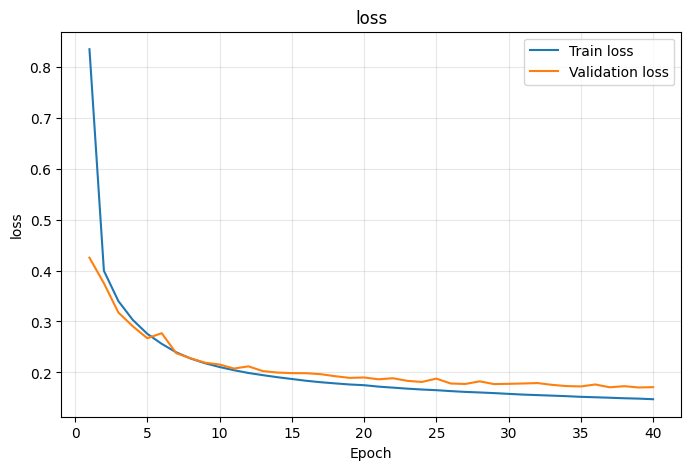

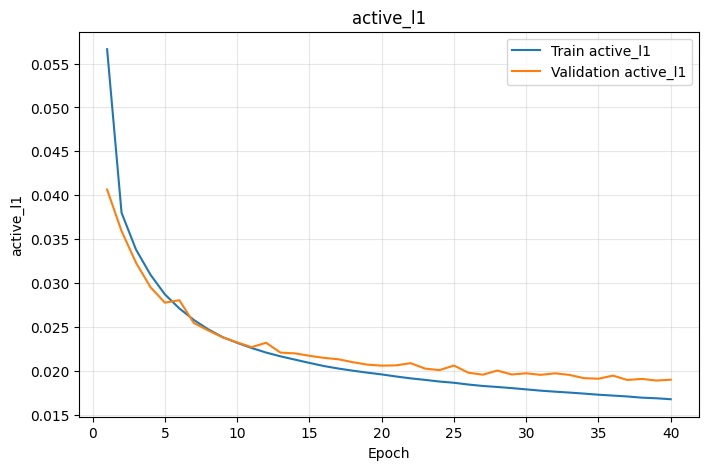

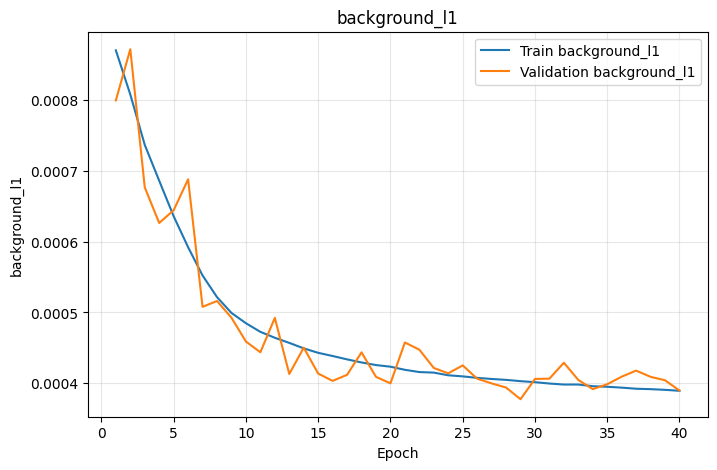

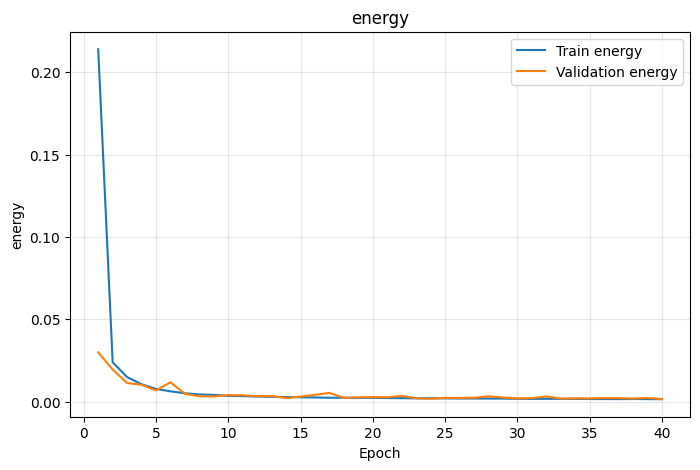

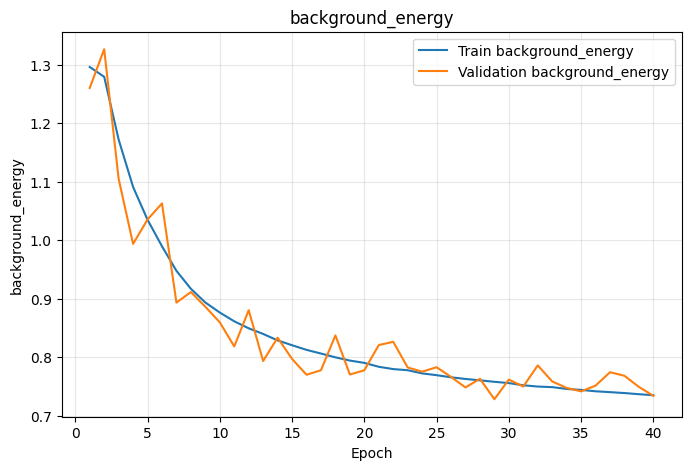

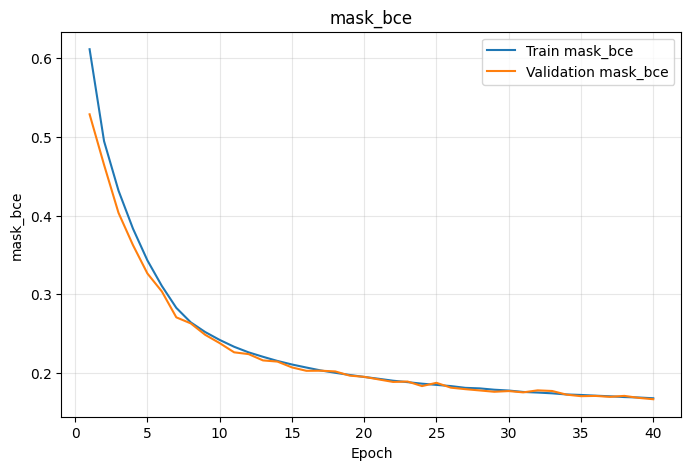

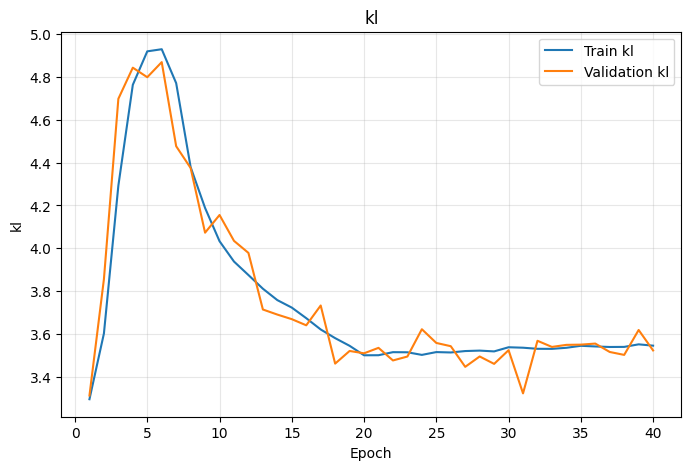

In [19]:
def plot_training_history(history):
    epochs = np.arange(1, len(history['train']) + 1)
    metrics = ['loss', 'active_l1', 'background_l1', 'energy', 'background_energy', 'mask_bce', 'kl']

    for metric in metrics:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, [item[metric] for item in history['train']], label=f'Train {metric}')
        plt.plot(epochs, [item[metric] for item in history['val']], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.title(metric)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

plot_training_history(vae_history)

In [20]:
def wasserstein_xy_per_channel(reconstruction, target, eps=1e-08):
    projection_x_reconstruction = reconstruction.sum(dim=2)
    projection_x_target = target.sum(dim=2)
    projection_y_reconstruction = reconstruction.sum(dim=3)
    projection_y_target = target.sum(dim=3)
    px_reconstruction = projection_x_reconstruction / (projection_x_reconstruction.sum(dim=-1, keepdim=True) + eps)
    px_target = projection_x_target / (projection_x_target.sum(dim=-1, keepdim=True) + eps)
    py_reconstruction = projection_y_reconstruction / (projection_y_reconstruction.sum(dim=-1, keepdim=True) + eps)
    py_target = projection_y_target / (projection_y_target.sum(dim=-1, keepdim=True) + eps)
    w1_x = torch.abs(torch.cumsum(px_reconstruction, dim=-1) - torch.cumsum(px_target, dim=-1)).sum(dim=-1)
    w1_y = torch.abs(torch.cumsum(py_reconstruction, dim=-1) - torch.cumsum(py_target, dim=-1)).sum(dim=-1)

    return (w1_x + w1_y).mean()


@torch.no_grad()
def evaluate_reconstructions(model, data_loader, device, hard_reconstruction=False):
    model.eval()
    totals = {
        'mae_01': 0.0,
        'mse_01': 0.0,
        'active_mae_01': 0.0,
        'background_mae_01': 0.0,
        'energy_relative_error': 0.0,
        'w1_xy': 0.0,
        'ssim': 0.0,
        'active_frac_real': 0.0,
        'active_frac_recon': 0.0,
    }
    n_examples = 0

    for images, _ in data_loader:
        images = images.to(device)
        reconstruction, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)

        if not hard_reconstruction:
            reconstruction_01 = ((reconstruction + 1.0) / 2.0).clamp(0.0, 1.0)
        else:
            channel_thresholds = get_occupancy_thresholds(mask_probability)
            hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
            reconstruction_01 = hard_mask * intensity_01

        active_mask = (images_01 > ACTIVE_THRESHOLD_01).to(images.dtype)
        background_mask = 1.0 - active_mask
        absolute_error = torch.abs(reconstruction_01 - images_01)
        true_energy = images_01.sum(dim=(1, 2, 3))
        reconstructed_energy = reconstruction_01.sum(dim=(1, 2, 3))
        batch_metrics = {
            'mae_01': absolute_error.mean(),
            'mse_01': F.mse_loss(reconstruction_01, images_01),
            'active_mae_01': masked_mean(absolute_error, active_mask),
            'background_mae_01': masked_mean(absolute_error, background_mask),
            'energy_relative_error': (torch.abs(reconstructed_energy - true_energy) / true_energy.clamp_min(1e-08)).mean(),
            'w1_xy': wasserstein_xy_per_channel(reconstruction_01, images_01),
            'ssim': ssim(reconstruction_01, images_01, data_range=1.0, size_average=True),
            'active_frac_real': active_mask.mean(),
            'active_frac_recon': (reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(),
        }
        batch_size = images.size(0)

        for key, value in batch_metrics.items():
            totals[key] += value.item() * batch_size

        n_examples += batch_size

    return {key: value / n_examples for key, value in totals.items()}

In [21]:
soft_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, hard_reconstruction=False)
hard_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, hard_reconstruction=True)
print('RECONSTRUCCIÓN SUAVE')

for key, value in soft_metrics.items():
    print(f'{key:28s}: {value:.8f}')

print('\nRECONSTRUCCIÓN HARD — thresholds por canal')

for key, value in hard_metrics.items():
    print(f'{key:28s}: {value:.8f}')

RECONSTRUCCIÓN SUAVE
mae_01                      : 0.00156934
mse_01                      : 0.00025713
active_mae_01               : 0.01628254
background_mae_01           : 0.00085404
energy_relative_error       : 0.29477656
w1_xy                       : 1.92517377
ssim                        : 0.96939763
active_frac_real            : 0.04638252
active_frac_recon           : 0.19671504

RECONSTRUCCIÓN HARD — thresholds por canal
mae_01                      : 0.00125510
mse_01                      : 0.00032090
active_mae_01               : 0.01885563
background_mae_01           : 0.00039955
energy_relative_error       : 0.02887939
w1_xy                       : 1.51760630
ssim                        : 0.97028871
active_frac_real            : 0.04638252
active_frac_recon           : 0.04627585


In [22]:
@torch.no_grad()
def evaluate_occupancy_head(model, data_loader, device):
    model.eval()
    true_positive = torch.zeros(3, device=device)
    false_positive = torch.zeros(3, device=device)
    false_negative = torch.zeros(3, device=device)
    predicted_active_sum = torch.zeros(3, device=device)
    real_active_sum = torch.zeros(3, device=device)
    probability_sum = torch.zeros(3, device=device)
    pixel_count = 0

    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, _ = model(images, deterministic=True, return_components=True)
        target_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        true_mask = target_01 > ACTIVE_THRESHOLD_01
        channel_thresholds = get_occupancy_thresholds(mask_probability)
        predicted_mask = mask_probability > channel_thresholds
        true_positive += (predicted_mask & true_mask).sum(dim=(0, 2, 3))
        false_positive += (predicted_mask & ~true_mask).sum(dim=(0, 2, 3))
        false_negative += (~predicted_mask & true_mask).sum(dim=(0, 2, 3))
        predicted_active_sum += predicted_mask.float().sum(dim=(0, 2, 3))
        real_active_sum += true_mask.float().sum(dim=(0, 2, 3))
        probability_sum += mask_probability.sum(dim=(0, 2, 3))
        pixel_count += images.shape[0] * images.shape[-2] * images.shape[-1]

    precision = true_positive / (true_positive + false_positive).clamp_min(1.0)
    recall = true_positive / (true_positive + false_negative).clamp_min(1.0)
    iou = true_positive / (true_positive + false_positive + false_negative).clamp_min(1.0)

    return pd.DataFrame({
        'Canal': CHANNEL_NAMES,
        'Fracción activa real': (real_active_sum / pixel_count).cpu().numpy(),
        'Fracción activa máscara': (predicted_active_sum / pixel_count).cpu().numpy(),
        'Probabilidad media': (probability_sum / pixel_count).cpu().numpy(),
        'Precision': precision.cpu().numpy(),
        'Recall': recall.cpu().numpy(),
        'IoU': iou.cpu().numpy(),
    })

occupancy_results = evaluate_occupancy_head(model=vae_model, data_loader=test_loader, device=device)
display(occupancy_results.round(6))

,Canal,Fracción activa real,Fracción activa máscara,Probabilidad media,Precision,Recall,IoU
0,TRACKER,0.041387,0.041118,0.101234,0.586187,0.582378,0.412705
1,ECAL,0.053120,0.052852,0.112034,0.636445,0.633230,0.465023
2,HCAL,0.044640,0.044858,0.065095,0.869346,0.873582,0.772199


In [23]:
@torch.no_grad()
def show_reconstructions(model, data_loader, device, num_images=6, contrast=False, channel_order=(2, 0, 1)):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images[:num_images].to(device)
    _, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
    images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
    channel_thresholds = get_occupancy_thresholds(mask_probability)
    hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
    reconstruction_01 = hard_mask * intensity_01
    images_01 = images_01.cpu()
    reconstruction_01 = reconstruction_01.cpu()
    fig, axes = plt.subplots(2, num_images, figsize=(2.8 * num_images, 5.5))

    for index in range(num_images):
        original = images_01[index][list(channel_order)]
        reconstruction = reconstruction_01[index][list(channel_order)]

        if contrast:
            active_values = original[original > 1e-06]
            vmax = torch.quantile(active_values, 0.99).item() if active_values.numel() else 1.0
            vmax = max(vmax, 1e-08)
            original_display = (original / vmax).clamp(0.0, 1.0)
            reconstruction_display = (reconstruction / vmax).clamp(0.0, 1.0)
        else:
            original_display = original
            reconstruction_display = reconstruction

        axes[0, index].imshow(original_display.permute(1, 2, 0).numpy(), origin='lower')
        axes[0, index].set_title(f'Original\nE={original.sum().item():.2f}')
        axes[0, index].axis('off')
        axes[1, index].imshow(reconstruction_display.permute(1, 2, 0).numpy(), origin='lower')
        axes[1, index].set_title(f'Reconstrucción\nE={reconstruction.sum().item():.2f}')
        axes[1, index].axis('off')

    plt.tight_layout()
    plt.show()

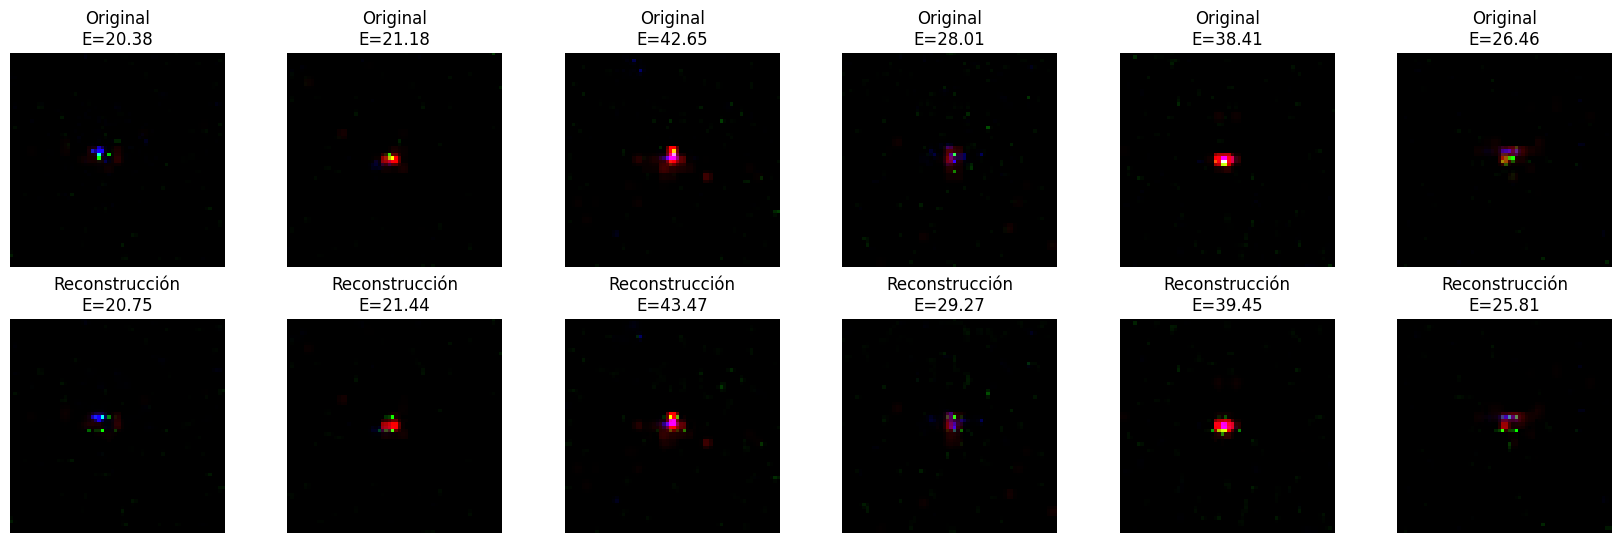

In [24]:
show_reconstructions(model=vae_model, data_loader=test_loader, device=device, contrast=False)

In [25]:
def empirical_w1(values_a, values_b):
    values_a = np.sort(np.asarray(values_a))
    values_b = np.sort(np.asarray(values_b))

    return np.mean(np.abs(values_a - values_b))


@torch.no_grad()
def collect_physics_diagnostics(model, data_loader, device, num_radial_bins=32):
    model.eval()
    energy_real_batches = []
    energy_recon_batches = []
    active_real_batches = []
    active_recon_batches = []
    max_real_batches = []
    max_recon_batches = []
    radial_real_sum = None
    radial_recon_sum = None
    radial_bin_index = None
    radial_centers = None

    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        channel_thresholds = get_occupancy_thresholds(mask_probability)
        hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
        reconstruction_01 = hard_mask * intensity_01
        images_01 = images_01.cpu()
        reconstruction_01 = reconstruction_01.cpu()
        batch_size, channels, height, width = images_01.shape

        energy_real_batches.append(images_01.sum(dim=(-2, -1)).numpy())
        energy_recon_batches.append(reconstruction_01.sum(dim=(-2, -1)).numpy())
        active_real_batches.append((images_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        active_recon_batches.append((reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        max_real_batches.append(images_01.amax(dim=(-2, -1)).numpy())
        max_recon_batches.append(reconstruction_01.amax(dim=(-2, -1)).numpy())

        if radial_bin_index is None:
            y, x = torch.meshgrid(torch.arange(height, dtype=torch.float32), torch.arange(width, dtype=torch.float32), indexing='ij')
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0
            radius = torch.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
            radial_edges = torch.linspace(0.0, radius.max().item() + 1e-06, num_radial_bins + 1)
            radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
            radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False) - 1).clamp(0, num_radial_bins - 1)
            radial_real_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
            radial_recon_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)

        real_flat = images_01.reshape(batch_size, channels, -1).double()
        recon_flat = reconstruction_01.reshape(batch_size, channels, -1).double()

        for radial_bin in range(num_radial_bins):
            mask = radial_bin_index == radial_bin
            radial_real_sum[:, radial_bin] += real_flat[:, :, mask].sum(dim=(0, 2))
            radial_recon_sum[:, radial_bin] += recon_flat[:, :, mask].sum(dim=(0, 2))

    radial_real = (radial_real_sum / radial_real_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()
    radial_recon = (radial_recon_sum / radial_recon_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()

    return {
        'energy_real': np.concatenate(energy_real_batches),
        'energy_recon': np.concatenate(energy_recon_batches),
        'active_frac_real': np.concatenate(active_real_batches),
        'active_frac_recon': np.concatenate(active_recon_batches),
        'max_real': np.concatenate(max_real_batches),
        'max_recon': np.concatenate(max_recon_batches),
        'radial_centers': radial_centers,
        'radial_real': radial_real,
        'radial_recon': radial_recon,
    }


def summarize_physics_diagnostics(diagnostics):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = diagnostics['energy_real'][:, channel]
        energy_recon = diagnostics['energy_recon'][:, channel]
        active_real = diagnostics['active_frac_real'][:, channel]
        active_recon = diagnostics['active_frac_recon'][:, channel]
        max_real = diagnostics['max_real'][:, channel]
        max_recon = diagnostics['max_recon'][:, channel]
        radial_real = diagnostics['radial_real'][channel]
        radial_recon = diagnostics['radial_recon'][channel]
        valid_energy = energy_real > 1e-06
        energy_relative_error = np.mean(np.abs(energy_recon[valid_energy] - energy_real[valid_energy]) / energy_real[valid_energy])
        energy_mean_real = energy_real.mean()
        energy_mean_recon = energy_recon.mean()

        rows.append({
            'Canal': channel_name,
            'E real media': energy_mean_real,
            'E recon media': energy_mean_recon,
            'Bias E (%)': 100.0 * (energy_mean_recon - energy_mean_real) / max(energy_mean_real, 1e-08),
            'Error relativo E (%)': 100.0 * energy_relative_error,
            'W1 energía': empirical_w1(energy_real, energy_recon),
            'Fracción activa real': active_real.mean(),
            'Fracción activa recon': active_recon.mean(),
            'Diferencia activa (p.p.)': 100.0 * (active_recon.mean() - active_real.mean()),
            'Máximo real medio': max_real.mean(),
            'Máximo recon medio': max_recon.mean(),
            'W1 máximo': empirical_w1(max_real, max_recon),
            'Radial L1': np.abs(radial_recon - radial_real).sum(),
            'Radial L2': np.sqrt(np.mean((radial_recon - radial_real) ** 2)),
        })

    return pd.DataFrame(rows)

In [26]:
diagnostics = collect_physics_diagnostics(model=vae_model, data_loader=test_loader, device=device, num_radial_bins=32)
physics_summary = summarize_physics_diagnostics(diagnostics)
display(physics_summary.round(6))

,Canal,E real media,E recon media,Bias E (%),Error relativo E (%),W1 energía,Fracción activa real,Fracción activa recon,Diferencia activa (p.p.),Máximo real medio,Máximo recon medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,7.456671,7.890220,5.814236,8.386520,0.433548,0.041387,0.041118,-0.026894,0.847103,0.863391,0.016786,0.146125,0.011066
1,ECAL,7.516253,7.236193,-3.726056,6.326166,0.298561,0.053120,0.052852,-0.026855,0.815551,0.815335,0.013872,0.053088,0.003078
2,HCAL,10.180333,10.111298,-0.678126,3.602562,0.074364,0.044640,0.044858,0.021748,0.483430,0.493838,0.010741,0.015122,0.001041


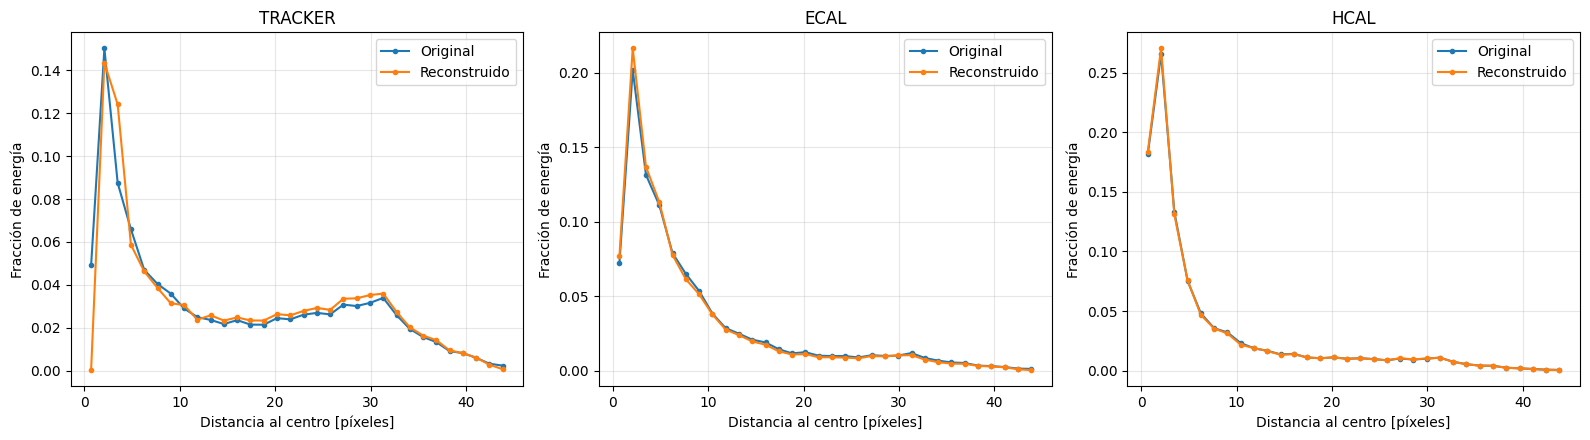

In [27]:
def plot_radial_profiles(diagnostics):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        axes[channel].plot(diagnostics['radial_centers'], diagnostics['radial_real'][channel], marker='o', markersize=3, label='Original')
        axes[channel].plot(diagnostics['radial_centers'], diagnostics['radial_recon'][channel], marker='o', markersize=3, label='Reconstruido')
        axes[channel].set_title(channel_name)
        axes[channel].set_xlabel('Distancia al centro [píxeles]')
        axes[channel].set_ylabel('Fracción de energía')
        axes[channel].legend()
        axes[channel].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_radial_profiles(diagnostics)

In [28]:
def common_histogram_bins(real_values, reconstructed_values, num_bins=50, upper_quantile=0.999):
    if num_bins < 1:
        raise ValueError('num_bins debe ser al menos 1.')

    if not 0.0 < upper_quantile <= 1.0:
        raise ValueError('upper_quantile debe estar en (0,1].')

    real_values = np.asarray(real_values, dtype=np.float64).reshape(-1)
    reconstructed_values = np.asarray(reconstructed_values, dtype=np.float64).reshape(-1)
    combined = np.concatenate([real_values, reconstructed_values])
    combined = combined[np.isfinite(combined)]

    if combined.size == 0:
        raise ValueError('No hay valores finitos para construir el histograma.')

    lower = combined.min()
    upper = np.quantile(combined, upper_quantile)

    if upper <= lower:
        upper = lower + 1e-06

    return np.linspace(lower, upper, num_bins + 1)

In [29]:
def plot_integrated_intensity_distributions(diagnostics, num_bins=50, upper_quantile=0.999):
    energy_real = np.asarray(diagnostics['energy_real'])
    energy_recon = np.asarray(diagnostics['energy_recon'])

    if energy_real.shape != energy_recon.shape:
        raise ValueError('Los arreglos real y reconstruido deben tener la misma forma.')

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()
    total_real = energy_real.sum(axis=1)
    total_recon = energy_recon.sum(axis=1)
    bins = common_histogram_bins(total_real, total_recon, num_bins=num_bins, upper_quantile=upper_quantile)
    real_weights = np.full(total_real.shape, 100.0 / len(total_real))
    recon_weights = np.full(total_recon.shape, 100.0 / len(total_recon))

    axes[0].hist(total_real, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
    axes[0].hist(total_recon, bins=bins, weights=recon_weights, histtype='step', linewidth=2, label='Reconstruido')
    axes[0].set_title('Intensidad integrada total')
    axes[0].set_xlabel('Suma de intensidades normalizadas')
    axes[0].set_ylabel('Eventos por intervalo (%)')
    axes[0].set_xlim(bins[0], bins[-1])
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values = energy_real[:, channel]
        recon_values = energy_recon[:, channel]
        bins = common_histogram_bins(real_values, recon_values, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights = np.full(real_values.shape, 100.0 / len(real_values))
        recon_weights = np.full(recon_values.shape, 100.0 / len(recon_values))
        axis = axes[channel + 1]

        axis.hist(real_values, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
        axis.hist(recon_values, bins=bins, weights=recon_weights, histtype='step', linewidth=2, label='Reconstruido')
        axis.set_title(f'Intensidad integrada: {channel_name}')
        axis.set_xlabel('Suma de intensidades normalizadas')
        axis.set_ylabel('Eventos por intervalo (%)')
        axis.set_xlim(bins[0], bins[-1])
        axis.legend()
        axis.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return (fig, axes)

In [30]:
def plot_channel_distributions(diagnostics, metric, num_bins=50, upper_quantile=1.0, class_name=None):
    if metric == 'energy':
        real_data = np.asarray(diagnostics['energy_real'])
        generated_data = np.asarray(diagnostics['energy_recon'])
        title_prefix = 'Energía integrada'
        x_label = 'Suma de intensidades normalizadas'
    elif metric == 'active_fraction':
        real_data = np.asarray(diagnostics['active_frac_real']) * 100.0
        generated_data = np.asarray(diagnostics['active_frac_recon']) * 100.0
        title_prefix = 'Fracción activa'
        x_label = 'Píxeles activos por jet (%)'
    elif metric == 'maximum':
        real_data = np.asarray(diagnostics['max_real'])
        generated_data = np.asarray(diagnostics['max_recon'])
        title_prefix = 'Intensidad máxima'
        x_label = 'Intensidad máxima normalizada'
    else:
        raise ValueError("metric debe ser 'energy', 'active_fraction' o 'maximum'.")

    if real_data.shape != generated_data.shape:
        raise ValueError('Los arreglos reales y generados deben tener la misma forma.')

    if real_data.ndim != 2:
        raise ValueError('Los datos deben tener shape [N, C].')

    fig, axes = plt.subplots(1, len(CHANNEL_NAMES), figsize=(16, 4.5))

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values = real_data[:, channel]
        generated_values = generated_data[:, channel]
        bins = common_histogram_bins(real_values, generated_values, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights = np.full(real_values.shape, 100.0 / len(real_values))
        generated_weights = np.full(generated_values.shape, 100.0 / len(generated_values))

        axes[channel].hist(real_values, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
        axes[channel].hist(generated_values, bins=bins, weights=generated_weights, histtype='step', linewidth=2, label='Generado')

        if class_name is None:
            title = f'{title_prefix}: {channel_name}'
        else:
            title = f'{title_prefix}: {channel_name} — {class_name}'

        axes[channel].set_title(title)
        axes[channel].set_xlabel(x_label)
        axes[channel].set_ylabel('Jets por intervalo (%)')
        axes[channel].set_xlim(bins[0], bins[-1])
        axes[channel].legend()
        axes[channel].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return (fig, axes)

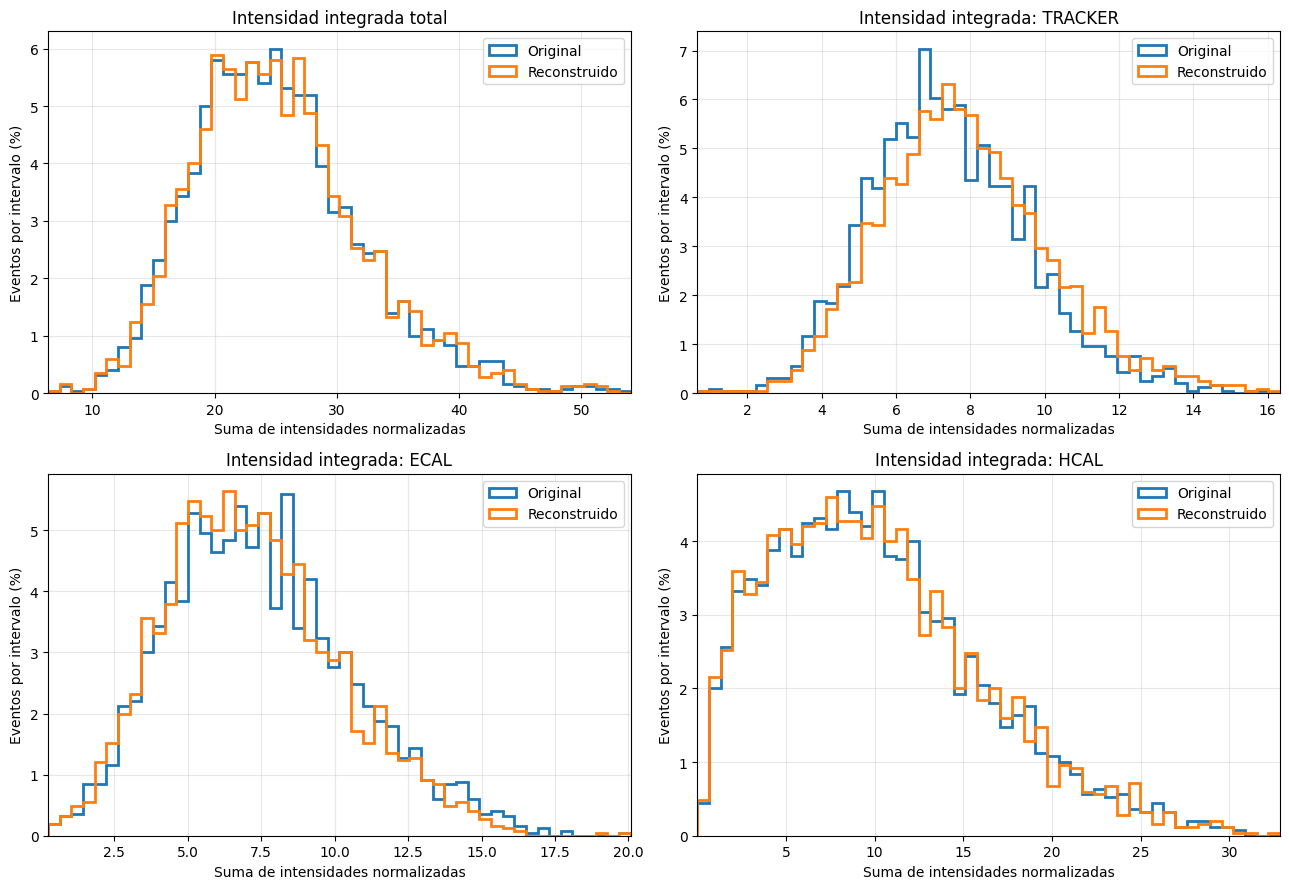

(<Figure size 1300x900 with 4 Axes>,
 array([<Axes: title={'center': 'Intensidad integrada total'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: TRACKER'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: ECAL'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: HCAL'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>],
       dtype=object))

In [31]:
plot_integrated_intensity_distributions(diagnostics, num_bins=50, upper_quantile=0.999)

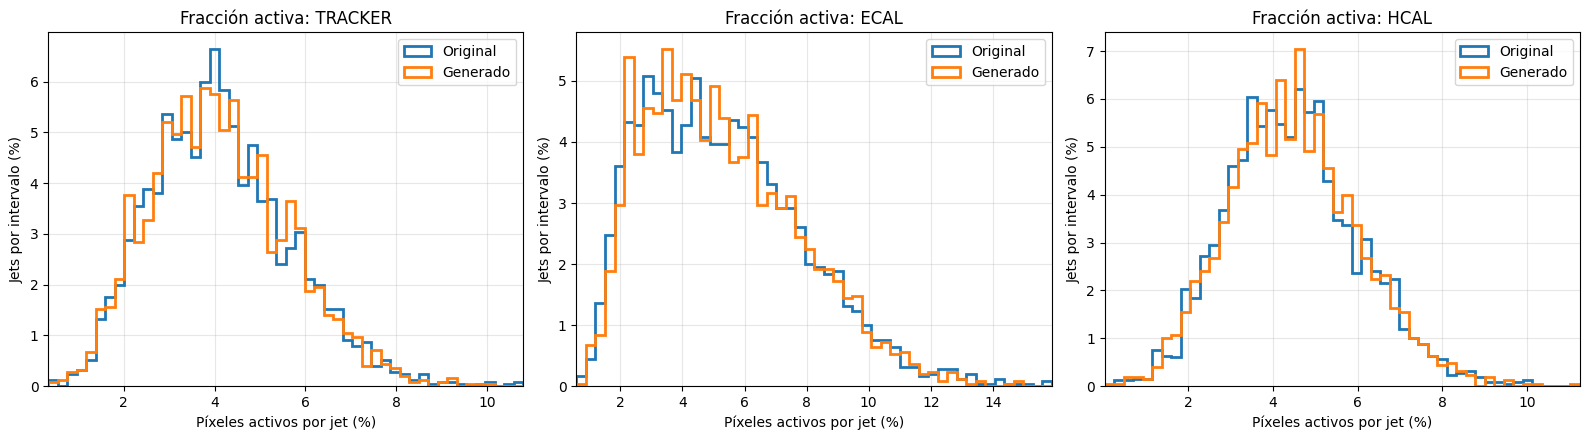

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [32]:
plot_channel_distributions(diagnostics, metric='active_fraction', num_bins=50)

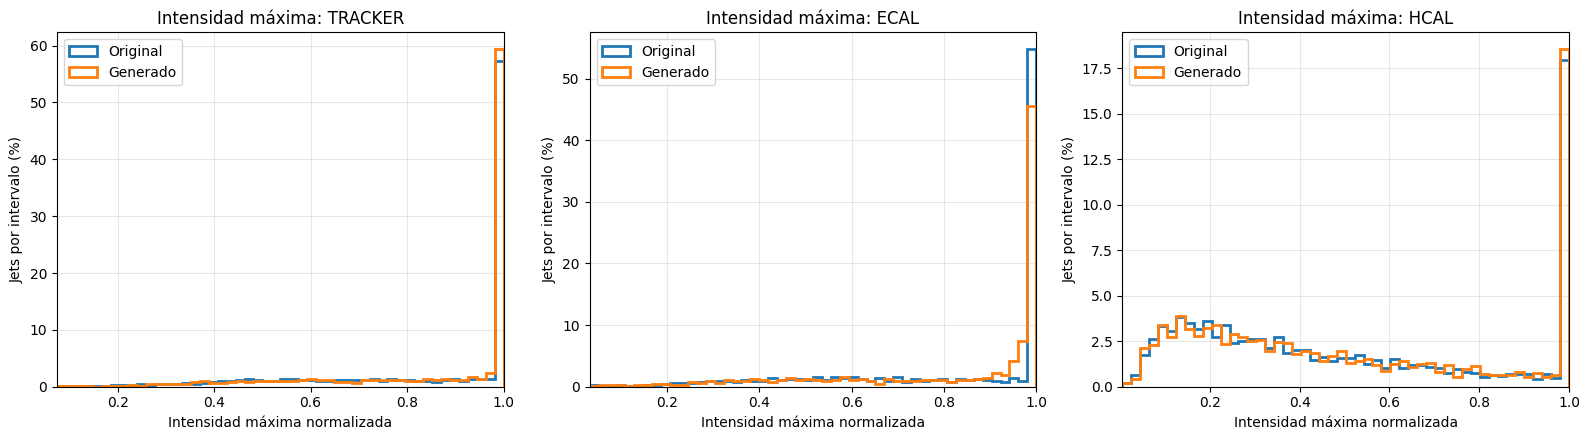

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [33]:
plot_channel_distributions(diagnostics, metric='maximum', num_bins=50, upper_quantile=1.0)

In [34]:
@torch.no_grad()
def inspect_vae_latents(model, data_loader, device):
    model.eval()
    mu_batches = []
    log_var_batches = []
    z_batches = []

    for images, _ in data_loader:
        images = images.to(device)
        mu, log_var = model.encode(images)
        z = model.reparameterize(mu, log_var)

        mu_batches.append(mu.cpu())
        log_var_batches.append(log_var.cpu())
        z_batches.append(z.cpu())

    mu_all = torch.cat(mu_batches)
    log_var_all = torch.cat(log_var_batches)
    z_all = torch.cat(z_batches)
    rows = []

    for channel in range(mu_all.shape[1]):
        rows.append({
            'Canal latente': channel,
            'mu media': mu_all[:, channel].mean().item(),
            'mu std': mu_all[:, channel].std().item(),
            'logvar media': log_var_all[:, channel].mean().item(),
            'logvar std': log_var_all[:, channel].std().item(),
            'z media': z_all[:, channel].mean().item(),
            'z std': z_all[:, channel].std().item(),
            'z mínimo': z_all[:, channel].min().item(),
            'z máximo': z_all[:, channel].max().item(),
        })

    global_stats = {
        'mu_mean': mu_all.mean().item(),
        'mu_std': mu_all.std().item(),
        'logvar_mean': log_var_all.mean().item(),
        'logvar_std': log_var_all.std().item(),
        'z_mean': z_all.mean().item(),
        'z_std': z_all.std().item(),
        'latent_shape': tuple(z_all.shape),
    }

    return (pd.DataFrame(rows), global_stats)

latent_channel_stats, latent_global_stats = inspect_vae_latents(model=vae_model, data_loader=test_loader, device=device)
display(latent_channel_stats.round(6))
print('\nESTADÍSTICAS GLOBALES')

for key, value in latent_global_stats.items():
    print(f'{key}: {value}')

,Canal latente,mu media,mu std,logvar media,logvar std,z media,z std,z mínimo,z máximo
0,0,-1.398337,0.963717,-6.929255,1.003340,-1.398319,0.964467,-7.824456,20.785696
1,1,-0.610123,1.054820,-6.759172,0.986916,-0.610098,1.055652,-8.809048,17.366529
2,2,0.260951,0.838980,-6.450883,0.956917,0.260988,0.840337,-15.461252,11.630702
3,3,-0.529858,0.854897,-6.634274,0.869916,-0.529888,0.855986,-11.562786,13.893129



ESTADÍSTICAS GLOBALES
mu_mean: -0.5693418979644775
mu_std: 1.1018134355545044
logvar_mean: -6.693396091461182
logvar_std: 0.9715191721916199
z_mean: -0.5693293213844299
z_std: 1.1026490926742554
latent_shape: (2500, 4, 16, 16)


In [35]:
LDM_BATCH_SIZE = 64
LDM_ENCODING_BATCH_SIZE = 64
vae_model.eval()

for parameter in vae_model.parameters():
    parameter.requires_grad_(False)

print('VAE congelado para el entrenamiento del LDM.')

VAE congelado para el entrenamiento del LDM.


In [36]:
@torch.no_grad()
def encode_dataset_to_mu(model, dataset, device, batch_size=64):
    model.eval()
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    mu_batches = []
    label_batches = []

    for images, labels in tqdm(data_loader, desc='Codificando latentes'):
        images = images.to(device, non_blocking=True)
        mu, _ = model.encode(images)
        mu_batches.append(mu.detach().cpu())
        label_batches.append(labels.detach().cpu())

    mu_all = torch.cat(mu_batches, dim=0)
    labels_all = torch.cat(label_batches, dim=0)

    return (mu_all, labels_all)

In [37]:
ldm_train_mu, ldm_train_labels = encode_dataset_to_mu(model=vae_model, dataset=train_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_val_mu, ldm_val_labels = encode_dataset_to_mu(model=vae_model, dataset=val_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_test_mu, ldm_test_labels = encode_dataset_to_mu(model=vae_model, dataset=test_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)

print('Train:', ldm_train_mu.shape)
print('Validation:', ldm_val_mu.shape)
print('Test:', ldm_test_mu.shape)

Codificando latentes: 100%|██████████| 40/40 [00:00<00:00, 50.75it/s]

Train: torch.Size([10000, 4, 16, 16])
Validation: torch.Size([2500, 4, 16, 16])
Test: torch.Size([2500, 4, 16, 16])


In [38]:
latent_mean_train = ldm_train_mu.mean(dim=(0, 2, 3), keepdim=True)
latent_std_train = ldm_train_mu.std(dim=(0, 2, 3), keepdim=True, unbiased=False).clamp_min(1e-06)
print('Media latente de entrenamiento:', latent_mean_train.flatten().numpy())
print('Std latente de entrenamiento:', latent_std_train.flatten().numpy())

Media latente de entrenamiento: [-1.4001296 -0.6100698  0.2607065 -0.5278346]
Std latente de entrenamiento: [0.96266276 1.0544891  0.84127533 0.8565361 ]


In [39]:
def standardize_latents(latent_tensor, latent_mean, latent_std):
    return (latent_tensor - latent_mean) / latent_std.clamp_min(1e-06)

In [40]:
ldm_train_latents = standardize_latents(ldm_train_mu, latent_mean_train, latent_std_train)
ldm_val_latents = standardize_latents(ldm_val_mu, latent_mean_train, latent_std_train)
ldm_test_latents = standardize_latents(ldm_test_mu, latent_mean_train, latent_std_train)

In [41]:
del ldm_train_mu
del ldm_val_mu
del ldm_test_mu

In [42]:
def summarize_latent_tensor(latent_tensor, name):
    channel_mean = latent_tensor.mean(dim=(0, 2, 3))
    channel_std = latent_tensor.std(dim=(0, 2, 3), unbiased=False)
    absolute_latents = latent_tensor.abs()

    print(f'\n{name}')
    print('Shape:', tuple(latent_tensor.shape))
    print('Media por canal:', channel_mean.numpy())
    print('Std por canal:', channel_std.numpy())
    print('Media global:', latent_tensor.mean().item())
    print('Std global:', latent_tensor.std(unbiased=False).item())
    print('Mínimo:', latent_tensor.min().item())
    print('Máximo:', latent_tensor.max().item())
    print('Fracción |z| > 4:', (absolute_latents > 4.0).float().mean().item())
    print('Fracción |z| > 6:', (absolute_latents > 6.0).float().mean().item())

In [43]:
summarize_latent_tensor(ldm_train_latents, 'LATENTES DE ENTRENAMIENTO')
summarize_latent_tensor(ldm_val_latents, 'LATENTES DE VALIDACIÓN')
summarize_latent_tensor(ldm_test_latents, 'LATENTES DE TEST')


LATENTES DE ENTRENAMIENTO
Shape: (10000, 4, 16, 16)
Media por canal: [ 1.0580331e-06 -1.9131992e-06 -4.0697305e-08  6.4496101e-07]
Std por canal: [1. 1. 1. 1.]
Media global: -6.141662822756189e-08
Std global: 1.0
Mínimo: -18.976303100585938
Máximo: 24.71910858154297
Fracción |z| > 4: 0.009009081870317459
Fracción |z| > 6: 0.0037118163891136646

LATENTES DE VALIDACIÓN
Shape: (2500, 4, 16, 16)
Media por canal: [ 0.00162826 -0.00129416 -0.00110589 -0.00249234]
Std por canal: [0.996615  1.0027003 0.9994823 0.9985744]
Media global: -0.0008160307770594954
Std global: 0.9993465542793274
Mínimo: -14.459972381591797
Máximo: 21.770713806152344
Fracción |z| > 4: 0.00896132830530405
Fracción |z| > 6: 0.0036781250964850187

LATENTES DE TEST
Shape: (2500, 4, 16, 16)
Media por canal: [ 1.8616167e-03 -5.0544626e-05  2.9104692e-04 -2.3625519e-03]
Std por canal: [1.0010947  1.0003126  0.99727136 0.9980855 ]
Media global: -6.510887033073232e-05
Std global: 0.9991934299468994
Mínimo: -18.675540924072266


In [44]:
ldm_train_dataset = TensorDataset(ldm_train_latents, ldm_train_labels)
ldm_val_dataset = TensorDataset(ldm_val_latents, ldm_val_labels)
ldm_test_dataset = TensorDataset(ldm_test_latents, ldm_test_labels)

In [45]:
ldm_train_generator = torch.Generator().manual_seed(SEED)
ldm_train_loader = DataLoader(ldm_train_dataset, batch_size=LDM_BATCH_SIZE, shuffle=True, num_workers=0, generator=ldm_train_generator)
ldm_val_loader = DataLoader(ldm_val_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0)
ldm_test_loader = DataLoader(ldm_test_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0)

In [46]:
def build_fixed_validation_conditions(data_loader, num_timesteps, seed=SEED + 1000):
    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)
    fixed_conditions = []

    for z0, _ in data_loader:
        batch_size = z0.shape[0]
        timesteps = torch.randint(low=0, high=num_timesteps, size=(batch_size,), generator=generator, dtype=torch.long)
        noise = torch.randn(z0.shape, generator=generator, dtype=torch.float32)

        fixed_conditions.append((timesteps, noise))

    return fixed_conditions

In [47]:
unique_labels, label_counts = torch.unique(ldm_train_labels, return_counts=True)
print('Etiquetas presentes:', unique_labels.tolist())
print('Número de ejemplos:', label_counts.tolist())

for label, count in zip(unique_labels.tolist(), label_counts.tolist()):
    print(f'Clase {label}: {count} ejemplos ({100.0 * count / len(ldm_train_labels):.2f}%)')

Etiquetas presentes: [0, 1]
Número de ejemplos: [5038, 4962]
Clase 0: 5038 ejemplos (50.38%)
Clase 1: 4962 ejemplos (49.62%)


## Classical Latent-Diffusion Baseline

The conditional U-Net predicts the velocity target from a noisy latent, a diffusion timestep, and the jet class. The same scheduler, validation noise, loss, decoder, and physics metrics are retained as shared controls for the quantum experiments.

In [48]:
class LinearNoiseScheduler:
    def __init__(self, num_timesteps, beta_s, beta_e, device):
        self.num_timesteps = num_timesteps
        self.beta_s = beta_s
        self.beta_e = beta_e
        self.device = device

        self.betas = torch.linspace(beta_s, beta_e, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        alpha_cum_prod_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_cum_prod[:-1]], dim=0)
        self.posterior_variance = (self.betas * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef1 = (self.betas * torch.sqrt(alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))
        self.posterior_mean_coef2 = (torch.sqrt(self.alphas) * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod))

    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)

    def _extract(self, arr, t, x_shape):
        out = arr.gather(0, t)

        return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha_cum_prod_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_cum_prod_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        xt = sqrt_alpha_cum_prod_t * x0 + sqrt_one_minus_alpha_cum_prod_t * noise

        return xt, noise

    @torch.no_grad()
    def sample_prev_timestep_v(self, xt, v_pred, t, clip_x0=True):

        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)

        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        x0_pred = sqrt_alpha_bar_t * xt - sqrt_one_minus_alpha_bar_t * v_pred

        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        if t_int == 0:
            return x0_pred, x0_pred

        posterior_mean = (self.posterior_mean_coef1[t_int] * x0_pred + self.posterior_mean_coef2[t_int] * xt)
        posterior_var = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)
        x_prev = posterior_mean + torch.sqrt(posterior_var) * noise

        return x_prev, x0_pred

In [49]:
def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g

    return 1


def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]

    timesteps = timesteps.float()
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))
    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))

    return emb


class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()

        self.t_emb_dim = t_emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)

        return self.mlp(t_emb)

In [50]:
class SimpleConditionedConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.norm = nn.GroupNorm(
            get_num_groups(out_channels),
            out_channels,
        )

        self.condition_projection = nn.Linear(
            condition_dim,
            out_channels,
        )

    def forward(
        self,
        x,
        condition_embedding,
    ):
        h = self.conv(x)

        h = self.norm(h)

        condition = (
            self.condition_projection(
                F.silu(condition_embedding)
            )
            [:, :, None, None]
        )

        h = h + condition

        h = F.silu(h)

        return h


class ReducedDownBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
    ):
        super().__init__()

        self.block = SimpleConditionedConvBlock(
            in_channels=in_channels,
            out_channels=out_channels,
            condition_dim=condition_dim,
        )

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

    def forward(
        self,
        x,
        condition_embedding,
    ):

        x = self.block(
            x,
            condition_embedding,
        )

        skip = x

        x = self.downsample(x)

        return x, skip


class ReducedUpBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        condition_dim,
    ):
        super().__init__()

        self.upsample = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
        )

        self.block = SimpleConditionedConvBlock(
            in_channels=(
                out_channels
                + skip_channels
            ),
            out_channels=out_channels,
            condition_dim=condition_dim,
        )

    def forward(
        self,
        x,
        skip,
        condition_embedding,
    ):

        x = self.upsample(x)

        if x.shape[-2:] != skip.shape[-2:]:

            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="nearest",
            )

        x = torch.cat(
            [x, skip],
            dim=1,
        )

        x = self.block(
            x,
            condition_embedding,
        )

        return x


class ReducedConditionalUNET(nn.Module):

    def __init__(
        self,
        im_channels=4,
        base_channels=32,
        channel_mults=(1, 2, 4),
        t_emb_dim=128,
        num_classes=2,
        time_embedding_module=None,
    ):
        super().__init__()

        self.im_channels = im_channels
        self.num_classes = num_classes
        self.condition_dim = t_emb_dim

        if time_embedding_module is None:

            self.time_mlp = TimeEmbedding(
                t_emb_dim
            )

        else:

            self.time_mlp = (
                time_embedding_module
            )

        self.class_embedding = nn.Embedding(
            num_classes,
            t_emb_dim,
        )

        nn.init.normal_(
            self.class_embedding.weight,
            mean=0.0,
            std=0.02,
        )

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )

        channels = [
            base_channels * multiplier
            for multiplier
            in channel_mults
        ]

        self.channels = channels

        self.downs = nn.ModuleList()

        in_channels = base_channels

        for out_channels in channels:

            self.downs.append(
                ReducedDownBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    condition_dim=t_emb_dim,
                )
            )

            in_channels = out_channels

        mid_channels = channels[-1]

        self.bottleneck_channels = (
            mid_channels
        )

        self.mid = SimpleConditionedConvBlock(
            in_channels=mid_channels,
            out_channels=mid_channels,
            condition_dim=t_emb_dim,
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(
            reversed(channels)
        )

        in_channels = mid_channels

        for i, skip_channels in enumerate(
            reversed_channels
        ):

            if i < (
                len(reversed_channels) - 1
            ):

                out_channels = (
                    reversed_channels[
                        i + 1
                    ]
                )

            else:

                out_channels = (
                    base_channels
                )

            self.ups.append(
                ReducedUpBlock(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    condition_dim=t_emb_dim,
                )
            )

            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(
                base_channels
            ),
            base_channels,
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(
        self,
        x,
        t,
        labels,
    ):

        time_embedding = (
            self.time_mlp(t)
        )

        labels = labels.long()

        class_embedding = (
            self.class_embedding(
                labels
            )
        )

        condition_embedding = (
            time_embedding
            + class_embedding
        )

        x = self.conv_in(x)

        skips = []

        for down in self.downs:

            x, skip = down(
                x,
                condition_embedding,
            )

            skips.append(skip)

        x = self.mid(
            x,
            condition_embedding,
        )

        for up in self.ups:

            skip = skips.pop()

            x = up(
                x,
                skip,
                condition_embedding,
            )

        x = self.norm_out(x)

        x = F.silu(x)

        return self.conv_out(x)

In [51]:
LDM_NUM_TIMESTEPS = 1000
LDM_BETA_START = 0.0001
LDM_BETA_END = 0.02
LDM_NUM_EPOCHS = 100
LDM_LEARNING_RATE = 0.0001
LDM_GRAD_CLIP = 1.0
NUM_CLASSES = 2

In [52]:
seed_everything(SEED)
ldm_scheduler = LinearNoiseScheduler(num_timesteps=LDM_NUM_TIMESTEPS, beta_s=LDM_BETA_START, beta_e=LDM_BETA_END, device=device)
FIXED_LDM_VAL_CONDITIONS = build_fixed_validation_conditions(data_loader=ldm_val_loader, num_timesteps=LDM_NUM_TIMESTEPS)
print('Condiciones fijas de validación:', len(FIXED_LDM_VAL_CONDITIONS))
ldm_model_first = ReducedConditionalUNET(im_channels=4, base_channels=32, channel_mults=(1, 2, 4), t_emb_dim=128, num_classes=NUM_CLASSES).to(device)
ldm_num_parameters = sum((parameter.numel() for parameter in ldm_model_first.parameters() if parameter.requires_grad))
print(f'Parámetros entrenables del LDM: {ldm_num_parameters:,}')
print('Shape esperada:', '(B, 4, 16, 16)')

Condiciones fijas de validación: 40
Parámetros entrenables del LDM: 1,127,876
Shape esperada: (B, 4, 16, 16)


In [53]:
ldm_model_first.eval()
z_test = ldm_train_latents[:2].float().to(device)
t_test = torch.tensor([100, 700], dtype=torch.long, device=device)
labels_test = ldm_train_labels[:2].long().to(device)
bottleneck_shapes = {}


def bottleneck_hook(module, inputs, output):
    bottleneck_shapes['output'] = tuple(output.shape)

hook_handle = ldm_model_first.mid.register_forward_hook(bottleneck_hook)

with torch.no_grad():
    output_test = ldm_model_first(z_test, t_test, labels_test)

hook_handle.remove()
print('Input:', z_test.shape)
print('Bottleneck:', bottleneck_shapes['output'])
print('Output:', output_test.shape)
print('Valores finitos:', torch.isfinite(output_test).all().item())
print('Parámetros:', sum((p.numel() for p in ldm_model_first.parameters() if p.requires_grad)))

Input: torch.Size([2, 4, 16, 16])
Bottleneck: (2, 128, 2, 2)
Output: torch.Size([2, 4, 16, 16])
Valores finitos: True
Parámetros: 1127876


In [54]:
ldm_model_first.zero_grad(set_to_none=True)
ldm_model_first.eval()

ReducedConditionalUNET(
  (time_mlp): TimeEmbedding(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (class_embedding): Embedding(2, 128)
  (conv_in): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): ReducedDownBlock(
      (block): SimpleConditionedConvBlock(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): GroupNorm(8, 32, eps=1e-05, affine=True)
        (condition_projection): Linear(in_features=128, out_features=32, bias=True)
      )
      (downsample): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    )
    (1): ReducedDownBlock(
      (block): SimpleConditionedConvBlock(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): GroupNorm(8, 64, eps=1e-05, affine=True)
        (condition_project

In [55]:
def compute_v_target(z0, noise, timesteps, scheduler):
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    v_target = sqrt_alpha_bar * noise - sqrt_one_minus_alpha_bar * z0

    return v_target

In [56]:
ldm_model_first.train()
z_batch = ldm_train_latents[:2].float().to(device)
labels_batch = ldm_train_labels[:2].long().to(device)
timesteps_batch = torch.tensor([100, 700], dtype=torch.long, device=device)
noise_batch = torch.randn_like(z_batch)
z_noisy, noise_used = ldm_scheduler.add_noise(z_batch, timesteps_batch, noise_batch)
v_target_batch = compute_v_target(z0=z_batch, noise=noise_used, timesteps=timesteps_batch, scheduler=ldm_scheduler)

ldm_model_first.zero_grad(set_to_none=True)
v_prediction_batch = ldm_model_first(z_noisy, timesteps_batch, labels_batch)
test_loss = F.mse_loss(v_prediction_batch, v_target_batch)
test_loss.backward()
parameters_without_gradient = [name for name, parameter in ldm_model_first.named_parameters() if parameter.requires_grad and parameter.grad is None]
print('Test loss:', test_loss.item())
print('Parámetros sin gradiente:', parameters_without_gradient)

Test loss: 1.0299779176712036
Parámetros sin gradiente: []


In [57]:
def latent_v_loss(z0, z_t, v_prediction, v_target, timesteps, scheduler, tail_loss_weight=0.15):
    v_loss = F.mse_loss(v_prediction, v_target)
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    z0_prediction = sqrt_alpha_bar * z_t - sqrt_one_minus_alpha_bar * v_prediction
    tail_weight = 1.0 + 2.0 * ((z0.abs() - 2.0) / 4.0).clamp(min=0.0, max=1.0)
    reconstruction_error = F.smooth_l1_loss(z0_prediction, z0, reduction='none')
    tail_loss = (tail_weight * reconstruction_error).mean()
    total_loss = v_loss + tail_loss_weight * tail_loss

    return (total_loss, {'loss': total_loss, 'v_loss': v_loss, 'tail_loss': tail_loss})

In [58]:
@torch.no_grad()
def evaluate_latent_ddpm_epoch(model, data_loader, scheduler, device, fixed_conditions):
    model.eval()
    total_loss = 0.0
    number_examples = 0

    for batch_index, (z0, labels) in enumerate(data_loader):
        z0 = z0.float().to(device, non_blocking=True)
        labels = labels.long().to(device, non_blocking=True)

        if not torch.isfinite(z0).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en z0.')

        batch_size = z0.shape[0]
        timesteps_cpu, noise_cpu = fixed_conditions[batch_index]
        timesteps = timesteps_cpu.to(device=device, dtype=torch.long)
        noise = noise_cpu.to(device=device, dtype=z0.dtype)
        noisy_latents, noise_used = scheduler.add_noise(z0, timesteps, noise)

        if not torch.isfinite(noisy_latents).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos después de add_noise.')

        v_target = compute_v_target(z0=z0, noise=noise_used, timesteps=timesteps, scheduler=scheduler)

        if not torch.isfinite(v_target).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en v_target.')

        v_prediction = model(noisy_latents, timesteps, labels)

        if not torch.isfinite(v_prediction).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en v_prediction.')

        loss, loss_components = latent_v_loss(
            z0=z0, z_t=noisy_latents, v_prediction=v_prediction, v_target=v_target, timesteps=timesteps,
            scheduler=scheduler, tail_loss_weight=0.15,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(f'La loss del batch {batch_index} no es finita.')

        total_loss += loss.detach().item() * batch_size
        number_examples += batch_size

    if number_examples == 0:
        raise RuntimeError('El validation DataLoader está vacío.')

    return total_loss / number_examples

In [59]:
def train_latent_ddpm(model, train_loader, val_loader, scheduler, device, fixed_validation_conditions, num_epochs=20, learning_rate=0.0001, grad_clip=1.0):
    optimizer = Adam(model.parameters(), lr=learning_rate)
    learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6, min_lr=1e-06)
    history = {'train': [], 'val': [], 'lr': []}
    best_validation_loss = float('inf')
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        number_examples = 0
        start_time = time.time()
        progress_bar = tqdm(train_loader, desc=f'LDM Epoch {epoch + 1:02d}/{num_epochs}', leave=False)

        for z0, labels in progress_bar:
            z0 = z0.float().to(device, non_blocking=True)
            labels = labels.long().to(device, non_blocking=True)
            batch_size = z0.shape[0]
            timesteps = scheduler.sample_timesteps(batch_size)
            noise = torch.randn_like(z0)
            noisy_latents, noise = scheduler.add_noise(z0, timesteps, noise)
            v_target = compute_v_target(z0=z0, noise=noise, timesteps=timesteps, scheduler=scheduler)

            optimizer.zero_grad(set_to_none=True)
            v_prediction = model(noisy_latents, timesteps, labels)
            loss, loss_components = latent_v_loss(
                z0=z0, z_t=noisy_latents, v_prediction=v_prediction, v_target=v_target, timesteps=timesteps,
                scheduler=scheduler, tail_loss_weight=0.15,
            )

            if not torch.isfinite(loss):
                raise RuntimeError('La loss del LDM dejó de ser finita.')

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()
            epoch_loss += loss.item() * batch_size
            number_examples += batch_size
            progress_bar.set_postfix(loss=f'{loss.item():.5f}')

        train_loss = epoch_loss / max(number_examples, 1)
        validation_loss = evaluate_latent_ddpm_epoch(
            model=model, data_loader=val_loader, scheduler=scheduler, device=device,
            fixed_conditions=fixed_validation_conditions,
        )
        learning_rate_scheduler.step(validation_loss)
        current_lr = optimizer.param_groups[0]['lr']
        history['train'].append(train_loss)
        history['val'].append(validation_loss)
        history['lr'].append(current_lr)

        elapsed_time = time.time() - start_time
        print(f'Epoch {epoch + 1:02d}/{num_epochs} | train={train_loss:.6f} | val={validation_loss:.6f} | lr={current_lr:.2e} | time={elapsed_time:.2f}s')

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    print('\nMejor validation loss:', f'{best_validation_loss:.6f}')

    return history

In [60]:
seed_everything(SEED)
ldm_history_first = train_latent_ddpm(
    model=ldm_model_first, train_loader=ldm_train_loader, val_loader=ldm_val_loader, scheduler=ldm_scheduler,
    device=device, fixed_validation_conditions=FIXED_LDM_VAL_CONDITIONS, num_epochs=LDM_NUM_EPOCHS,
    learning_rate=LDM_LEARNING_RATE, grad_clip=LDM_GRAD_CLIP,
)

Epoch 01/100 | train=0.920167 | val=0.837162 | lr=1.00e-04 | time=3.22s


Epoch 02/100 | train=0.811564 | val=0.787836 | lr=1.00e-04 | time=2.61s


Epoch 03/100 | train=0.774855 | val=0.765259 | lr=1.00e-04 | time=2.54s


Epoch 04/100 | train=0.752552 | val=0.747591 | lr=1.00e-04 | time=2.59s


Epoch 05/100 | train=0.742744 | val=0.739183 | lr=1.00e-04 | time=2.54s


...

Epoch 96/100 | train=0.661822 | val=0.666926 | lr=5.00e-05 | time=2.48s


Epoch 97/100 | train=0.662917 | val=0.666561 | lr=5.00e-05 | time=2.46s


Epoch 98/100 | train=0.662991 | val=0.666951 | lr=5.00e-05 | time=2.50s


Epoch 99/100 | train=0.662869 | val=0.666712 | lr=5.00e-05 | time=2.47s


Epoch 100/100 | train=0.662909 | val=0.667053 | lr=5.00e-05 | time=2.47s

Mejor validation loss: 0.666561


In [61]:
torch.save(
    {
        'model_state_dict': ldm_model_first.state_dict(),
        'history': ldm_history_first,
        'config': {
            'im_channels': 4,
            'base_channels': 32,
            'channel_mults': (1, 2, 4),
            't_emb_dim': 128,
            'num_classes': NUM_CLASSES,
            'num_timesteps': LDM_NUM_TIMESTEPS,
            'beta_start': LDM_BETA_START,
            'beta_end': LDM_BETA_END,
            'learning_rate': LDM_LEARNING_RATE,
            'num_epochs': LDM_NUM_EPOCHS,
        },
    },
    'ldm_reduced_classical_baseline.pt',
)

In [62]:
reduced_classical_state = deepcopy(ldm_model_first.state_dict())

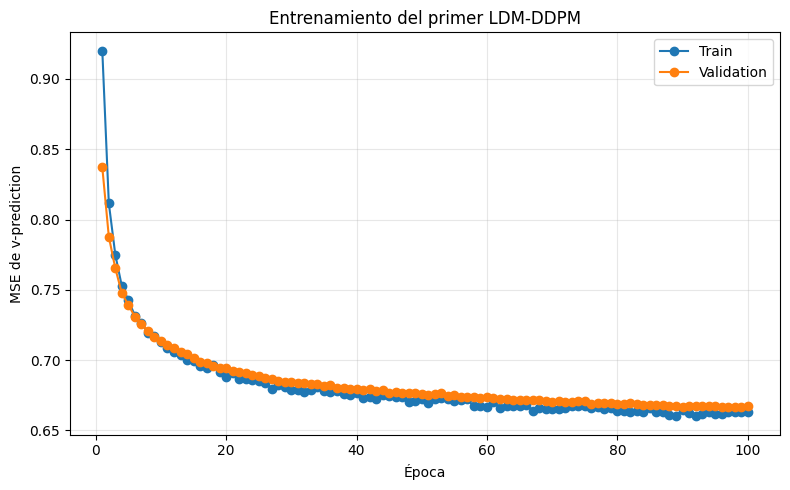

In [63]:
epochs = np.arange(1, len(ldm_history_first['train']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, ldm_history_first['train'], marker='o', label='Train')
plt.plot(epochs, ldm_history_first['val'], marker='o', label='Validation')
plt.xlabel('Época')
plt.ylabel('MSE de v-prediction')
plt.title('Entrenamiento del primer LDM-DDPM')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
@torch.no_grad()
def latent_ddpm_reverse_step_v(model, scheduler, z_t, timestep, class_labels, noise=None):
    batch_size = z_t.shape[0]
    t_batch = torch.full((batch_size,), timestep, device=z_t.device, dtype=torch.long)
    v_prediction = model(z_t, t_batch, class_labels)
    sqrt_alpha_bar_t = scheduler.sqrt_alpha_cum_prod[timestep]
    sqrt_one_minus_alpha_bar_t = scheduler.sqrt_one_minus_alpha_cum_prod[timestep]
    z0_prediction = sqrt_alpha_bar_t * z_t - sqrt_one_minus_alpha_bar_t * v_prediction

    if timestep == 0:
        return (z0_prediction, z0_prediction)

    posterior_mean = scheduler.posterior_mean_coef1[timestep] * z0_prediction + scheduler.posterior_mean_coef2[timestep] * z_t
    posterior_variance = scheduler.posterior_variance[timestep].clamp_min(1e-20)

    if noise is None:
        noise = torch.randn_like(z_t)

    z_previous = posterior_mean + torch.sqrt(posterior_variance) * noise

    return (z_previous, z0_prediction)

In [65]:
from tqdm.auto import tqdm


@torch.no_grad()
def generate_standardized_latents_ddpm(model, scheduler, num_samples, class_labels, latent_shape=(4, 16, 16), device=device, seed=42):
    model.eval()

    if isinstance(class_labels, int):
        class_labels = torch.full((num_samples,), class_labels, dtype=torch.long, device=device)
    else:
        class_labels = torch.as_tensor(class_labels, dtype=torch.long).reshape(-1).to(device)

    if class_labels.shape[0] != num_samples:
        raise ValueError('class_labels debe tener una etiqueta por cada muestra.')

    if class_labels.min().item() < 0 or class_labels.max().item() >= NUM_CLASSES:
        raise ValueError(f'Las etiquetas deben estar entre 0 y {NUM_CLASSES - 1}.')

    if seed is not None:
        torch.manual_seed(seed)

    z_t = torch.randn((num_samples, *latent_shape), device=device)

    for timestep in tqdm(reversed(range(scheduler.num_timesteps)), total=scheduler.num_timesteps, desc='Generando latentes DDPM'):
        z_t, _ = latent_ddpm_reverse_step_v(model=model, scheduler=scheduler, z_t=z_t, timestep=timestep, class_labels=class_labels)

        if timestep % 100 == 0:
            if not torch.isfinite(z_t).all():
                raise RuntimeError(f'Aparecieron NaN o infinitos durante el timestep {timestep}.')

    if not torch.isfinite(z_t).all():
        raise RuntimeError('Los latentes finales contienen NaN o infinitos.')

    return z_t

In [66]:
NUM_GENERATED_SAMPLES = 16
generated_sample_labels = torch.tensor([0] * 8 + [1] * 8, dtype=torch.long)
generated_latents_standardized = generate_standardized_latents_ddpm(
    model=ldm_model_first, scheduler=ldm_scheduler, num_samples=NUM_GENERATED_SAMPLES,
    class_labels=generated_sample_labels, latent_shape=(4, 16, 16), device=device, seed=SEED,
)

print('Shape:', generated_latents_standardized.shape)
print('Labels:', generated_sample_labels.tolist())
print('Valores finitos:', torch.isfinite(generated_latents_standardized).all().item())

Generando latentes DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

Shape: torch.Size([16, 4, 16, 16])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Valores finitos: True


In [67]:
def print_generated_latent_statistics(latents):
    latents_cpu = latents.detach().float().cpu()
    print('Media por canal:', latents_cpu.mean(dim=(0, 2, 3)).numpy())
    print('Std por canal:', latents_cpu.std(dim=(0, 2, 3), unbiased=False).numpy())
    print('Media global:', latents_cpu.mean().item())
    print('Std global:', latents_cpu.std(unbiased=False).item())
    print('Mínimo:', latents_cpu.min().item())
    print('Máximo:', latents_cpu.max().item())
    print('Fracción |z| > 4:', (latents_cpu.abs() > 4.0).float().mean().item())
    print('Fracción |z| > 6:', (latents_cpu.abs() > 6.0).float().mean().item())

In [68]:
print_generated_latent_statistics(generated_latents_standardized)

Media por canal: [-0.0436045  -0.0114867   0.04337147 -0.02594975]
Std por canal: [0.92623764 0.95774364 0.9500402  0.9400287 ]
Media global: -0.009417373687028885
Std global: 0.9441468119621277
Mínimo: -8.783438682556152
Máximo: 12.639551162719727
Fracción |z| > 4: 0.008544921875
Fracción |z| > 6: 0.003173828125


In [69]:
latent_mean_device = latent_mean_train.to(device).float()
latent_std_device = latent_std_train.to(device).float()
generated_latents_original = generated_latents_standardized * latent_std_device + latent_mean_device

print('Latentes desestandarizados:', generated_latents_original.shape)
print('Valores finitos:', torch.isfinite(generated_latents_original).all().item())

Latentes desestandarizados: torch.Size([16, 4, 16, 16])
Valores finitos: True


In [70]:
@torch.no_grad()
def decode_generated_latents(vae_model, latent_tensor):
    vae_model.eval()
    generated_images_m11 = vae_model.decode_hard(latent_tensor)
    generated_images_01 = ((generated_images_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

    return generated_images_01

In [71]:
generated_jets_01 = decode_generated_latents(vae_model=vae_model, latent_tensor=generated_latents_original)
print('Jets generados:', generated_jets_01.shape)
print('Mínimo:', generated_jets_01.min().item())
print('Máximo:', generated_jets_01.max().item())
print('Valores finitos:', torch.isfinite(generated_jets_01).all().item())

Jets generados: torch.Size([16, 3, 64, 64])
Mínimo: 0.0
Máximo: 1.0
Valores finitos: True


In [72]:
def plot_generated_jets(generated_images_01, labels=None, num_images=8, contrast=True, class_names=None):
    images = generated_images_01.detach().float().cpu()
    num_images = min(num_images, images.shape[0])

    if labels is not None:
        labels = torch.as_tensor(labels).detach().cpu().reshape(-1)

        if labels.shape[0] < num_images:
            raise ValueError('No hay suficientes labels para las imágenes mostradas.')

    if class_names is None:
        class_names = {0: 'Clase 0', 1: 'Clase 1'}

    num_columns = 4
    num_rows = int(np.ceil(num_images / num_columns))
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(3.6 * num_columns, 4.4 * num_rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for index in range(num_images):
        image = images[index]
        total_intensity = image.sum().item()
        maximum = image.max().item()
        active_fraction = (image > 0.0001).float().mean().item()
        image_to_show = image.permute(1, 2, 0).numpy()

        if contrast:
            display_maximum = image_to_show.max()

            if display_maximum > 0:
                image_to_show = image_to_show / display_maximum

        axes[index].imshow(image_to_show)

        if labels is not None:
            class_id = int(labels[index].item())
            class_label = class_names.get(class_id, f'Clase {class_id}')
            title = f'Jet {index + 1} — {class_label}\nI={total_intensity:.2f}, max={maximum:.3f}\nact={100 * active_fraction:.2f}%'
        else:
            title = f'Jet {index + 1}\nI={total_intensity:.2f}, max={maximum:.3f}\nact={100 * active_fraction:.2f}%'

        axes[index].set_title(title, fontsize=14, pad=6)
        axes[index].axis('off')

    for index in range(num_images, len(axes)):
        axes[index].axis('off')

plt.show()

In [73]:
@torch.no_grad()
def generate_jet_dataset_ddpm(
    ldm_model, scheduler, vae_model, latent_mean, latent_std, num_samples, class_labels, batch_size=64,
    latent_shape=(4, 16, 16), device=device, seed=42,
):
    ldm_model.eval()
    vae_model.eval()
    class_labels = torch.as_tensor(class_labels, dtype=torch.long).reshape(-1)

    if class_labels.shape[0] != num_samples:
        raise ValueError(f'class_labels debe contener exactamente {num_samples} etiquetas.')

    if class_labels.min().item() < 0 or class_labels.max().item() >= NUM_CLASSES:
        raise ValueError(f'Las etiquetas deben estar entre 0 y {NUM_CLASSES - 1}.')

    if seed is not None:
        torch.manual_seed(seed)

    latent_mean = latent_mean.to(device).float()
    latent_std = latent_std.to(device).float()
    generated_batches = []
    generated_latent_batches = []
    num_batches = int(np.ceil(num_samples / batch_size))

    for batch_index in tqdm(range(num_batches), desc='Generando dataset con LDM'):
        current_batch_size = min(batch_size, num_samples - batch_index * batch_size)
        start_index = batch_index * batch_size
        end_index = start_index + current_batch_size
        batch_labels = class_labels[start_index:end_index].to(device)
        z_t = torch.randn((current_batch_size, *latent_shape), device=device)

        for timestep in reversed(range(scheduler.num_timesteps)):
            z_t, _ = latent_ddpm_reverse_step_v(model=ldm_model, scheduler=scheduler, z_t=z_t, timestep=timestep, class_labels=batch_labels)

        generated_latent_batches.append(z_t.detach().cpu())
        z_original = z_t * latent_std + latent_mean
        generated_m11 = vae_model.decode_hard(z_original)
        generated_01 = ((generated_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

        generated_batches.append(generated_01.detach().cpu())

    generated_images_01 = torch.cat(generated_batches, dim=0)
    generated_latents_standardized = torch.cat(generated_latent_batches, dim=0)

    return (generated_images_01, generated_latents_standardized, class_labels.cpu())

In [74]:
NUM_GENERATED_JETS = 2500
generation_labels_2500 = ldm_test_labels[:NUM_GENERATED_JETS].clone()
print('Distribución de clases a generar:', torch.unique(generation_labels_2500, return_counts=True))
generated_images_01, generated_latents_2500, generated_labels_2500 = generate_jet_dataset_ddpm(
    ldm_model=ldm_model_first, scheduler=ldm_scheduler, vae_model=vae_model, latent_mean=latent_mean_train,
    latent_std=latent_std_train, num_samples=NUM_GENERATED_JETS, class_labels=generation_labels_2500,
    batch_size=64, latent_shape=(4, 16, 16), device=device, seed=SEED,
)
print('Shape:', generated_images_01.shape)
print('Min:', generated_images_01.min().item())
print('Max:', generated_images_01.max().item())
print('Finitos:', torch.isfinite(generated_images_01).all().item())
print('Shape latentes generados:', generated_latents_2500.shape)
print('Latentes finitos:', torch.isfinite(generated_latents_2500).all().item())

Distribución de clases a generar: (tensor([0, 1]), tensor([1240, 1260]))


Generando dataset con LDM:   0%|          | 0/40 [00:00<?, ?it/s]

Shape: torch.Size([2500, 3, 64, 64])
Min: 0.0
Max: 1.0
Finitos: True
Shape latentes generados: torch.Size([2500, 4, 16, 16])
Latentes finitos: True


In [75]:
print_generated_latent_statistics(generated_latents_2500)

Media por canal: [-0.02426573 -0.00689281  0.01549913 -0.00508677]
Std por canal: [0.9716675  0.9753895  0.95993435 0.9800822 ]
Media global: -0.005186549387872219
Std global: 0.9718992114067078
Mínimo: -14.18172836303711
Máximo: 19.673294067382812
Fracción |z| > 4: 0.008802734315395355
Fracción |z| > 6: 0.003383984323590994


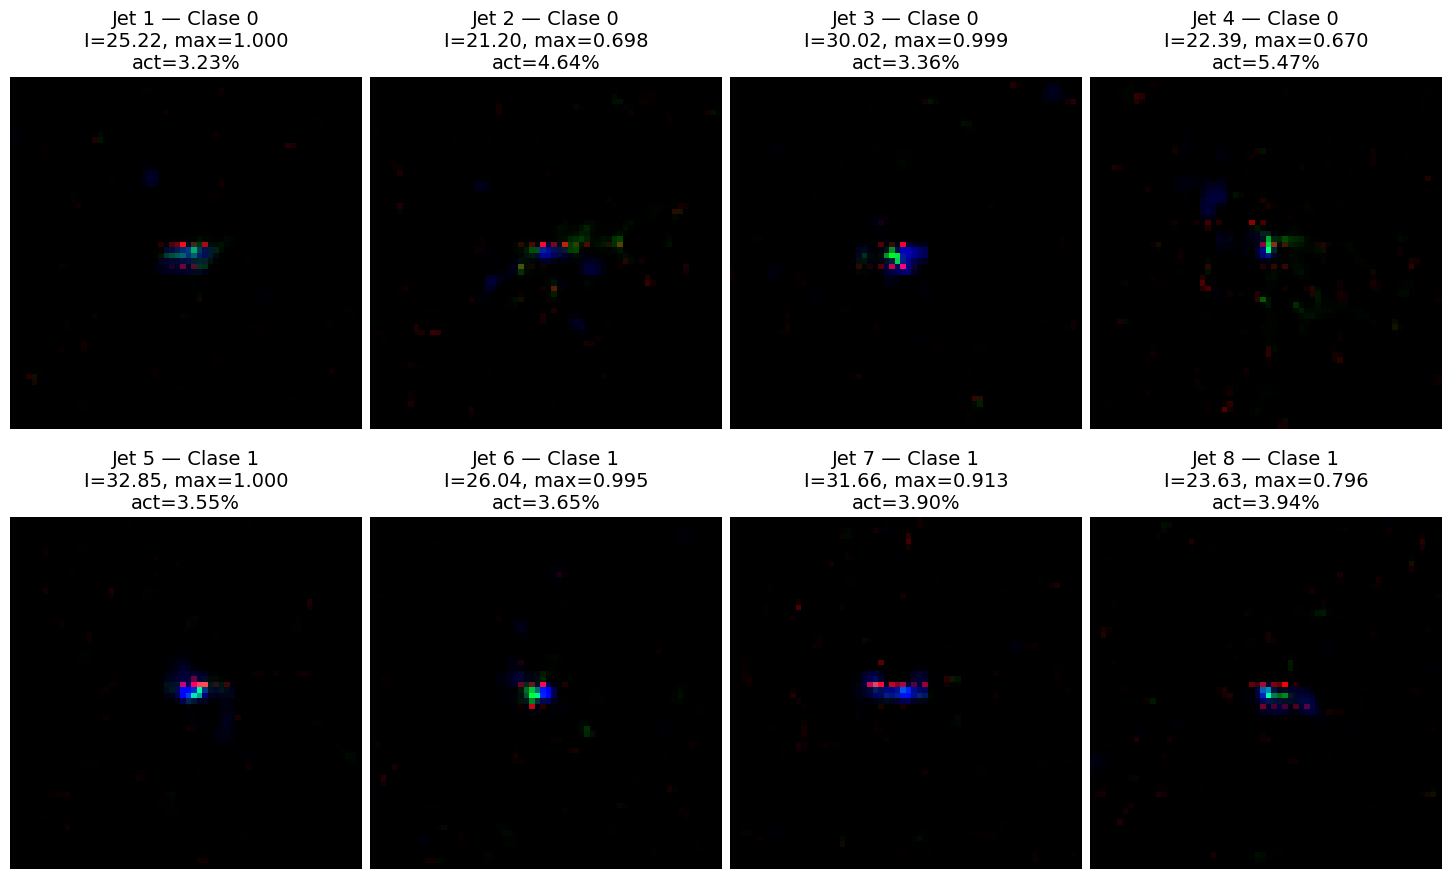

In [76]:
indices_class_0 = torch.where(generated_labels_2500 == 0)[0][:4]
indices_class_1 = torch.where(generated_labels_2500 == 1)[0][:4]
sample_indices = torch.cat([indices_class_0, indices_class_1])

plot_generated_jets(generated_images_01[sample_indices], labels=generated_labels_2500[sample_indices], num_images=8, contrast=True)

In [77]:
@torch.no_grad()
def collect_real_images_from_loader(data_loader, device=device):
    image_batches = []

    for images, _ in data_loader:
        images = images.to(device)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        image_batches.append(images_01.detach().cpu())

    return torch.cat(image_batches, dim=0)

In [78]:
real_test_images_01 = collect_real_images_from_loader(test_loader, device=device)
print('Shape real:', real_test_images_01.shape)
print('Min real:', real_test_images_01.min().item())
print('Max real:', real_test_images_01.max().item())

Shape real: torch.Size([2500, 3, 64, 64])
Min real: 0.0
Max real: 1.0


In [79]:
from scipy.stats import wasserstein_distance
CHANNEL_NAMES = ['TRACKER', 'ECAL', 'HCAL']


@torch.no_grad()
def collect_image_diagnostics(images_01, active_thr_01=0.0001, num_radial_bins=32):
    images_01 = images_01.float().cpu()
    batch_size, channels, height, width = images_01.shape
    energy = images_01.sum(dim=(-2, -1)).numpy()
    active_fraction = (images_01 > active_thr_01).float().mean(dim=(-2, -1)).numpy()
    maximum = images_01.amax(dim=(-2, -1)).numpy()
    y_coordinates, x_coordinates = torch.meshgrid(torch.arange(height, dtype=torch.float32), torch.arange(width, dtype=torch.float32), indexing='ij')
    center_y = (height - 1) / 2.0
    center_x = (width - 1) / 2.0
    radius = torch.sqrt((y_coordinates - center_y) ** 2 + (x_coordinates - center_x) ** 2)
    radial_edges = torch.linspace(0.0, radius.max().item() + 1e-06, num_radial_bins + 1)
    radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
    radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False) - 1).clamp(min=0, max=num_radial_bins - 1)
    radial_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
    flat_images = images_01.reshape(batch_size, channels, -1).double()

    for radial_bin in range(num_radial_bins):
        radial_mask = radial_bin_index == radial_bin
        radial_sum[:, radial_bin] += flat_images[:, :, radial_mask].sum(dim=(0, 2))

    radial_profile = (radial_sum / radial_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()

    return {
        'images': images_01,
        'energy': energy,
        'active_fraction': active_fraction,
        'maximum': maximum,
        'radial_centers': radial_centers,
        'radial_profile': radial_profile,
    }

In [80]:
real_diag = collect_image_diagnostics(real_test_images_01, active_thr_01=0.0001, num_radial_bins=32)
gen_diag = collect_image_diagnostics(generated_images_01, active_thr_01=0.0001, num_radial_bins=32)

In [81]:
def summarize_real_vs_generated(real_diag, gen_diag):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        e_real = real_diag['energy'][:, channel]
        e_gen = gen_diag['energy'][:, channel]
        a_real = real_diag['active_fraction'][:, channel]
        a_gen = gen_diag['active_fraction'][:, channel]
        m_real = real_diag['maximum'][:, channel]
        m_gen = gen_diag['maximum'][:, channel]
        radial_real = real_diag['radial_profile'][channel]
        radial_gen = gen_diag['radial_profile'][channel]
        row = {
            'Canal': channel_name,
            'E real media': e_real.mean(),
            'E gen media': e_gen.mean(),
            'Bias E (%)': 100.0 * (e_gen.mean() - e_real.mean()) / max(e_real.mean(), 1e-12),
            'W1 energía': wasserstein_distance(e_real, e_gen),
            'Fracción activa real': a_real.mean(),
            'Fracción activa gen': a_gen.mean(),
            'Diferencia activa (p.p.)': 100.0 * (a_gen.mean() - a_real.mean()),
            'Máximo real medio': m_real.mean(),
            'Máximo gen medio': m_gen.mean(),
            'W1 máximo': wasserstein_distance(m_real, m_gen),
            'Radial L1': np.mean(np.abs(radial_gen - radial_real)),
            'Radial L2': np.sqrt(np.mean((radial_gen - radial_real) ** 2)),
        }

        rows.append(row)

    return pd.DataFrame(rows)

In [82]:
summary_ldm = summarize_real_vs_generated(real_diag, gen_diag)
display(summary_ldm.round(6))

,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,7.456671,7.249526,-2.777979,0.245432,0.041387,0.033303,-0.808359,0.847103,0.812677,0.036234,0.005809,0.012257
1,ECAL,7.516253,7.208539,-4.093981,0.313331,0.053120,0.048189,-0.493106,0.815551,0.723244,0.092347,0.002643,0.003477
2,HCAL,10.180333,10.081417,-0.971639,0.305849,0.044640,0.047496,0.285547,0.483430,0.473194,0.013217,0.001815,0.003013


In [83]:
def print_global_generation_summary(real_diag, gen_diag):
    total_real = real_diag['energy'].sum(axis=1)
    total_gen = gen_diag['energy'].sum(axis=1)
    active_real = real_diag['active_fraction'].mean(axis=1)
    active_gen = gen_diag['active_fraction'].mean(axis=1)
    max_real = real_diag['maximum'].max(axis=1)
    max_gen = gen_diag['maximum'].max(axis=1)

    print('============================================================')
    print('RESUMEN GLOBAL: REAL vs GENERADO')
    print('============================================================')
    print(f'Intensidad total media real      : {total_real.mean():.6f}')
    print(f'Intensidad total media generada  : {total_gen.mean():.6f}')
    print(f'Bias total (%)                   : {100 * (total_gen.mean() - total_real.mean()) / max(total_real.mean(), 1e-12):.6f}')
    print(f'W1 intensidad total              : {wasserstein_distance(total_real, total_gen):.6f}')
    print()
    print(f'Fracción activa media real       : {active_real.mean():.6f}')
    print(f'Fracción activa media generada   : {active_gen.mean():.6f}')
    print(f'Diferencia activa (p.p.)         : {100 * (active_gen.mean() - active_real.mean()):.6f}')
    print()
    print(f'Máximo global medio real         : {max_real.mean():.6f}')
    print(f'Máximo global medio generado     : {max_gen.mean():.6f}')
    print(f'W1 máximo global                 : {wasserstein_distance(max_real, max_gen):.6f}')

In [84]:
print_global_generation_summary(real_diag, gen_diag)

RESUMEN GLOBAL: REAL vs GENERADO
Intensidad total media real      : 25.153257
Intensidad total media generada  : 24.539482
Bias total (%)                   : -2.440142
W1 intensidad total              : 0.652932

Fracción activa media real       : 0.046383
Fracción activa media generada   : 0.042996
Diferencia activa (p.p.)         : -0.338640

Máximo global medio real         : 0.950799
Máximo global medio generado     : 0.897241
W1 máximo global                 : 0.053558


In [85]:
def summarize_generation_by_class(real_images, real_labels, generated_images, generated_labels):
    real_labels = torch.as_tensor(real_labels).long().cpu().reshape(-1)
    generated_labels = torch.as_tensor(generated_labels).long().cpu().reshape(-1)
    tables = []
    class_ids = sorted(set(real_labels.tolist()) & set(generated_labels.tolist()))

    for class_id in class_ids:
        real_mask = real_labels == class_id
        generated_mask = generated_labels == class_id
        real_class_images = real_images[real_mask]
        generated_class_images = generated_images[generated_mask]

        print(f'Clase {class_id}: {real_mask.sum().item()} reales | {generated_mask.sum().item()} generados')
        real_class_diag = collect_image_diagnostics(real_class_images, active_thr_01=0.0001, num_radial_bins=32)
        generated_class_diag = collect_image_diagnostics(generated_class_images, active_thr_01=0.0001, num_radial_bins=32)
        class_summary = summarize_real_vs_generated(real_class_diag, generated_class_diag)

        class_summary.insert(0, 'Clase', class_id)
        class_summary.insert(1, 'N real', real_mask.sum().item())
        class_summary.insert(2, 'N generado', generated_mask.sum().item())
        tables.append(class_summary)

    return pd.concat(tables, ignore_index=True)

In [86]:
summary_by_class = summarize_generation_by_class(
    real_images=real_test_images_01, real_labels=ldm_test_labels, generated_images=generated_images_01,
    generated_labels=generated_labels_2500,
)
display(summary_by_class.round(6))

Clase 0: 1240 reales | 1240 generados
Clase 1: 1260 reales | 1260 generados


,Clase,N real,N generado,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,0,1240,1240,TRACKER,7.886384,7.440550,-5.653220,0.447110,0.043415,0.034644,-0.877115,0.815167,0.771154,0.044055,0.004786,0.008853
1,0,1240,1240,ECAL,7.646328,7.268899,-4.936088,0.388329,0.057391,0.051982,-0.540870,0.769565,0.671809,0.097821,0.002604,0.003554
2,0,1240,1240,HCAL,9.841105,9.612217,-2.325842,0.289112,0.046970,0.050421,0.345065,0.442344,0.417933,0.024487,0.002278,0.003886
3,1,1260,1260,TRACKER,7.033779,7.061535,0.394606,0.221464,0.039391,0.031984,-0.740696,0.878532,0.853540,0.035334,0.007336,0.016370
4,1,1260,1260,ECAL,7.388242,7.149138,-3.236287,0.251237,0.048917,0.044456,-0.446099,0.860807,0.773863,0.086994,0.002831,0.003856
5,1,1260,1260,HCAL,10.514175,10.543170,0.275766,0.400411,0.042348,0.044617,0.226973,0.523864,0.527577,0.015728,0.001651,0.002661


In [87]:
def build_class_comparison_diagnostics(real_diag, generated_diag, real_labels, generated_labels, class_id):
    real_labels_np = torch.as_tensor(real_labels).long().cpu().numpy().reshape(-1)
    generated_labels_np = torch.as_tensor(generated_labels).long().cpu().numpy().reshape(-1)
    real_mask = real_labels_np == class_id
    generated_mask = generated_labels_np == class_id

    if real_mask.sum() == 0:
        raise ValueError(f'No hay eventos reales de clase {class_id}.')

    if generated_mask.sum() == 0:
        raise ValueError(f'No hay eventos generados de clase {class_id}.')

    class_diagnostics = {
        'energy_real': np.asarray(real_diag['energy'])[real_mask],
        'energy_recon': np.asarray(generated_diag['energy'])[generated_mask],
        'active_frac_real': np.asarray(real_diag['active_fraction'])[real_mask],
        'active_frac_recon': np.asarray(generated_diag['active_fraction'])[generated_mask],
        'max_real': np.asarray(real_diag['maximum'])[real_mask],
        'max_recon': np.asarray(generated_diag['maximum'])[generated_mask],
    }
    print(f'Clase {class_id}: {real_mask.sum()} reales | {generated_mask.sum()} generados')

    return class_diagnostics

In [88]:
comparison_diagnostics_class_0 = build_class_comparison_diagnostics(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, class_id=0,
)
comparison_diagnostics_class_1 = build_class_comparison_diagnostics(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, class_id=1,
)

Clase 0: 1240 reales | 1240 generados
Clase 1: 1260 reales | 1260 generados


In [89]:
comparison_diagnostics = {
    'energy_real': real_diag['energy'],
    'energy_recon': gen_diag['energy'],
    'active_frac_real': real_diag['active_fraction'],
    'active_frac_recon': gen_diag['active_fraction'],
    'max_real': real_diag['maximum'],
    'max_recon': gen_diag['maximum'],
    'radial_centers': real_diag['radial_centers'],
    'radial_real': real_diag['radial_profile'],
    'radial_recon': gen_diag['radial_profile'],
}

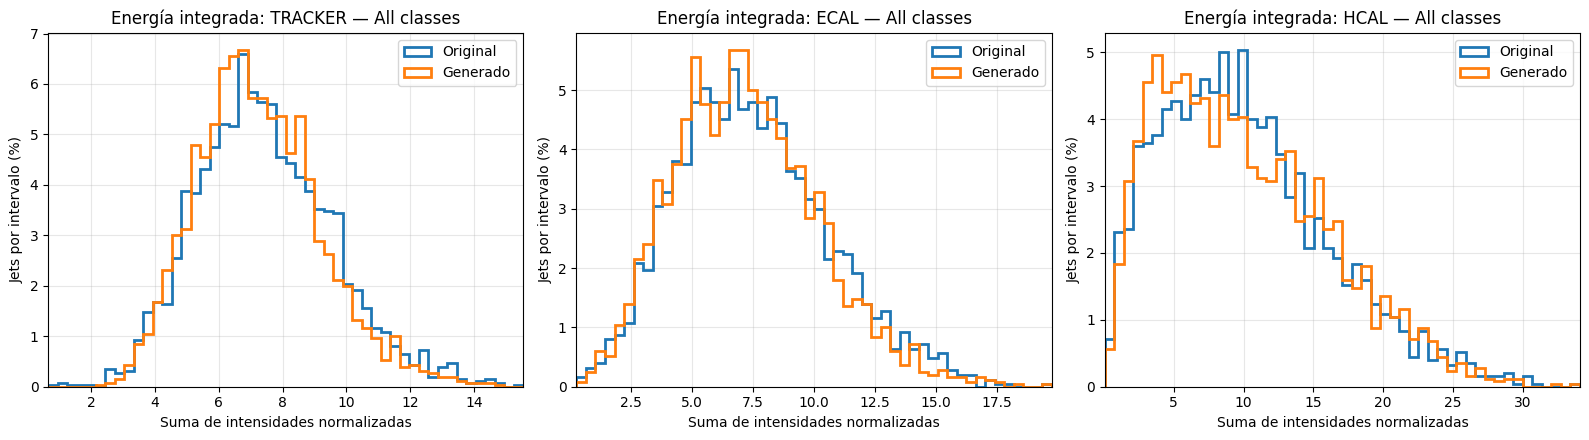

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [90]:
plot_channel_distributions(comparison_diagnostics, metric='energy', num_bins=50, upper_quantile=0.999, class_name='All classes')

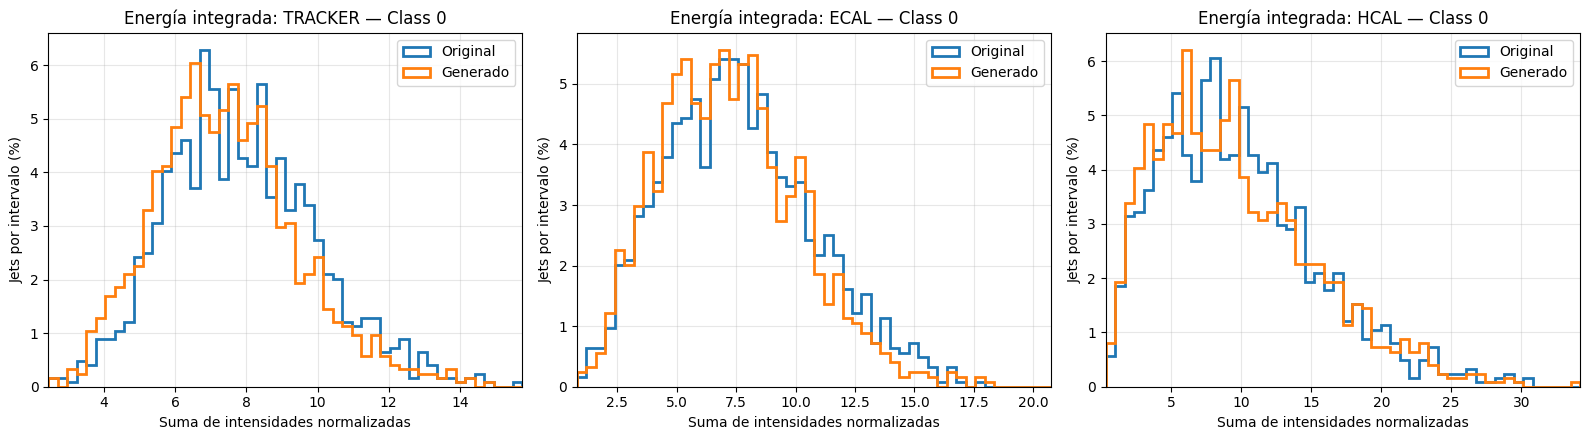

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [91]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='energy', num_bins=50, upper_quantile=0.999, class_name='Class 0')

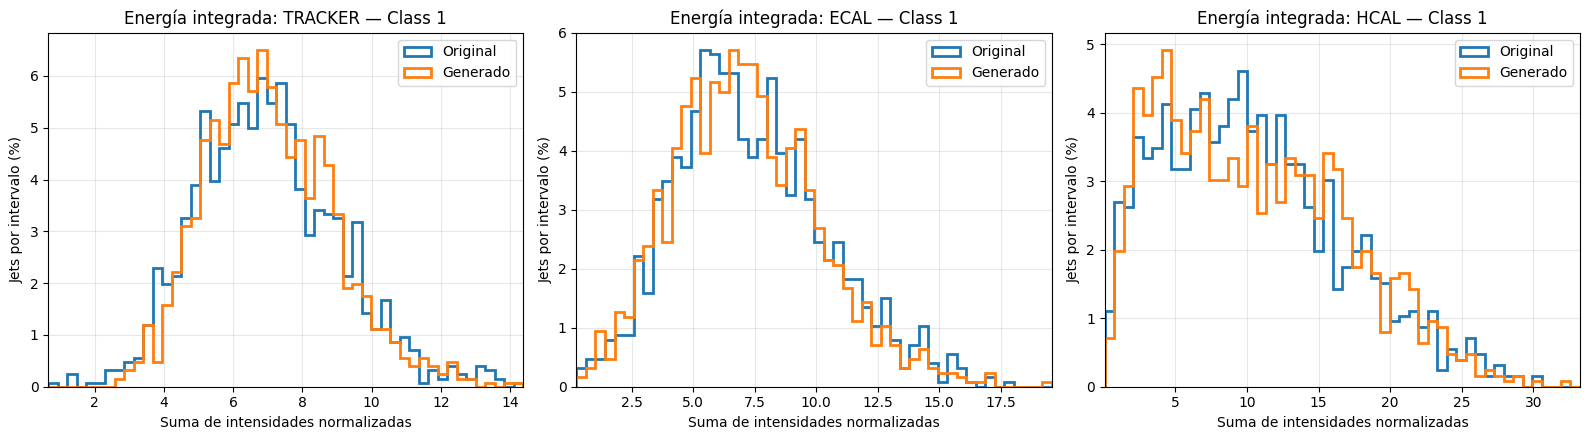

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [92]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='energy', num_bins=50, upper_quantile=0.999, class_name='Class 1')

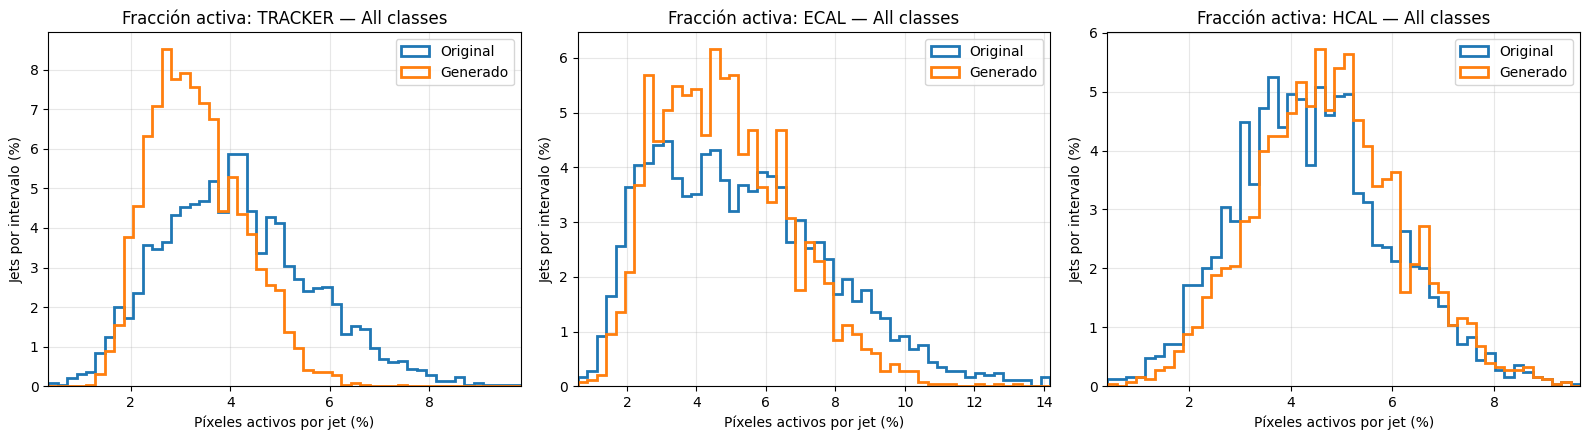

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [93]:
plot_channel_distributions(comparison_diagnostics, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='All classes')

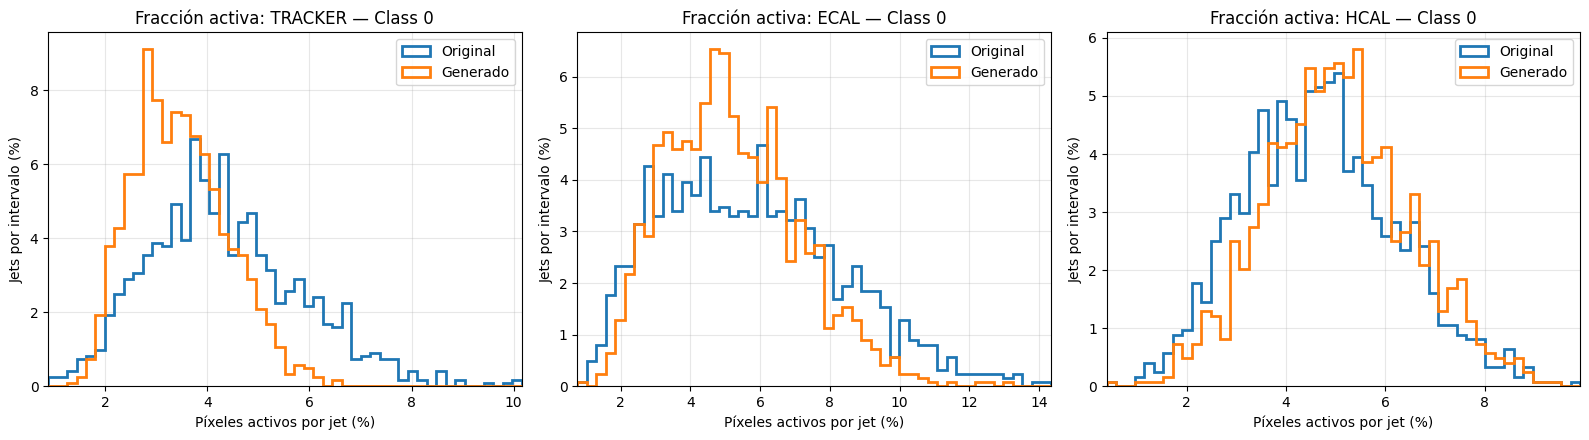

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [94]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='Class 0')

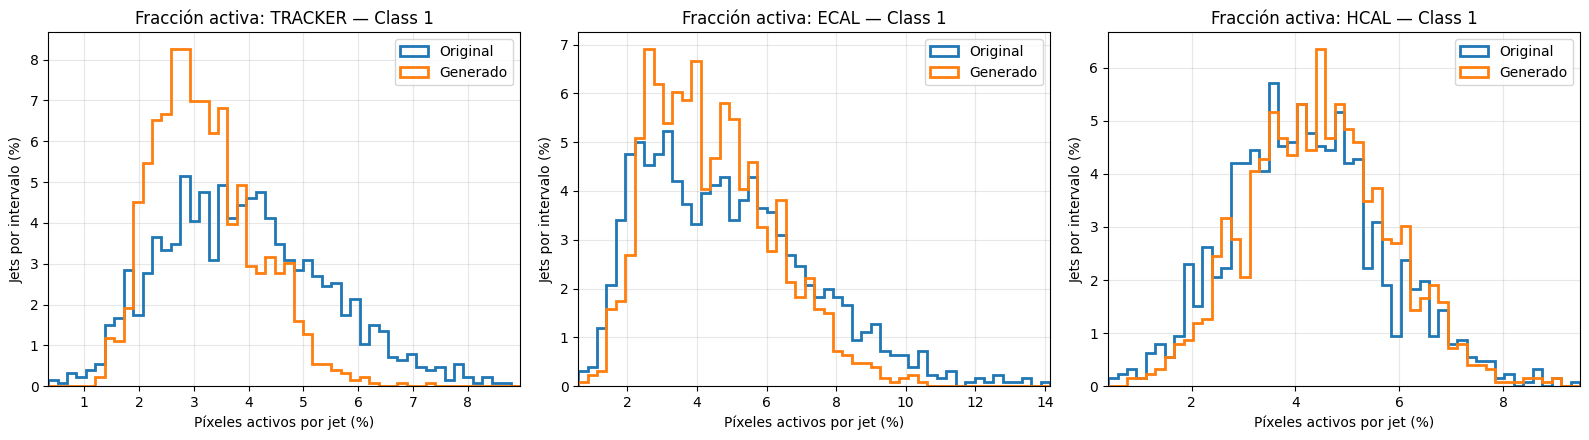

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [95]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='Class 1')

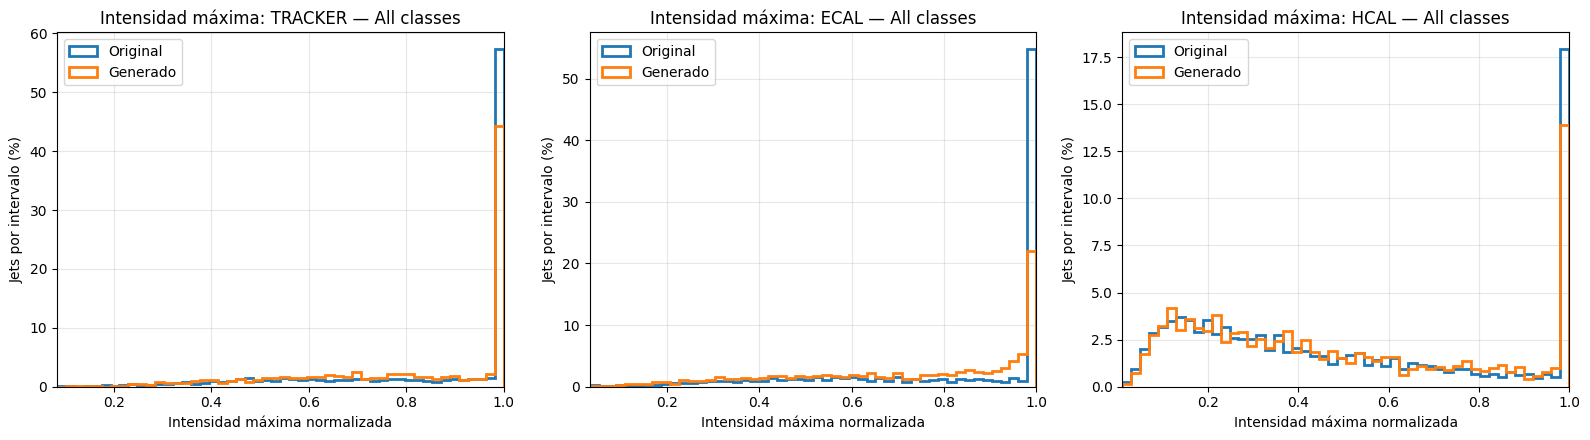

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [96]:
plot_channel_distributions(comparison_diagnostics, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='All classes')

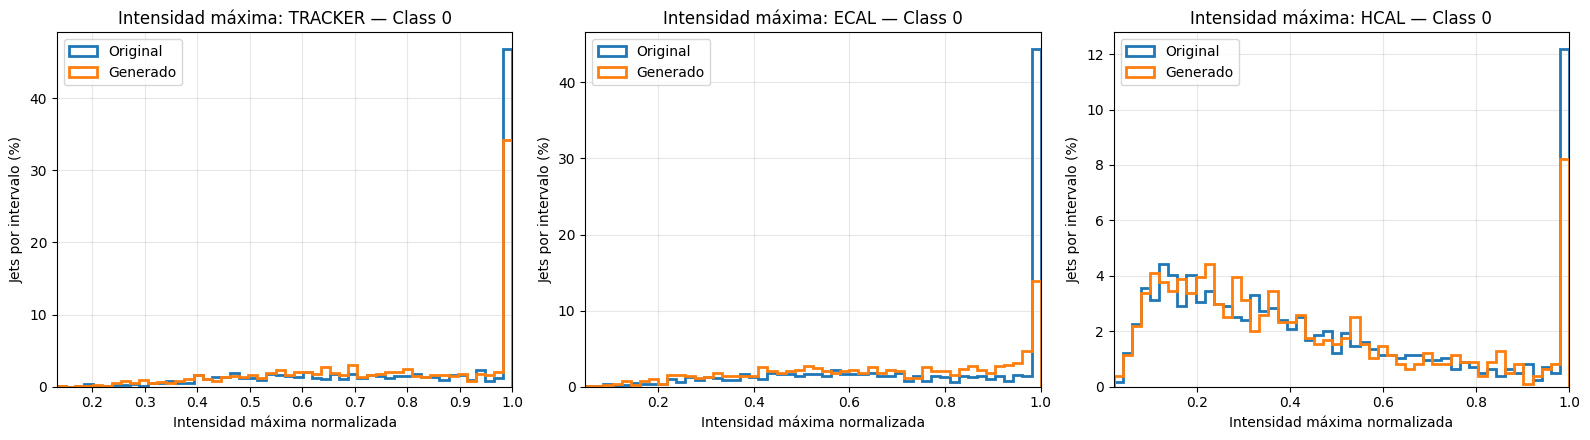

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [97]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='Class 0')

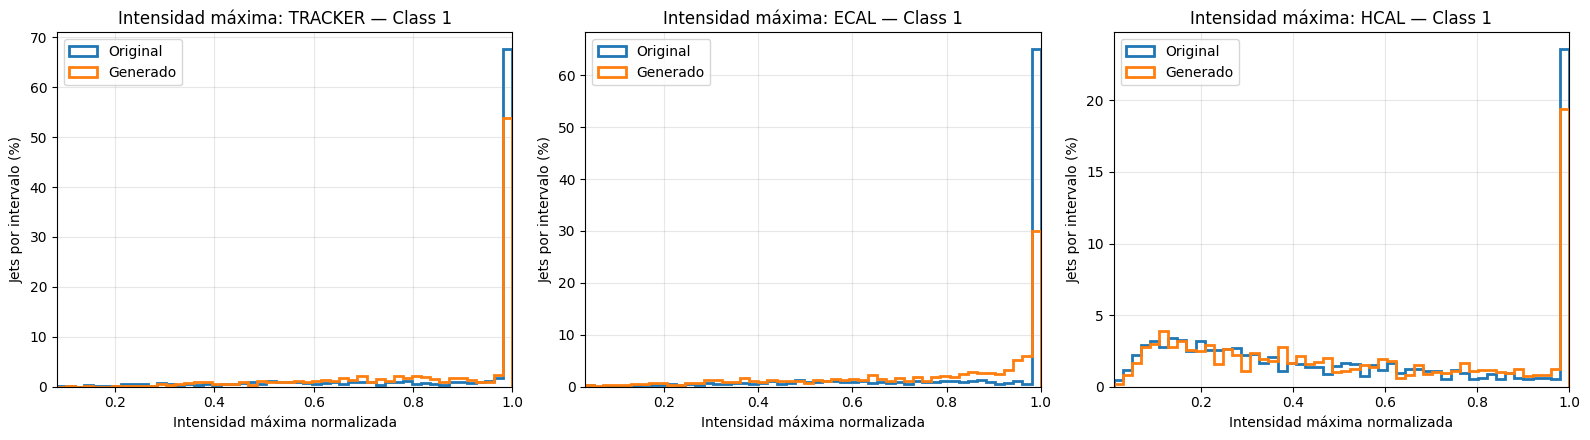

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [98]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='Class 1')

In [99]:
def plot_radial_profiles_from_diagnostics(comparison_diagnostics):
    radial_centers = comparison_diagnostics['radial_centers']
    radial_real = comparison_diagnostics['radial_real']
    radial_gen = comparison_diagnostics['radial_recon']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        axes[channel].plot(radial_centers, radial_real[channel], marker='o', label='Real')
        axes[channel].plot(radial_centers, radial_gen[channel], marker='o', label='Generado')
        axes[channel].set_title(f'Perfil radial: {channel_name}')
        axes[channel].set_xlabel('Radio')
        axes[channel].set_ylabel('Fracción de intensidad')
        axes[channel].grid(alpha=0.3)
        axes[channel].legend()

    plt.tight_layout()
    plt.show()

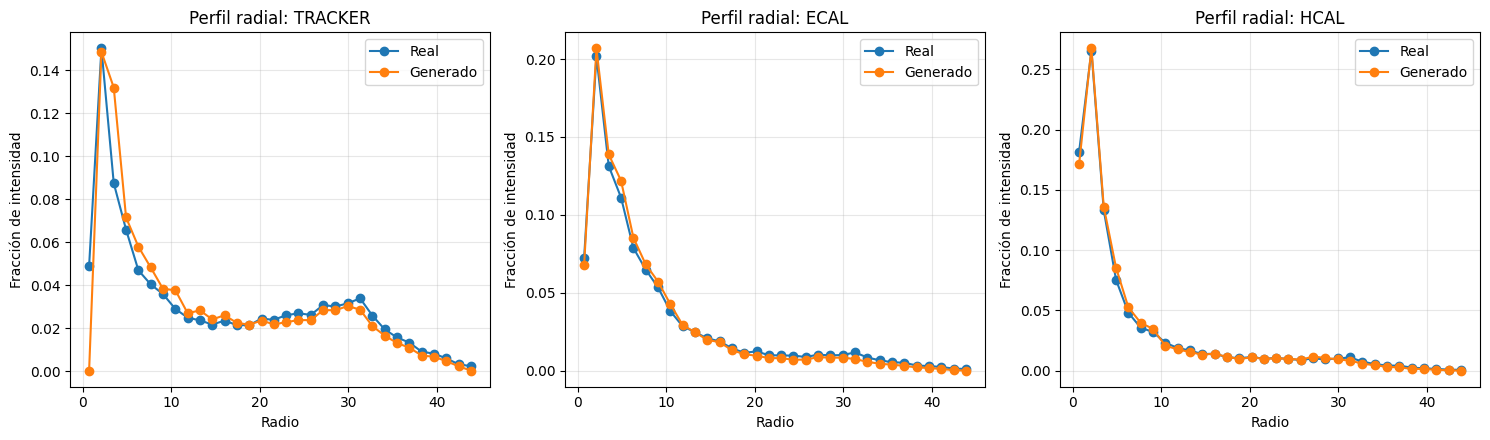

In [100]:
plot_radial_profiles_from_diagnostics(comparison_diagnostics)

In [101]:
def plot_real_vs_generated_class_separation(
    real_diag, generated_diag, real_labels, generated_labels, metric, num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
):
    real_labels_np = torch.as_tensor(real_labels).long().cpu().numpy().reshape(-1)
    generated_labels_np = torch.as_tensor(generated_labels).long().cpu().numpy().reshape(-1)

    if metric == 'energy':
        real_data = np.asarray(real_diag['energy'])
        generated_data = np.asarray(generated_diag['energy'])
        title_prefix = 'Integrated energy'
        x_label = 'Sum of normalized intensities'
    elif metric == 'active_fraction':
        real_data = np.asarray(real_diag['active_fraction']) * 100.0
        generated_data = np.asarray(generated_diag['active_fraction']) * 100.0
        title_prefix = 'Active fraction'
        x_label = 'Active pixels per jet (%)'
    elif metric == 'maximum':
        real_data = np.asarray(real_diag['maximum'])
        generated_data = np.asarray(generated_diag['maximum'])
        title_prefix = 'Maximum intensity'
        x_label = 'Normalized maximum intensity'
    else:
        raise ValueError("metric debe ser 'energy', 'active_fraction' o 'maximum'.")

    if real_data.ndim != 2:
        raise ValueError('real_data debe tener shape [N, C].')

    if generated_data.ndim != 2:
        raise ValueError('generated_data debe tener shape [N, C].')

    real_mask_0 = real_labels_np == 0
    real_mask_1 = real_labels_np == 1
    generated_mask_0 = generated_labels_np == 0
    generated_mask_1 = generated_labels_np == 1

    if real_mask_0.sum() == 0 or real_mask_1.sum() == 0:
        raise ValueError('El conjunto real no contiene ambas clases.')

    if generated_mask_0.sum() == 0 or generated_mask_1.sum() == 0:
        raise ValueError('El conjunto generado no contiene ambas clases.')

    print(f'REAL -> {class_0_name}: {real_mask_0.sum()} | {class_1_name}: {real_mask_1.sum()}')
    print(f'GENERATED -> {class_0_name}: {generated_mask_0.sum()} | {class_1_name}: {generated_mask_1.sum()}')
    fig, axes = plt.subplots(2, len(CHANNEL_NAMES), figsize=(16, 9), sharey='row')

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values_0 = real_data[real_mask_0, channel]
        real_values_1 = real_data[real_mask_1, channel]
        bins_real = common_histogram_bins(real_values_0, real_values_1, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights_0 = np.full(real_values_0.shape, 100.0 / len(real_values_0))
        real_weights_1 = np.full(real_values_1.shape, 100.0 / len(real_values_1))

        axes[0, channel].hist(real_values_0, bins=bins_real, weights=real_weights_0, histtype='step', linewidth=2, label=class_0_name)
        axes[0, channel].hist(real_values_1, bins=bins_real, weights=real_weights_1, histtype='step', linewidth=2, label=class_1_name)
        axes[0, channel].set_title(f'REAL — {title_prefix}: {channel_name}')
        axes[0, channel].set_xlabel(x_label)
        axes[0, channel].set_ylabel('Jets (%)')
        axes[0, channel].legend()
        axes[0, channel].grid(alpha=0.3)

        generated_values_0 = generated_data[generated_mask_0, channel]
        generated_values_1 = generated_data[generated_mask_1, channel]
        bins_generated = common_histogram_bins(generated_values_0, generated_values_1, num_bins=num_bins, upper_quantile=upper_quantile)
        generated_weights_0 = np.full(generated_values_0.shape, 100.0 / len(generated_values_0))
        generated_weights_1 = np.full(generated_values_1.shape, 100.0 / len(generated_values_1))

        axes[1, channel].hist(generated_values_0, bins=bins_generated, weights=generated_weights_0, histtype='step', linewidth=2, label=class_0_name)
        axes[1, channel].hist(generated_values_1, bins=bins_generated, weights=generated_weights_1, histtype='step', linewidth=2, label=class_1_name)
        axes[1, channel].set_title(f'GENERATED — {title_prefix}: {channel_name}')
        axes[1, channel].set_xlabel(x_label)
        axes[1, channel].set_ylabel('Jets (%)')
        axes[1, channel].legend()
        axes[1, channel].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()

    return (fig, axes)

REAL -> Class 0: 1240 | Class 1: 1260
GENERATED -> Class 0: 1240 | Class 1: 1260


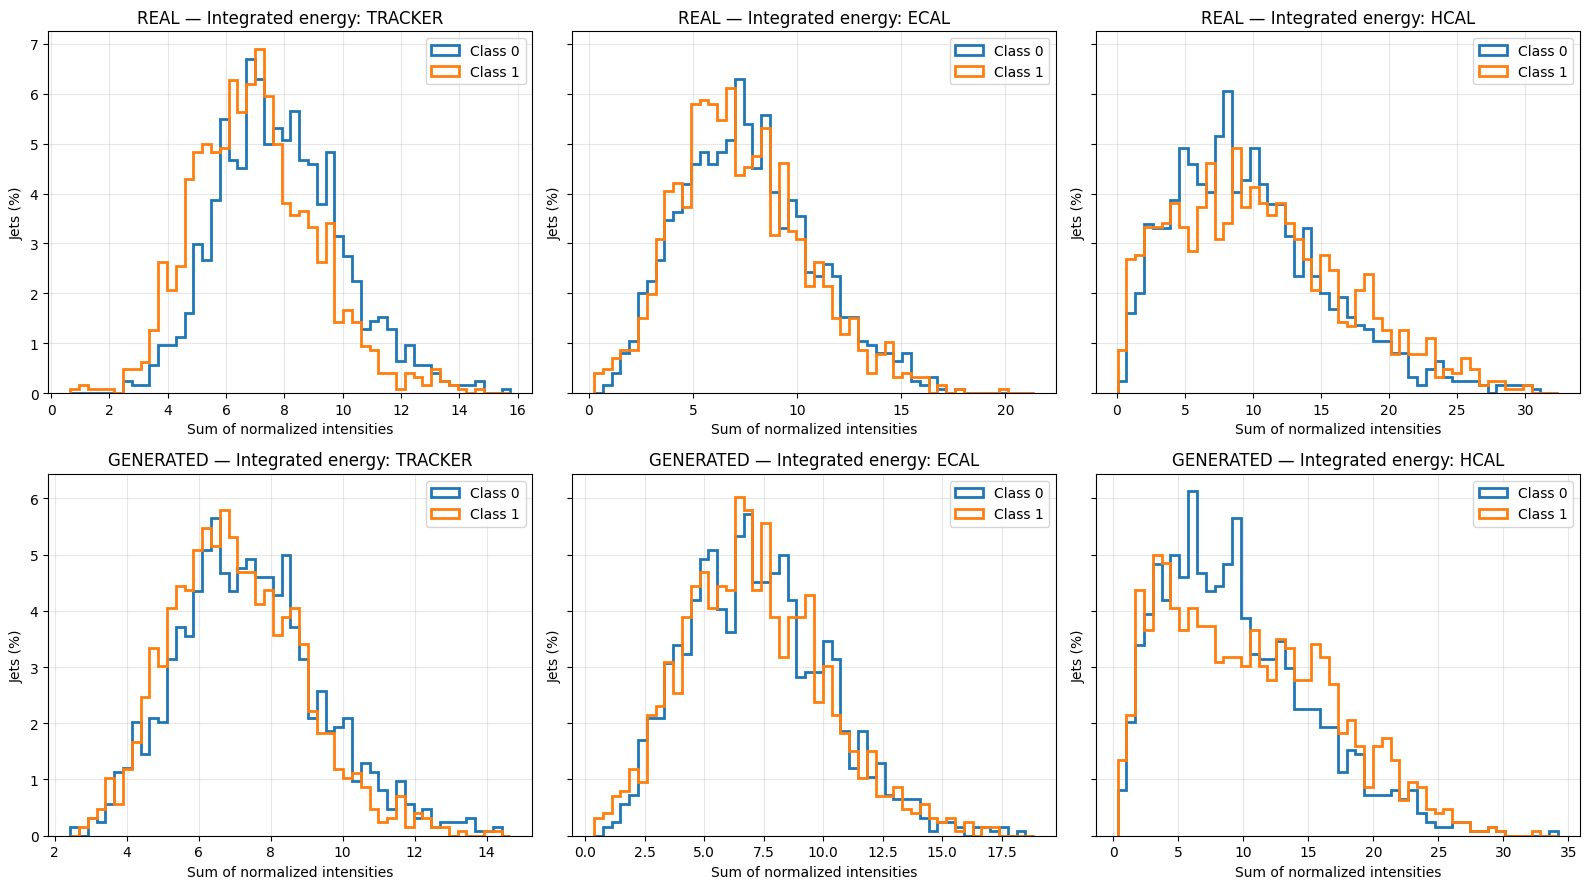

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Integrated energy: TRACKER'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Integrated energy: ECAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Integrated energy: HCAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Integrated energy: TRACKER'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Integrated energy: ECAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Integrated energy: HCAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>]],
       dtype=object))

In [102]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='energy', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

REAL -> Class 0: 1240 | Class 1: 1260
GENERATED -> Class 0: 1240 | Class 1: 1260


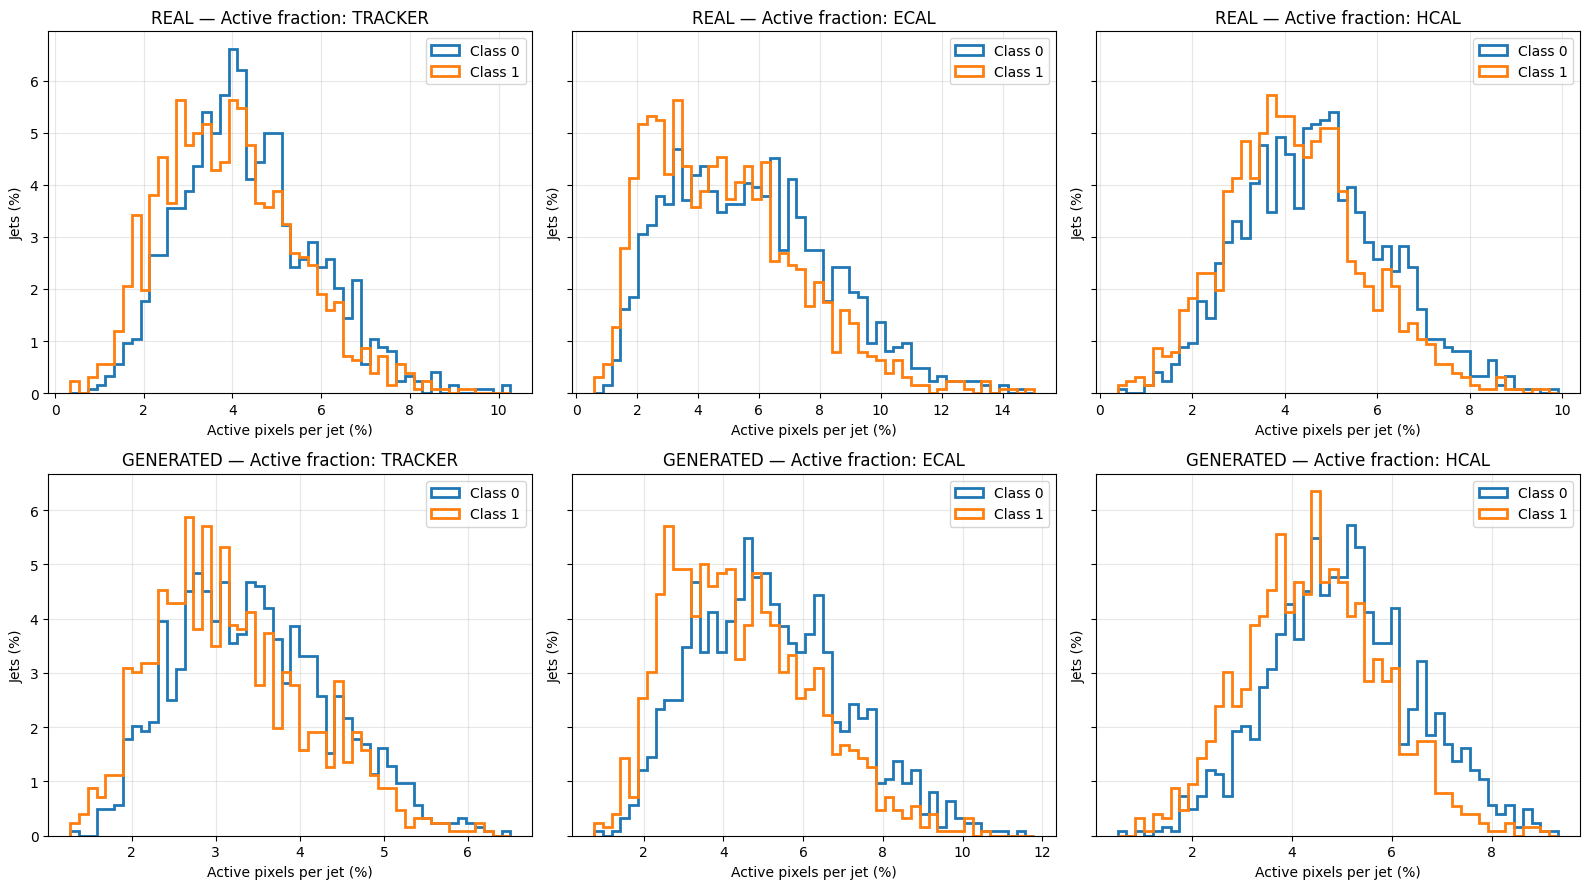

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Active fraction: TRACKER'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Active fraction: ECAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Active fraction: HCAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Active fraction: TRACKER'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Active fraction: ECAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Active fraction: HCAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>]],
       dtype=object))

In [103]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='active_fraction', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

REAL -> Class 0: 1240 | Class 1: 1260
GENERATED -> Class 0: 1240 | Class 1: 1260


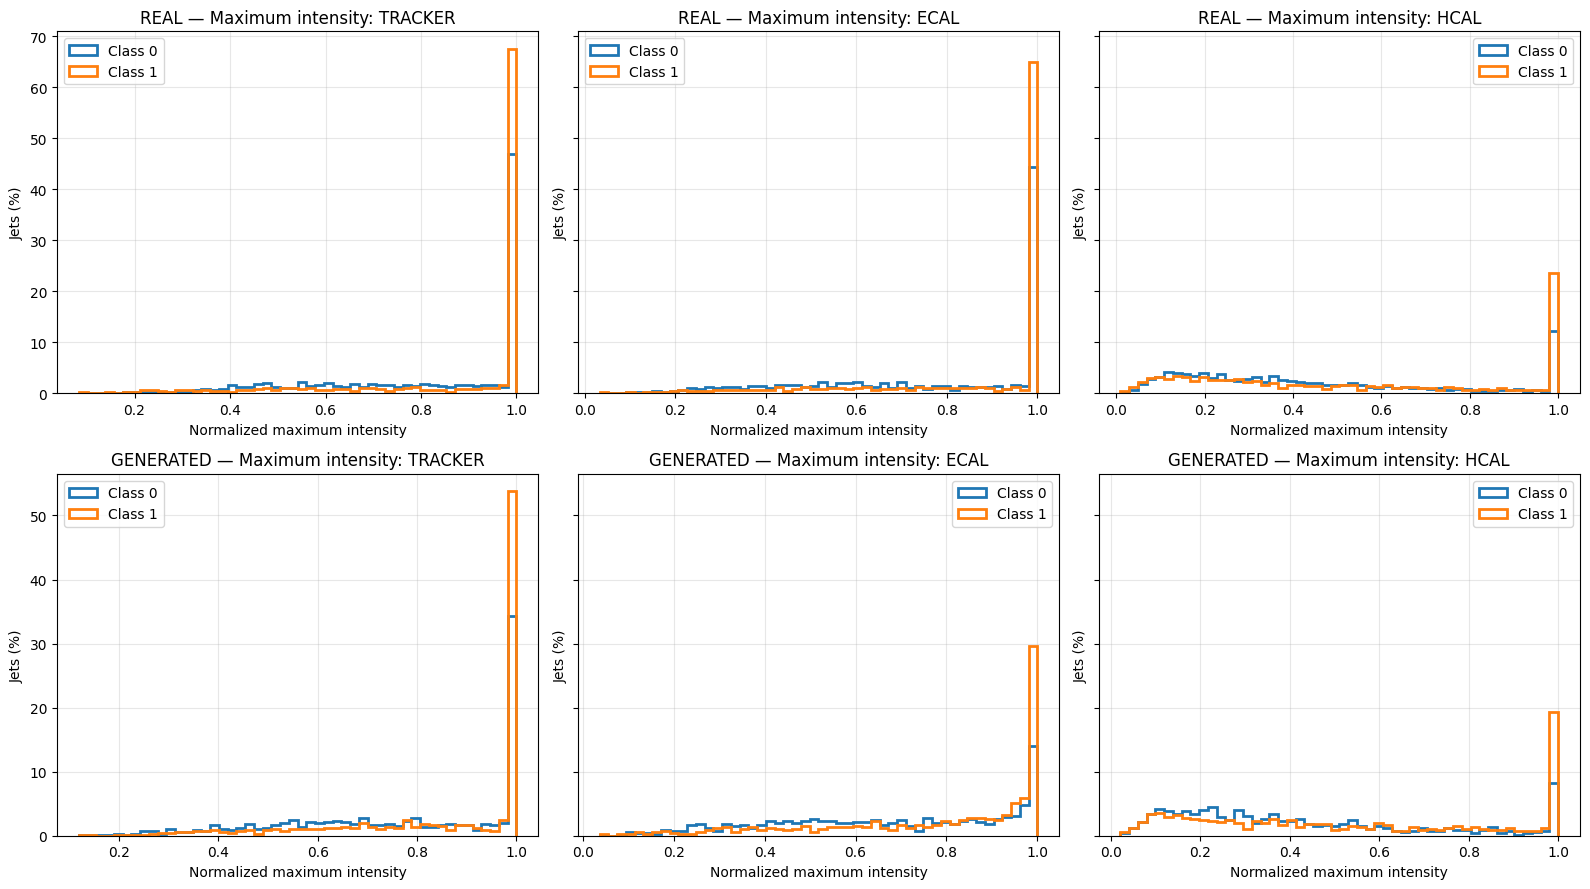

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Maximum intensity: TRACKER'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Maximum intensity: ECAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Maximum intensity: HCAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Maximum intensity: TRACKER'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Maximum intensity: ECAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Maximum intensity: HCAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>]],
       dtype=object))

In [104]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='maximum', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

In [105]:
@torch.no_grad()
def reconstruct_dataset_with_vae_hard(vae_model, data_loader, device=device):
    vae_model.eval()
    reconstruction_batches = []

    for images, _ in tqdm(data_loader, desc='Reconstruyendo test con VAE'):
        images = images.to(device, non_blocking=True)
        mu, _ = vae_model.encode(images)
        reconstruction_m11 = vae_model.decode_hard(mu)
        reconstruction_01 = ((reconstruction_m11 + 1.0) / 2.0).clamp(0.0, 1.0)

        reconstruction_batches.append(reconstruction_01.detach().cpu())

    return torch.cat(reconstruction_batches, dim=0)

In [106]:
vae_reconstructed_test_01 = reconstruct_dataset_with_vae_hard(vae_model=vae_model, data_loader=test_loader, device=device)
print('Shape:', vae_reconstructed_test_01.shape)

Reconstruyendo test con VAE:   0%|          | 0/157 [00:00<?, ?it/s]

Shape: torch.Size([2500, 3, 64, 64])


In [107]:
vae_diag = collect_image_diagnostics(vae_reconstructed_test_01, active_thr_01=0.0001, num_radial_bins=32)

In [108]:
def compare_real_vae_ldm(real_diag, vae_diag, ldm_diag):
    rows = []

    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = real_diag['energy'][:, channel]
        energy_vae = vae_diag['energy'][:, channel]
        energy_ldm = ldm_diag['energy'][:, channel]
        active_real = real_diag['active_fraction'][:, channel]
        active_vae = vae_diag['active_fraction'][:, channel]
        active_ldm = ldm_diag['active_fraction'][:, channel]
        maximum_real = real_diag['maximum'][:, channel]
        maximum_vae = vae_diag['maximum'][:, channel]
        maximum_ldm = ldm_diag['maximum'][:, channel]
        radial_real = real_diag['radial_profile'][channel]
        radial_vae = vae_diag['radial_profile'][channel]
        radial_ldm = ldm_diag['radial_profile'][channel]
        energy_real_mean = energy_real.mean()

        rows.append({
            'Canal': channel_name,
            'E real': energy_real_mean,
            'E VAE': energy_vae.mean(),
            'E LDM': energy_ldm.mean(),
            'Bias E VAE (%)': 100.0 * (energy_vae.mean() - energy_real_mean) / max(energy_real_mean, 1e-12),
            'Bias E LDM (%)': 100.0 * (energy_ldm.mean() - energy_real_mean) / max(energy_real_mean, 1e-12),
            'W1 E VAE': wasserstein_distance(energy_real, energy_vae),
            'W1 E LDM': wasserstein_distance(energy_real, energy_ldm),
            'Activa real': active_real.mean(),
            'Activa VAE': active_vae.mean(),
            'Activa LDM': active_ldm.mean(),
            'Máximo real': maximum_real.mean(),
            'Máximo VAE': maximum_vae.mean(),
            'Máximo LDM': maximum_ldm.mean(),
            'W1 máximo VAE': wasserstein_distance(maximum_real, maximum_vae),
            'W1 máximo LDM': wasserstein_distance(maximum_real, maximum_ldm),
            'Radial L2 VAE': np.sqrt(np.mean((radial_vae - radial_real) ** 2)),
            'Radial L2 LDM': np.sqrt(np.mean((radial_ldm - radial_real) ** 2)),
        })

    return pd.DataFrame(rows)

In [109]:
comparison_real_vae_ldm = compare_real_vae_ldm(real_diag=real_diag, vae_diag=vae_diag, ldm_diag=gen_diag)
display(comparison_real_vae_ldm.round(6))

,Canal,E real,E VAE,E LDM,Bias E VAE (%),Bias E LDM (%),W1 E VAE,W1 E LDM,Activa real,Activa VAE,Activa LDM,Máximo real,Máximo VAE,Máximo LDM,W1 máximo VAE,W1 máximo LDM,Radial L2 VAE,Radial L2 LDM
0,TRACKER,7.456671,7.890220,7.249526,5.814236,-2.777979,0.433548,0.245432,0.041387,0.041118,0.033303,0.847103,0.863391,0.812677,0.016786,0.036234,0.011066,0.012257
1,ECAL,7.516253,7.236193,7.208539,-3.726056,-4.093981,0.298561,0.313331,0.053120,0.052852,0.048189,0.815551,0.815335,0.723244,0.013872,0.092347,0.003078,0.003477
2,HCAL,10.180333,10.111298,10.081417,-0.678126,-0.971639,0.074364,0.305849,0.044640,0.044858,0.047496,0.483430,0.493838,0.473194,0.010741,0.013217,0.001041,0.003013


In [110]:
baseline_val_normal = evaluate_latent_ddpm_epoch(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)
print('Baseline normal:', baseline_val_normal)

Baseline normal: 0.6665610840797425


In [111]:
def zero_bottleneck_output(module, inputs, output):
    return torch.zeros_like(output)

hook = ldm_model_first.mid.register_forward_hook(zero_bottleneck_output)
baseline_val_zero_mid = evaluate_latent_ddpm_epoch(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)
hook.remove()
print('Baseline normal:', baseline_val_normal)
print('Bottleneck = 0:', baseline_val_zero_mid)
print('Delta:', baseline_val_zero_mid - baseline_val_normal)

Baseline normal: 0.6665610840797425
Bottleneck = 0: 0.6851577802658081
Delta: 0.01859669618606563


In [112]:
class ZeroVPredictor(nn.Module):

    def forward(
        self,
        x,
        t,
        labels,
    ):
        return torch.zeros_like(x)

zero_v_model = ZeroVPredictor().to(device)

zero_v_validation_loss = evaluate_latent_ddpm_epoch(
    model=zero_v_model, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)

print('Zero-v validation:', zero_v_validation_loss)

print('Classical validation:', baseline_val_normal)

print('Improvement:', zero_v_validation_loss - baseline_val_normal)

Zero-v validation: 1.0477441463470458
Classical validation: 0.6665610840797425
Improvement: 0.38118306226730336


In [113]:
class AblatedReducedUNET(nn.Module):

    def __init__(
        self,
        backbone,
        ablation=None,
    ):
        super().__init__()

        self.backbone = backbone
        self.ablation = ablation

    def forward(
        self,
        x,
        t,
        labels,
    ):

        time_embedding = (
            self.backbone.time_mlp(t)
        )

        class_embedding = (
            self.backbone.class_embedding(
                labels.long()
            )
        )

        condition_embedding = (
            time_embedding
            + class_embedding
        )

        x = self.backbone.conv_in(x)

        skips = []

        skip_names = [
            "skip_16",
            "skip_8",
            "skip_4",
        ]

        for index, down in enumerate(
            self.backbone.downs
        ):

            x, skip = down(
                x,
                condition_embedding,
            )

            if (
                self.ablation
                == skip_names[index]
            ):
                skip = torch.zeros_like(
                    skip
                )

            skips.append(skip)

        x = self.backbone.mid(
            x,
            condition_embedding,
        )

        if self.ablation == "mid":
            x = torch.zeros_like(x)

        for up in self.backbone.ups:

            skip = skips.pop()

            x = up(
                x,
                skip,
                condition_embedding,
            )

        x = self.backbone.norm_out(x)

        x = F.silu(x)

        return self.backbone.conv_out(x)

In [114]:
ablation_cases = [('Normal', None), ('Skip 16x16 = 0', 'skip_16'), ('Skip 8x8 = 0', 'skip_8'), ('Skip 4x4 = 0', 'skip_4'), ('Bottleneck = 0', 'mid')]
ablation_results = []

for name, ablation in ablation_cases:
    ablated_model = AblatedReducedUNET(backbone=ldm_model_first, ablation=ablation)
    validation_loss = evaluate_latent_ddpm_epoch(
        model=ablated_model, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
        fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
    )
    ablation_results.append({'component': name, 'validation_loss': validation_loss, 'delta_vs_baseline': validation_loss - baseline_val_normal})

ablation_results_df = pd.DataFrame(ablation_results)
display(ablation_results_df.round(6))

,component,validation_loss,delta_vs_baseline
0,Normal,0.666561,0.000000
1,Skip 16x16 = 0,0.948189,0.281627
2,Skip 8x8 = 0,0.740291,0.073730
3,Skip 4x4 = 0,0.671533,0.004972
4,Bottleneck = 0,0.685158,0.018597


In [115]:
@torch.no_grad()
def evaluate_latent_ddpm_by_timestep_bins(model, data_loader, scheduler, device, fixed_conditions, bin_width=100):
    model.eval()
    rows = []

    for start in range(0, scheduler.num_timesteps, bin_width):
        end = min(start + bin_width, scheduler.num_timesteps)
        loss_sum = 0.0
        v_loss_sum = 0.0
        tail_loss_sum = 0.0
        count = 0

        for batch_index, (z0, labels) in enumerate(data_loader):
            z0 = z0.float().to(device)
            labels = labels.long().to(device)
            timesteps_cpu, noise_cpu = fixed_conditions[batch_index]
            timesteps = timesteps_cpu.to(device=device, dtype=torch.long)
            noise = noise_cpu.to(device=device, dtype=z0.dtype)
            mask = (timesteps >= start) & (timesteps < end)

            if not mask.any():
                continue

            noisy_latents, noise_used = scheduler.add_noise(z0, timesteps, noise)
            v_target = compute_v_target(z0=z0, noise=noise_used, timesteps=timesteps, scheduler=scheduler)
            v_prediction = model(noisy_latents, timesteps, labels)
            n = int(mask.sum().item())
            loss, components = latent_v_loss(
                z0=z0[mask], z_t=noisy_latents[mask], v_prediction=v_prediction[mask], v_target=v_target[mask],
                timesteps=timesteps[mask], scheduler=scheduler, tail_loss_weight=0.15,
            )
            loss_sum += components['loss'].item() * n
            v_loss_sum += components['v_loss'].item() * n
            tail_loss_sum += components['tail_loss'].item() * n
            count += n

        rows.append({
            't_range': f'{start:03d}-{end - 1:03d}',
            'n': count,
            'loss': loss_sum / max(count, 1),
            'v_loss': v_loss_sum / max(count, 1),
            'tail_loss': tail_loss_sum / max(count, 1),
        })

    return pd.DataFrame(rows)

In [116]:
classical_timestep_results = evaluate_latent_ddpm_by_timestep_bins(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS, bin_width=100,
)
zero_timestep_results = evaluate_latent_ddpm_by_timestep_bins(
    model=zero_v_model, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS, bin_width=100,
)
timestep_comparison = pd.DataFrame({
    't_range': classical_timestep_results['t_range'],
    'n': classical_timestep_results['n'],
    'zero_loss': zero_timestep_results['loss'],
    'classical_loss': classical_timestep_results['loss'],
})
timestep_comparison['absolute_gain'] = timestep_comparison['zero_loss'] - timestep_comparison['classical_loss']
timestep_comparison['relative_gain_pct'] = 100.0 * timestep_comparison['absolute_gain'] / timestep_comparison['zero_loss']

display(timestep_comparison.round(6))

,t_range,n,zero_loss,classical_loss,absolute_gain,relative_gain_pct
0,000-099,236,1.003780,0.736511,0.267268,26.626195
1,100-199,269,1.018434,0.553520,0.464914,45.649906
2,200-299,250,1.031514,0.505500,0.526015,50.994402
3,300-399,222,1.050417,0.508147,0.542270,51.624280
4,400-499,252,1.044563,0.587705,0.456858,43.736767
5,500-599,244,1.074167,0.667663,0.406503,37.843586
6,600-699,264,1.071241,0.716348,0.354893,33.129111
7,700-799,247,1.064383,0.782857,0.281525,26.449639
8,800-899,268,1.038509,0.771026,0.267484,25.756500
9,900-999,248,1.080973,0.824103,0.256870,23.762838


## Q10 — Three-Core Quantum Denoiser

Q10 replaces the U-Net denoiser with a compact model containing three independent eight-qubit cores: a content circuit, a condition circuit, and a fusion circuit. The trainable quantum model is compared with a frozen-circuit version and a parameter-matched classical MLP control under identical training and validation conditions.

In [117]:
q10_required = [
    'vae_model', 'ldm_model_first', 'ldm_scheduler', 'ldm_train_dataset', 'ldm_val_dataset', 'ldm_val_latents',
    'ldm_val_labels', 'latent_mean_train', 'latent_std_train', 'val_dataset', 'FIXED_LDM_VAL_CONDITIONS',
    'compute_v_target', 'latent_v_loss', 'train_latent_ddpm', 'decode_generated_latents',
    'collect_image_diagnostics', 'summarize_real_vs_generated', 'summarize_generation_by_class', 'zero_v_model',
    'seed_everything', 'device', 'SEED', 'NUM_CLASSES',
]
q10_missing = [name for name in q10_required if name not in globals()]

if q10_missing:
    raise RuntimeError('Este bloque continúa el baseline Q9 en la misma sesión. Faltan: ' + ', '.join(q10_missing))

Q10_SEED = SEED
Q10_BATCH_SIZE = 8
Q10_EPOCHS = 20
Q10_LEARNING_RATE = 0.001
Q10_VARIANTS = ('Q', 'Q_fixed', 'C')
Q10_SAMPLING_STEPS = 50
Q10_NUM_GENERATED = 128
Q10_CONFIG = dict(n_qubits=8, depth=3, num_classes=NUM_CLASSES, in_channels=4, time_dim=16, chunk_size=128, entangle=True)

if tuple(ldm_val_latents.shape[1:]) != (4, 16, 16):
    raise ValueError('Esta arquitectura está preparada para latentes 4×16×16.')

if min(len(ldm_train_dataset), len(ldm_val_dataset)) == 0:
    raise ValueError('El entrenamiento y la validación necesitan ejemplos.')

vae_model.eval().requires_grad_(False)

SimpleConvVAE16Occupancy(
  (encoder): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): SiLU()
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (2): SiLU()
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): GroupNorm(8, 256, eps=1e-05, affine=True)
        (2): SiLU()
      )
    )
  )
  (to_mu): Conv2d(256, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (to_log_var): Conv2d(256, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec_in): ConvBlock(
    (block): Sequential(
      (0): Conv2d(4, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Grou

In [118]:
q10_val_timesteps = torch.cat([t for t, noise in FIXED_LDM_VAL_CONDITIONS])
q10_val_noise = torch.cat([noise for t, noise in FIXED_LDM_VAL_CONDITIONS])

if q10_val_noise.shape != ldm_val_latents.shape:
    raise ValueError('Las condiciones originales no corresponden a estos latentes.')

q10_val_loader = DataLoader(ldm_val_dataset, batch_size=Q10_BATCH_SIZE, shuffle=False, num_workers=0)
q10_val_conditions = [(q10_val_timesteps[i:i + Q10_BATCH_SIZE], q10_val_noise[i:i + Q10_BATCH_SIZE]) for i in range(0, len(ldm_val_dataset), Q10_BATCH_SIZE)]
print('Dispositivo:', device)
print('Train:', len(ldm_train_dataset), '| Validación:', len(ldm_val_dataset))
print('VAE congelado; se reutiliza la validación fija del baseline.')

Dispositivo: mps
Train: 10000 | Validación: 2500
VAE congelado; se reutiliza la validación fija del baseline.


In [119]:
def apply_ry(state, angle, wire, n_qubits):
    blocks = state.reshape(-1, 2 ** wire, 2, 2 ** (n_qubits - wire - 1))
    a, b = blocks[:, :, 0, :], blocks[:, :, 1, :]
    c = torch.cos(angle / 2).reshape(-1, 1, 1)
    s = torch.sin(angle / 2).reshape(-1, 1, 1)

    return torch.stack((c * a - s * b, s * a + c * b), dim=2).reshape_as(state)


class ExactRYCircuit(nn.Module):
    def __init__(self, n_qubits=8, depth=3, chunk_size=128, entangle=True):
        super().__init__()

        if not 2 <= n_qubits <= 12 or depth < 1 or chunk_size < 1:
            raise ValueError("Usa 2..12 qubits, profundidad y chunk_size positivos.")

        self.n_qubits, self.depth = n_qubits, depth
        self.chunk_size, self.entangle = chunk_size, entangle
        self.theta = nn.Parameter(torch.empty(depth, 2, n_qubits))

        nn.init.uniform_(self.theta, -0.35, 0.35)
        basis = torch.arange(2 ** n_qubits)
        signs = [1 - 2 * ((basis >> (n_qubits - 1 - w)) & 1) for w in range(n_qubits)]
        self.register_buffer("z_signs", torch.stack(signs).float())

        self.forward_edges = [(w, w + 1) for w in range(n_qubits - 1)]
        self.backward_edges = [(w + 1, w) for w in reversed(range(n_qubits - 1))]

        for k, (control, target) in enumerate(self.forward_edges + self.backward_edges):
            perm = basis ^ (((basis >> (n_qubits - 1 - control)) & 1) << (n_qubits - 1 - target))
            self.register_buffer(f"cnot_{k}", perm)

    def statevector(self, angles):
        if angles.ndim != 2 or angles.shape[1] != self.n_qubits:
            raise ValueError("El circuito espera [n_ejemplos, n_qubits].")

        state = F.pad(torch.ones_like(angles[:, :1]), (0, 2 ** self.n_qubits - 1))
        n_edges = self.n_qubits - 1

        for layer in range(self.depth):
            for wire in range(self.n_qubits):
                state = apply_ry(state, angles[:, wire] + self.theta[layer, 0, wire], wire, self.n_qubits)

            if self.entangle:
                for k in range(n_edges):
                    state = state.index_select(1, getattr(self, f"cnot_{k}"))

            for wire in range(self.n_qubits):
                state = apply_ry(state, self.theta[layer, 1, wire], wire, self.n_qubits)

            if self.entangle:
                for k in range(n_edges, 2 * n_edges):
                    state = state.index_select(1, getattr(self, f"cnot_{k}"))

        return state

    def forward(self, angles):
        outputs = []

        for chunk in angles.split(self.chunk_size, dim=0):
            state = self.statevector(chunk)
            outputs.append(state.square() @ self.z_signs.T)

        return torch.cat(outputs, dim=0)


class ClassicalCircuitControl(nn.Module):
    def __init__(self, n_qubits, depth):
        super().__init__()
        target_parameters = 2 * n_qubits * depth
        hidden = max(1, math.ceil((target_parameters - n_qubits) / (2 * n_qubits + 1)))
        self.net = nn.Sequential(nn.Linear(n_qubits, hidden), nn.SiLU(),
                                 nn.Linear(hidden, n_qubits), nn.Tanh())

    def forward(self, angles):
        return self.net(angles)


class QuantumCoreDenoiser(nn.Module):
    interface_names = ("input_projection", "position_projection", "time_projection",
                       "class_embedding", "output_projection")

    def __init__(self, n_qubits=8, depth=3, num_classes=2, in_channels=4,
                 time_dim=16, chunk_size=128, variant="Q", entangle=True):
        super().__init__()

        if variant not in ("Q", "Q_fixed", "C") or time_dim < 2 or time_dim % 2:
            raise ValueError("Variante inválida o time_dim no par.")

        self.config = dict(n_qubits=n_qubits, depth=depth, num_classes=num_classes,
                           in_channels=in_channels, time_dim=time_dim,
                           chunk_size=chunk_size, variant=variant, entangle=entangle)
        self.n_qubits, self.variant = n_qubits, variant

        self.input_projection = nn.Conv2d(in_channels, n_qubits, 4, stride=2, padding=1)
        self.position_projection = nn.Linear(3, n_qubits, bias=False)
        self.time_projection = nn.Linear(time_dim, n_qubits)
        self.class_embedding = nn.Embedding(num_classes, n_qubits)
        self.output_projection = nn.Conv2d(n_qubits, 4 * in_channels, 1)
        frequencies = torch.exp(-math.log(10000) * torch.arange(time_dim // 2).float()
                                / max(time_dim // 2 - 1, 1))

        self.register_buffer("time_frequencies", frequencies)
        names = ("content", "condition", "fusion")

        if variant == "C":
            self.cores = nn.ModuleDict({name: ClassicalCircuitControl(n_qubits, depth) for name in names})
        else:
            self.cores = nn.ModuleDict({name: ExactRYCircuit(n_qubits, depth, chunk_size, entangle) for name in names})

        if variant == "Q_fixed":
            self.cores.requires_grad_(False)

        nn.init.normal_(self.output_projection.weight, std=0.12)
        nn.init.zeros_(self.output_projection.bias)
        nn.init.normal_(self.class_embedding.weight, std=0.05)

    @staticmethod
    def encode_angles(features):

        return 2.0 * torch.atan(features / 2.0)

    def spatial_core(self, features, name):
        batch, channels, height, width = features.shape
        flat = features.permute(0, 2, 3, 1).reshape(-1, channels)
        output = self.cores[name](self.encode_angles(flat))

        return output.reshape(batch, height, width, channels).permute(0, 3, 1, 2)

    def forward(self, z_t, timesteps, labels):
        if z_t.ndim != 4 or z_t.shape[1] != self.config["in_channels"]:
            raise ValueError("Forma de z_t incompatible.")

        if min(z_t.shape[-2:]) < 4 or any(d % 2 for d in z_t.shape[-2:]):
            raise ValueError("Las dimensiones espaciales deben ser pares y >=4.")

        if timesteps.shape != labels.shape or labels.numel() != z_t.shape[0]:
            raise ValueError("Se necesita un timestep y una clase por jet.")

        features = self.input_projection(z_t)
        height, width = features.shape[-2:]
        yy, xx = torch.meshgrid(torch.linspace(-1, 1, height, device=z_t.device, dtype=z_t.dtype),
                                torch.linspace(-1, 1, width, device=z_t.device, dtype=z_t.dtype), indexing="ij")
        coordinates = torch.stack((xx, yy, xx.square() + yy.square()), dim=-1)
        positions = self.position_projection(coordinates).permute(2, 0, 1)[None]
        content = self.spatial_core(features + positions, "content")
        time_angles = timesteps.to(z_t.dtype)[:, None] * self.time_frequencies[None]
        time_features = torch.cat((time_angles.sin(), time_angles.cos()), dim=-1)
        condition_input = self.time_projection(time_features) + self.class_embedding(labels.long())
        condition = self.cores["condition"](self.encode_angles(condition_input))
        neighbors = F.avg_pool2d(content, 3, stride=1, padding=1, count_include_pad=False)
        context = 0.5 * content + 0.5 * neighbors
        fusion_input = (context + condition[:, :, None, None]) / math.sqrt(2)
        fused = self.spatial_core(fusion_input, "fusion")

        return F.pixel_shuffle(self.output_projection(fused), upscale_factor=2)

    def quantum_parameters(self):
        for core in self.cores.values():
            if isinstance(core, ExactRYCircuit):
                yield core.theta

    def parameter_counts(self):
        quantum_ids = {id(p) for p in self.quantum_parameters()}

        return {
            "total": sum(p.numel() for p in self.parameters()),
            "trainable": sum(p.numel() for p in self.parameters() if p.requires_grad),
            "quantum_total": sum(p.numel() for p in self.parameters() if id(p) in quantum_ids),
            "quantum_trainable": sum(p.numel() for p in self.parameters() if id(p) in quantum_ids and p.requires_grad),
            "classical_trainable": sum(p.numel() for p in self.parameters() if id(p) not in quantum_ids and p.requires_grad),
        }


def q10_make_matched_models(config, seed):
    seed_everything(seed)
    q_model = QuantumCoreDenoiser(**config, variant='Q')
    fixed = deepcopy(q_model)
    fixed.variant, fixed.config['variant'] = ('Q_fixed', 'Q_fixed')

    fixed.cores.requires_grad_(False)
    seed_everything(seed + 1)
    classical = QuantumCoreDenoiser(**config, variant='C')

    for name in QuantumCoreDenoiser.interface_names:
        getattr(classical, name).load_state_dict(getattr(q_model, name).state_dict())

    return {'Q': q_model, 'Q_fixed': fixed, 'C': classical}

In [120]:
q10_models = q10_make_matched_models(Q10_CONFIG, Q10_SEED)
q10_initial_angles = {name: {core_name: core.theta.detach().cpu().clone() for core_name, core in model.cores.items() if isinstance(
    core, ExactRYCircuit,
)} for name, model in q10_models.items()}
q10_parameter_table = pd.DataFrame([{'Modelo': name, **model.parameter_counts()} for name, model in q10_models.items()])

display(q10_parameter_table)

,Modelo,total,trainable,quantum_total,quantum_trainable,classical_trainable
0,Q,984,984,144,144,840
1,Q_fixed,984,840,144,0,840
2,C,1017,1017,0,0,1017


In [121]:
q10_probe_model = q10_models['Q'].to(device)
q10_probe_model.train()
q10_probe_z, q10_probe_y = next(iter(q10_val_loader))
q10_probe_z = q10_probe_z.float().to(device)
q10_probe_y = q10_probe_y.long().to(device)
q10_probe_t = q10_val_conditions[0][0].to(device)
q10_probe_noise = q10_val_conditions[0][1].to(device)
q10_probe_xt, q10_probe_noise = ldm_scheduler.add_noise(q10_probe_z, q10_probe_t, q10_probe_noise)
q10_probe_target = compute_v_target(q10_probe_z, q10_probe_noise, q10_probe_t, ldm_scheduler)
q10_probe_prediction = q10_probe_model(q10_probe_xt, q10_probe_t, q10_probe_y)
assert q10_probe_prediction.shape == q10_probe_z.shape
q10_probe_loss, _ = latent_v_loss(q10_probe_z, q10_probe_xt, q10_probe_prediction, q10_probe_target, q10_probe_t, ldm_scheduler)
q10_probe_loss.backward()
q10_gradient_rows = []

for q10_core_name, q10_core in q10_probe_model.cores.items():
    q10_gradient = q10_core.theta.grad

    if q10_gradient is None or not torch.isfinite(q10_gradient).all():
        raise RuntimeError(f'Gradiente cuántico inválido en {q10_core_name}.')

    q10_gradient_rows.append({'Circuito': q10_core_name, 'Norma del gradiente': q10_gradient.norm().item()})

display(pd.DataFrame(q10_gradient_rows))
q10_probe_model.zero_grad(set_to_none=True)
q10_probe_model.cpu()
del q10_probe_prediction, q10_probe_loss

,Circuito,Norma del gradiente
0,content,0.004761
1,condition,0.011546
2,fusion,0.026751


In [122]:
q10_histories = {}
q10_fit_seconds = {}

for q10_name in Q10_VARIANTS:
    print('\nEntrenando:', q10_name)
    seed_everything(Q10_SEED)
    q10_train_loader = DataLoader(ldm_train_dataset, batch_size=Q10_BATCH_SIZE, shuffle=True, num_workers=0, generator=torch.Generator().manual_seed(Q10_SEED))
    q10_current_model = q10_models[q10_name].to(device)
    q10_start_time = time.perf_counter()
    q10_histories[q10_name] = train_latent_ddpm(
        model=q10_current_model, train_loader=q10_train_loader, val_loader=q10_val_loader,
        scheduler=ldm_scheduler, device=device, fixed_validation_conditions=q10_val_conditions,
        num_epochs=Q10_EPOCHS, learning_rate=Q10_LEARNING_RATE, grad_clip=1.0,
    )
    q10_fit_seconds[q10_name] = time.perf_counter() - q10_start_time

    q10_current_model.cpu()


Entrenando: Q


LDM Epoch 01/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 01/20 | train=0.978336 | val=0.949425 | lr=1.00e-03 | time=143.09s


LDM Epoch 02/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 02/20 | train=0.943397 | val=0.936334 | lr=1.00e-03 | time=144.68s


...

Epoch 18/20 | train=0.857283 | val=0.856802 | lr=1.00e-03 | time=10.08s


LDM Epoch 19/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 19/20 | train=0.857177 | val=0.857592 | lr=1.00e-03 | time=9.38s


LDM Epoch 20/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 20/20 | train=0.855448 | val=0.853802 | lr=1.00e-03 | time=9.22s

Mejor validation loss: 0.853802


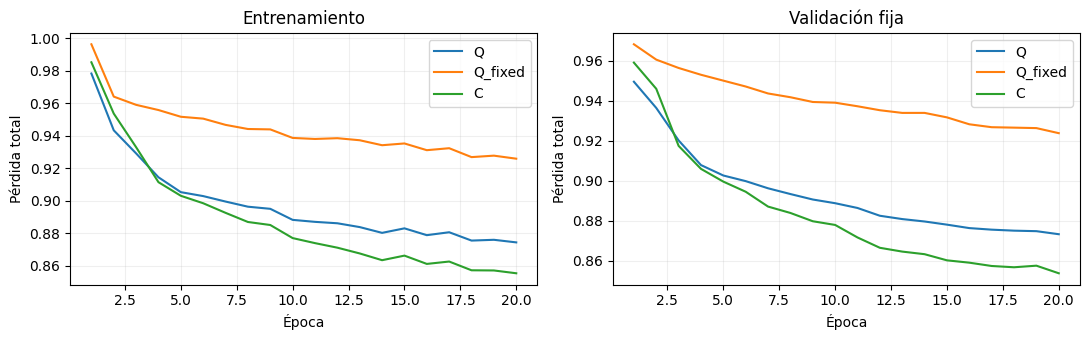

In [123]:
q10_figure, q10_axes = plt.subplots(1, 2, figsize=(11, 3.5))

for q10_name, q10_history in q10_histories.items():
    q10_epochs = range(1, len(q10_history['train']) + 1)
    q10_axes[0].plot(q10_epochs, q10_history['train'], label=q10_name)
    q10_axes[1].plot(q10_epochs, q10_history['val'], label=q10_name)

for q10_axis, q10_title in zip(q10_axes, ('Entrenamiento', 'Validación fija')):
    q10_axis.set(xlabel='Época', ylabel='Pérdida total', title=q10_title)
    q10_axis.legend()
    q10_axis.grid(alpha=0.2)

q10_figure.tight_layout()
plt.show()

In [124]:
@torch.no_grad()
def q10_evaluate(model, bin_width=100):
    model.to(device).eval()
    names = ('loss', 'v_loss', 'tail_loss')
    totals = dict.fromkeys(names, 0.0)
    bins = {start: dict(n=0, **dict.fromkeys(names, 0.0)) for start in range(0, ldm_scheduler.num_timesteps, bin_width)}
    count = 0

    for batch_index, (z0, labels) in enumerate(q10_val_loader):
        z0, labels = (z0.float().to(device), labels.long().to(device))
        t_cpu, noise_cpu = q10_val_conditions[batch_index]
        t, noise = (t_cpu.to(device), noise_cpu.to(device))
        zt, noise = ldm_scheduler.add_noise(z0, t, noise)
        target = compute_v_target(z0, noise, t, ldm_scheduler)
        prediction = model(zt, t, labels)
        _, components = latent_v_loss(z0, zt, prediction, target, t, ldm_scheduler)

        for key in names:
            if not torch.isfinite(components[key]):
                raise RuntimeError(f'Evaluación no finita: {key}.')

            totals[key] += components[key].item() * len(z0)

        count += len(z0)

        for start, record in bins.items():
            mask = (t >= start) & (t < start + bin_width)
            n = int(mask.sum().item())

            if n:
                _, parts = latent_v_loss(z0[mask], zt[mask], prediction[mask], target[mask], t[mask], ldm_scheduler)
                record['n'] += n

                for key in names:
                    record[key] += parts[key].item() * n

    rows = []

    for start, record in bins.items():
        end = min(start + bin_width, ldm_scheduler.num_timesteps)
        rows.append({'t_range': f'{start:03d}-{end - 1:03d}', 'n': record['n'], **{key: record[key] / record['n'] if record['n'] else np.nan for key in names}})

    return ({key: totals[key] / count for key in names}, pd.DataFrame(rows))

In [125]:
q10_comparison_models = {'U-Net Q9': ldm_model_first, 'Zero-v': zero_v_model, **{name: q10_models[name] for name in q10_histories}}
q10_loss_rows, q10_bin_tables = ([], [])

for q10_name, q10_current_model in q10_comparison_models.items():
    q10_metrics, q10_bins = q10_evaluate(q10_current_model)
    q10_loss_rows.append({'Modelo': q10_name, **q10_metrics})
    q10_bins.insert(0, 'Modelo', q10_name)
    q10_bin_tables.append(q10_bins)

    if q10_name in q10_models:
        q10_current_model.cpu()

q10_angle_rows = []

for q10_name in q10_histories:
    for q10_core_name, q10_initial in q10_initial_angles[q10_name].items():
        q10_final = q10_models[q10_name].cores[q10_core_name].theta.detach().cpu()
        q10_angle_rows.append({'Modelo': q10_name, 'Circuito': q10_core_name, 'Cambio RMS de ángulos': (q10_final - q10_initial).square().mean().sqrt().item()})

if 'Q' in q10_histories:
    q10_reset_model = deepcopy(q10_models['Q'])

    with torch.no_grad():
        for q10_core_name, q10_initial in q10_initial_angles['Q'].items():
            q10_reset_model.cores[q10_core_name].theta.copy_(q10_initial)

    q10_reset_metrics, _ = q10_evaluate(q10_reset_model)
    q10_loss_rows.append({'Modelo': 'Q con ángulos iniciales', **q10_reset_metrics})
    del q10_reset_model

q10_loss_table = pd.DataFrame(q10_loss_rows)
q10_bin_table = pd.concat(q10_bin_tables, ignore_index=True)
q10_angle_table = pd.DataFrame(q10_angle_rows)

display(q10_loss_table.round(6))
display(q10_angle_table)
display(q10_bin_table.round(6))

,Modelo,loss,v_loss,tail_loss
0,U-Net Q9,0.666561,0.633658,0.219352
1,Zero-v,1.047744,0.999843,0.319339
2,Q,0.873301,0.832905,0.269301
3,Q_fixed,0.923740,0.880869,0.285808
4,C,0.853802,0.814291,0.263406
5,Q con ángulos iniciales,5.413842,5.239672,1.161134


,Modelo,Circuito,Cambio RMS de ángulos
0,Q,content,0.565481
1,Q,condition,0.231550
2,Q,fusion,0.410398
3,Q_fixed,content,0.000000
4,Q_fixed,condition,0.000000
5,Q_fixed,fusion,0.000000


,Modelo,t_range,n,loss,v_loss,tail_loss
0,U-Net Q9,000-099,236,0.736511,0.734651,0.012403
1,U-Net Q9,100-199,269,0.553520,0.544236,0.061896
2,U-Net Q9,200-299,250,0.505500,0.487198,0.122010
3,U-Net Q9,300-399,222,0.508147,0.481896,0.175007
4,U-Net Q9,400-499,252,0.587705,0.552548,0.234376
5,U-Net Q9,500-599,244,0.667663,0.625597,0.280442
6,U-Net Q9,600-699,264,0.716348,0.670964,0.302562
7,U-Net Q9,700-799,247,0.782857,0.733681,0.327843
8,U-Net Q9,800-899,268,0.771026,0.722677,0.322325
9,U-Net Q9,900-999,248,0.824103,0.772860,0.341619


In [126]:
@torch.no_grad()
def q10_sample_ddim(model, initial_noise, class_labels, num_steps):
    if not 1 <= num_steps <= ldm_scheduler.num_timesteps:
        raise ValueError('Número de pasos DDIM fuera de rango.')

    model.eval()
    z = initial_noise.to(device).float().clone()
    labels = class_labels.long().to(device)
    steps = torch.linspace(ldm_scheduler.num_timesteps - 1, 0, num_steps).round().long().tolist()

    for index, timestep in enumerate(steps):
        t = torch.full((len(z),), timestep, device=device, dtype=torch.long)
        v = model(z, t, labels)
        a = ldm_scheduler.sqrt_alpha_cum_prod[timestep]
        b = ldm_scheduler.sqrt_one_minus_alpha_cum_prod[timestep]
        clean = a * z - b * v
        predicted_noise = b * z + a * v

        if index + 1 == len(steps):
            z = clean
        else:
            previous = steps[index + 1]
            z = ldm_scheduler.sqrt_alpha_cum_prod[previous] * clean + ldm_scheduler.sqrt_one_minus_alpha_cum_prod[previous] * predicted_noise

    if not torch.isfinite(z).all():
        raise RuntimeError('DDIM produjo latentes no finitos.')

    return z


@torch.no_grad()
def q10_decode_standardized(z_standardized):
    z = z_standardized.float().to(device)
    z = z * latent_std_train.to(device) + latent_mean_train.to(device)

    return decode_generated_latents(vae_model, z).cpu()


@torch.no_grad()
def q10_generate_images(model, initial_noise, class_labels):
    model.to(device).eval()
    batches = []

    for start in tqdm(range(0, len(class_labels), Q10_BATCH_SIZE), desc='Generando jets', leave=False):
        stop = start + Q10_BATCH_SIZE
        z = q10_sample_ddim(model, initial_noise[start:stop], class_labels[start:stop], Q10_SAMPLING_STEPS)
        batches.append(q10_decode_standardized(z))

    return torch.cat(batches)

In [127]:
q10_generation_rng = torch.Generator().manual_seed(Q10_SEED + 4000)
q10_sample_indices = torch.randperm(len(ldm_val_dataset), generator=q10_generation_rng)[:min(Q10_NUM_GENERATED, len(ldm_val_dataset))]
q10_generation_labels = ldm_val_labels[q10_sample_indices].long().cpu()
q10_initial_noise = torch.randn(len(q10_sample_indices), *ldm_val_latents.shape[1:], generator=q10_generation_rng)
q10_real_items = [val_dataset[int(i)] for i in q10_sample_indices]
q10_real_labels = torch.tensor([int(item[1]) for item in q10_real_items])

if not torch.equal(q10_real_labels, q10_generation_labels):
    raise ValueError('Las imágenes y los latentes de validación no están alineados.')

q10_real_images = ((torch.stack([item[0] for item in q10_real_items]).float() + 1) / 2).clamp(0, 1)
q10_generated_sets = {'VAE (reconstrucción)': torch.cat([q10_decode_standardized(ldm_val_latents[q10_sample_indices[i:i + Q10_BATCH_SIZE]]) for i in range(
    0, len(q10_sample_indices), Q10_BATCH_SIZE,
)])}

for q10_name, q10_current_model in {'U-Net Q9': ldm_model_first, **{name: q10_models[name] for name in q10_histories}}.items():
    print(q10_name)
    q10_generated_sets[q10_name] = q10_generate_images(q10_current_model, q10_initial_noise, q10_generation_labels)

    if q10_name in q10_models:
        q10_current_model.cpu()

U-Net Q9


Generando jets:   0%|          | 0/16 [00:00<?, ?it/s]

Q


Generando jets:   0%|          | 0/16 [00:00<?, ?it/s]

Q_fixed


Generando jets:   0%|          | 0/16 [00:00<?, ?it/s]

C


Generando jets:   0%|          | 0/16 [00:00<?, ?it/s]

In [128]:
q10_real_diagnostics = collect_image_diagnostics(q10_real_images)
q10_global_tables, q10_class_tables = ([], [])

for q10_name, q10_images in q10_generated_sets.items():
    q10_global = summarize_real_vs_generated(q10_real_diagnostics, collect_image_diagnostics(q10_images))
    q10_global.insert(0, 'Modelo', q10_name)
    q10_global_tables.append(q10_global)
    q10_by_class = summarize_generation_by_class(q10_real_images, q10_real_labels, q10_images, q10_generation_labels)
    q10_by_class.insert(0, 'Modelo', q10_name)
    q10_class_tables.append(q10_by_class)

q10_physics_table = pd.concat(q10_global_tables, ignore_index=True)
q10_physics_by_class = pd.concat(q10_class_tables, ignore_index=True)
display(q10_physics_table.round(6))
display(q10_physics_by_class.round(6))

Clase 0: 60 reales | 60 generados
Clase 1: 68 reales | 68 generados
Clase 0: 60 reales | 60 generados
Clase 1: 68 reales | 68 generados
Clase 0: 60 reales | 60 generados
Clase 1: 68 reales | 68 generados
Clase 0: 60 reales | 60 generados
Clase 1: 68 reales | 68 generados
Clase 0: 60 reales | 60 generados
Clase 1: 68 reales | 68 generados


,Modelo,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,VAE (reconstrucción),TRACKER,7.507598,7.981652,6.314315,0.487861,0.040421,0.040270,-0.015068,0.877278,0.899431,0.024072,0.005122,0.011748
1,VAE (reconstrucción),ECAL,7.336164,7.033576,-4.124614,0.312124,0.050760,0.050133,-0.062752,0.837836,0.839409,0.021181,0.001850,0.003544
2,VAE (reconstrucción),HCAL,11.102551,10.965981,-1.230078,0.200337,0.046173,0.045679,-0.049400,0.515786,0.527555,0.013090,0.000632,0.001346
3,U-Net Q9,TRACKER,7.507598,7.288099,-2.923693,0.488154,0.040421,0.035318,-0.510216,0.877278,0.817176,0.060101,0.006934,0.013526
4,U-Net Q9,ECAL,7.336164,7.348060,0.162157,0.273048,0.050760,0.050577,-0.018311,0.837836,0.750310,0.089538,0.004573,0.008037
5,U-Net Q9,HCAL,11.102551,9.381464,-15.501721,1.864828,0.046173,0.051273,0.510025,0.515786,0.465198,0.061952,0.001975,0.002912
6,Q,TRACKER,7.507598,13.434331,78.943130,5.926734,0.040421,0.074501,3.408050,0.877278,0.727649,0.150330,0.010300,0.016074
7,Q,ECAL,7.336164,8.226992,12.142968,1.412350,0.050760,0.075483,2.472305,0.837836,0.394012,0.443824,0.009441,0.013551
8,Q,HCAL,11.102551,8.036871,-27.612391,3.892579,0.046173,0.081938,3.576470,0.515786,0.399546,0.199882,0.006220,0.011789
9,Q_fixed,TRACKER,7.507598,14.093306,87.720566,6.585708,0.040421,0.075071,3.465080,0.877278,0.557274,0.320015,0.013505,0.023984


,Modelo,Clase,N real,N generado,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,VAE (reconstrucción),0,60,60,TRACKER,7.717796,8.208207,6.354292,0.490411,0.041321,0.041341,0.002034,0.843285,0.852745,0.013652,0.006207,0.013230
1,VAE (reconstrucción),0,60,60,ECAL,7.819076,7.451123,-4.705841,0.367954,0.056689,0.055745,-0.094401,0.817973,0.829397,0.027673,0.002021,0.003893
2,VAE (reconstrucción),0,60,60,HCAL,11.054346,10.843066,-1.911283,0.281906,0.048853,0.048140,-0.071208,0.493920,0.506503,0.016082,0.000707,0.001372
3,VAE (reconstrucción),1,68,68,TRACKER,7.322129,7.781749,6.277136,0.488130,0.039626,0.039325,-0.030158,0.907271,0.940624,0.035274,0.005260,0.012001
4,VAE (reconstrucción),1,68,68,ECAL,6.910064,6.665152,-3.544282,0.293385,0.045529,0.045180,-0.034826,0.855362,0.848242,0.023218,0.001898,0.003673
5,VAE (reconstrucción),1,68,68,HCAL,11.145084,11.074433,-0.633921,0.194449,0.043809,0.043507,-0.030158,0.535079,0.546131,0.012201,0.000620,0.001343
6,U-Net Q9,0,60,60,TRACKER,7.717796,7.582604,-1.751684,0.447151,0.041321,0.037533,-0.378825,0.843285,0.775173,0.070655,0.007623,0.014681
7,U-Net Q9,0,60,60,ECAL,7.819076,7.258424,-7.170313,0.629885,0.056689,0.053406,-0.328369,0.817973,0.699636,0.126185,0.006624,0.011646
8,U-Net Q9,0,60,60,HCAL,11.054346,9.008210,-18.509787,2.091299,0.048853,0.054370,0.551758,0.493920,0.423783,0.076654,0.002903,0.003991
9,U-Net Q9,1,68,68,TRACKER,7.322129,7.028242,-4.013690,0.758252,0.039626,0.033365,-0.626149,0.907271,0.854238,0.053033,0.006576,0.012913


## Q11 — Full-Resolution Quantum Processing

Q11 evaluates the same content, condition, and fusion design directly on the complete $16\times16$ latent grid. Classical projections provide only the input/output interfaces, while the three quantum cores perform the nonlinear feature transformations. The experiment includes matched quantum, frozen-quantum, and classical variants.

In [129]:
q11_required = [
    'QuantumCoreDenoiser', 'ExactRYCircuit', 'Q10_CONFIG', 'Q10_SEED', 'Q10_BATCH_SIZE', 'q10_models',
    'q10_histories', 'q10_loss_table', 'q10_bin_table', 'q10_val_timesteps', 'q10_val_noise', 'q10_sample_ddim',
    'q10_decode_standardized', 'vae_model', 'ldm_model_first', 'ldm_scheduler', 'ldm_train_dataset',
    'ldm_val_dataset', 'ldm_val_latents', 'ldm_val_labels', 'val_dataset', 'compute_v_target', 'latent_v_loss',
    'evaluate_latent_ddpm_epoch', 'collect_image_diagnostics', 'summarize_real_vs_generated',
    'summarize_generation_by_class', 'seed_everything', 'device', 'NUM_CLASSES',
]
q11_missing = [name for name in q11_required if name not in globals()]

if q11_missing:
    raise RuntimeError(
        'Q11 continúa tu Q10 ya ejecutado. Usa el kernel donde terminaste Q10; '
        'abrir el archivo con sus salidas no recupera los pesos en memoria. Faltan: '
        + ', '.join(q11_missing)
    )

Q11_SEED = Q10_SEED
Q11_BATCH_SIZE = Q10_BATCH_SIZE
Q11_LEARNING_RATE = 0.001
Q11_GRAD_CLIP = 1.0
Q11_VARIANTS = ('Q', 'Q_fixed', 'C')
Q11_CONFIG = deepcopy(Q10_CONFIG)
Q11_SAMPLING_STEPS = 50
Q11_NUM_GENERATED = 500

if tuple(ldm_val_latents.shape[1:]) != (4, 16, 16):
    raise ValueError('Q11 requiere los latentes 4×16×16 de este baseline.')

if min(len(ldm_train_dataset), len(ldm_val_dataset)) == 0:
    raise ValueError('Train y validación deben contener ejemplos.')

if any((p.requires_grad for p in vae_model.parameters())):
    raise RuntimeError('El VAE debe seguir congelado como en Q10.')

print('Dispositivo:', device, '| Q11 parte de cero; Q10 se conserva.')

Dispositivo: mps | Q11 parte de cero; Q10 se conserva.


In [130]:
class QuantumCoreDenoiser16(QuantumCoreDenoiser):

    def __init__(self, **config):
        super().__init__(**config)
        channels = self.config["in_channels"]
        self.input_projection = nn.Conv2d(
            channels, self.n_qubits, kernel_size=3, stride=1, padding=1,
        )
        self.output_projection = nn.Conv2d(self.n_qubits, channels, kernel_size=1)

        nn.init.normal_(self.output_projection.weight, std=0.12)
        nn.init.zeros_(self.output_projection.bias)

    def forward(self, z_t, timesteps, labels):
        if z_t.ndim != 4 or tuple(z_t.shape[1:]) != (
            self.config["in_channels"], 16, 16,
        ):
            raise ValueError("Q11 espera latentes [B, 4, 16, 16].")

        if timesteps.shape != (len(z_t),) or labels.shape != timesteps.shape:
            raise ValueError("Se necesita un timestep y una etiqueta por jet.")

        features = self.input_projection(z_t)
        height, width = features.shape[-2:]
        yy, xx = torch.meshgrid(
            torch.linspace(-1, 1, height, device=z_t.device, dtype=z_t.dtype),
            torch.linspace(-1, 1, width, device=z_t.device, dtype=z_t.dtype),
            indexing="ij",
        )
        coordinates = torch.stack((xx, yy, xx.square() + yy.square()), dim=-1)
        positions = self.position_projection(coordinates).permute(2, 0, 1)[None]
        content = self.spatial_core(features + positions, "content")
        time_angles = timesteps.to(z_t.dtype)[:, None] * self.time_frequencies[None]
        time_features = torch.cat((time_angles.sin(), time_angles.cos()), dim=-1)
        condition_input = self.time_projection(time_features) + self.class_embedding(labels.long())
        condition = self.cores["condition"](self.encode_angles(condition_input))
        neighbors = F.avg_pool2d(content, 3, stride=1, padding=1, count_include_pad=False)
        context = 0.5 * content + 0.5 * neighbors
        fusion_input = (context + condition[:, :, None, None]) / math.sqrt(2)
        fused = self.spatial_core(fusion_input, "fusion")

        return self.output_projection(fused)


def q11_make_matched_models(config, seed):
    seed_everything(seed)
    quantum = QuantumCoreDenoiser16(**config, variant='Q')
    fixed = deepcopy(quantum)
    fixed.variant, fixed.config['variant'] = ('Q_fixed', 'Q_fixed')

    fixed.cores.requires_grad_(False)
    seed_everything(seed + 1)
    classical = QuantumCoreDenoiser16(**config, variant='C')

    for name in QuantumCoreDenoiser.interface_names:
        getattr(classical, name).load_state_dict(getattr(quantum, name).state_dict())

    return {'Q': quantum, 'Q_fixed': fixed, 'C': classical}


def q11_cpu_copy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().clone()

    if isinstance(value, dict):
        return {key: q11_cpu_copy(item) for key, item in value.items()}

    if isinstance(value, list):
        return [q11_cpu_copy(item) for item in value]

    if isinstance(value, tuple):
        return tuple((q11_cpu_copy(item) for item in value))

    return deepcopy(value)


def q11_new_run_state(model):
    return {
        'epochs': 0,
        'last_model': q11_cpu_copy(model.state_dict()),
        'best_model': q11_cpu_copy(model.state_dict()),
        'best_val': float('inf'),
        'best_epoch': 0,
        'optimizer': None,
        'scheduler': None,
        'order_rng': None,
        'noise_rng': None,
        'settings': None,
        'history': {'train': [], 'val': [], 'lr': [], 'seconds': []},
    }


def q11_sync():
    if torch.device(device).type == 'mps':
        torch.mps.synchronize()
    elif torch.device(device).type == 'cuda':
        torch.cuda.synchronize(device)

In [131]:
q11_requested_setup = {
    'seed': Q11_SEED,
    'model': deepcopy(Q11_CONFIG),
    'batch_size': Q11_BATCH_SIZE,
    'learning_rate': Q11_LEARNING_RATE,
    'grad_clip': Q11_GRAD_CLIP,
}

if 'q11_models' not in globals():
    q11_models = q11_make_matched_models(Q11_CONFIG, Q11_SEED)
    q11_states = {name: q11_new_run_state(model) for name, model in q11_models.items()}
    q11_histories = {name: state['history'] for name, state in q11_states.items()}
    q11_initial_angles = {name: {key: core.theta.detach().cpu().clone() for key, core in model.cores.items() if isinstance(
        core, ExactRYCircuit,
    )} for name, model in q11_models.items()}
    q11_setup = deepcopy(q11_requested_setup)
else:
    if 'q11_setup' not in globals() or q11_setup != q11_requested_setup:
        raise RuntimeError('Ya existe otro Q11 con una configuración distinta. Sus pesos se conservan; usa nombres distintos para otro experimento.')

    print('Se conservan Q11 y sus estados de entrenamiento.')

q11_val_loader = DataLoader(ldm_val_dataset, batch_size=Q11_BATCH_SIZE, shuffle=False, num_workers=0, generator=torch.Generator().manual_seed(Q11_SEED + 12000))

if len(q10_val_timesteps) != len(ldm_val_dataset) or q10_val_noise.shape != ldm_val_latents.shape:
    raise ValueError('Las condiciones fijas de Q10 no corresponden a esta validación.')

q11_val_conditions = [(q10_val_timesteps[i:i + Q11_BATCH_SIZE], q10_val_noise[i:i + Q11_BATCH_SIZE]) for i in range(0, len(ldm_val_dataset), Q11_BATCH_SIZE)]
q11_parameter_table = pd.DataFrame([{
    'Modelo': f'{family}/{name}',
    **model.parameter_counts(),
} for family, models in (('Q10', q10_models), ('Q11', q11_models)) for name, model in models.items()])
display(q11_parameter_table)
print('Train:', len(ldm_train_dataset), '| Validación:', len(ldm_val_dataset))
print('Circuitos por jet y paso: Q10 = 129; Q11 = 513.')

,Modelo,total,trainable,quantum_total,quantum_trainable,classical_trainable
0,Q10/Q,984,984,144,144,840
1,Q10/Q_fixed,984,840,144,0,840
2,Q10/C,1017,1017,0,0,1017
3,Q11/Q,652,652,144,144,508
4,Q11/Q_fixed,652,508,144,0,508
5,Q11/C,685,685,0,0,685


Train: 10000 | Validación: 2500
Circuitos por jet y paso: Q10 = 129; Q11 = 513.


In [132]:
def q11_probe(source_model, label):
    probe = deepcopy(source_model).to(device).train()
    z0, labels = next(iter(q11_val_loader))
    z0, labels = (z0.float().to(device), labels.long().to(device))
    t_cpu, noise_cpu = q11_val_conditions[0]
    t, noise = (t_cpu.to(device), noise_cpu.to(device))
    zt, noise = ldm_scheduler.add_noise(z0, t, noise)
    target = compute_v_target(z0, noise, t, ldm_scheduler)

    for _ in range(2):
        probe.zero_grad(set_to_none=True)
        q11_sync()
        started = time.perf_counter()
        prediction = probe(zt, t, labels)

        if prediction.shape != z0.shape:
            raise RuntimeError(f'Forma de salida incompatible en {label}.')

        loss, _ = latent_v_loss(z0, zt, prediction, target, t, ldm_scheduler)

        if not torch.isfinite(loss):
            raise RuntimeError(f'Pérdida no finita en {label}.')

        loss.backward()
        q11_sync()
        elapsed = time.perf_counter() - started

    gradients = []

    for core_name, core in probe.cores.items():
        if isinstance(core, ExactRYCircuit) and core.theta.requires_grad:
            grad = core.theta.grad

            if grad is None or not torch.isfinite(grad).all():
                raise RuntimeError(f'Gradiente inválido: {label}/{core_name}.')

            gradients.append({'Modelo': label, 'Circuito': core_name, 'Norma del gradiente': grad.norm().item()})

    projected_shape = tuple(probe.input_projection(zt).shape)
    row = {
        'Modelo': label,
        'Batch': len(z0),
        'Forma antes del PQC': str(projected_shape),
        'Forma de salida': str(tuple(prediction.shape)),
        'Forward + backward (s)': elapsed,
    }
    del probe, prediction, loss

    return (row, gradients)

q11_probe_rows, q11_gradient_rows = ([], [])

for q11_label, q11_model in (('Q10/Q', q10_models['Q']), ('Q11/Q', q11_models['Q']), ('Q11/C', q11_models['C'])):
    q11_row, q11_grads = q11_probe(q11_model, q11_label)
    q11_probe_rows.append(q11_row)
    q11_gradient_rows.extend(q11_grads)

q11_probe_table = pd.DataFrame(q11_probe_rows)
q11_gradient_table = pd.DataFrame(q11_gradient_rows)
display(q11_probe_table)
display(q11_gradient_table)

,Modelo,Batch,Forma antes del PQC,Forma de salida,Forward + backward (s)
0,Q10/Q,8,"(8, 8, 8, 8)","(8, 4, 16, 16)",0.109969
1,Q11/Q,8,"(8, 8, 16, 16)","(8, 4, 16, 16)",0.404401
2,Q11/C,8,"(8, 8, 16, 16)","(8, 4, 16, 16)",0.003458


,Modelo,Circuito,Norma del gradiente
0,Q10/Q,content,0.031546
1,Q10/Q,condition,0.035019
2,Q10/Q,fusion,0.075563
3,Q11/Q,content,0.002682
4,Q11/Q,condition,0.004599
5,Q11/Q,fusion,0.013939


In [133]:
def q11_train_until(model, run_state, total_epochs, name):
    if not isinstance(total_epochs, int) or total_epochs < 1:
        raise ValueError('El total de épocas debe ser un entero positivo.')

    settings = {
        'seed': Q11_SEED,
        'batch_size': Q11_BATCH_SIZE,
        'learning_rate': Q11_LEARNING_RATE,
        'grad_clip': Q11_GRAD_CLIP,
        'model_config': deepcopy(model.config),
        'train_examples': len(ldm_train_dataset),
        'val_examples': len(ldm_val_dataset),
    }

    if run_state['settings'] is not None and run_state['settings'] != settings:
        raise ValueError('La configuración cambió respecto a este entrenamiento Q11.')

    if total_epochs <= run_state['epochs']:
        print(f"{name}: ya tiene {run_state['epochs']} épocas; no se vuelve a entrenar.")

        return run_state['history']

    model.to(device)
    model.load_state_dict(run_state['last_model'])
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=Q11_LEARNING_RATE)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6, min_lr=1e-06)

    if run_state['optimizer'] is not None:
        optimizer.load_state_dict(q11_cpu_copy(run_state['optimizer']))
        lr_scheduler.load_state_dict(deepcopy(run_state['scheduler']))

    order_rng = torch.Generator(device='cpu').manual_seed(Q11_SEED)
    noise_rng = torch.Generator(device='cpu').manual_seed(Q11_SEED + 11000)

    if run_state['order_rng'] is not None:
        order_rng.set_state(run_state['order_rng'])
        noise_rng.set_state(run_state['noise_rng'])

    train_loader_q11 = DataLoader(ldm_train_dataset, batch_size=Q11_BATCH_SIZE, shuffle=True, num_workers=0, generator=order_rng)

    try:
        for epoch in range(run_state['epochs'], total_epochs):
            model.train()
            total_loss, count = (0.0, 0)
            q11_sync()
            started = time.perf_counter()
            progress = tqdm(train_loader_q11, desc=f'Q11/{name} {epoch + 1}/{total_epochs}', leave=False)

            for z0_cpu, labels_cpu in progress:
                z0_cpu = z0_cpu.float()
                t_cpu = torch.randint(ldm_scheduler.num_timesteps, (len(z0_cpu),), generator=noise_rng, dtype=torch.long)
                noise_cpu = torch.randn(z0_cpu.shape, generator=noise_rng, dtype=z0_cpu.dtype)
                z0 = z0_cpu.to(device)
                labels = labels_cpu.long().to(device)
                t, noise = (t_cpu.to(device), noise_cpu.to(device))
                zt, noise = ldm_scheduler.add_noise(z0, t, noise)
                target = compute_v_target(z0, noise, t, ldm_scheduler)

                optimizer.zero_grad(set_to_none=True)
                prediction = model(zt, t, labels)
                loss, _ = latent_v_loss(z0, zt, prediction, target, t, ldm_scheduler)

                if not torch.isfinite(loss):
                    raise RuntimeError(f'Loss no finita en Q11/{name}.')

                loss.backward()
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], Q11_GRAD_CLIP, error_if_nonfinite=True)
                optimizer.step()

                total_loss += loss.item() * len(z0)
                count += len(z0)
                progress.set_postfix(loss=f'{loss.item():.5f}')

            train_loss = total_loss / count
            val_loss = evaluate_latent_ddpm_epoch(model, q11_val_loader, ldm_scheduler, device, q11_val_conditions)
            lr_scheduler.step(val_loss)
            q11_sync()
            elapsed = time.perf_counter() - started
            history = {key: list(values) for key, values in run_state['history'].items()}

            for key, value in {'train': train_loss, 'val': val_loss, 'lr': optimizer.param_groups[0]['lr'], 'seconds': elapsed}.items():
                history[key].append(value)

            improved = val_loss < run_state['best_val']
            last_model = q11_cpu_copy(model.state_dict())
            completed = {
                'epochs': epoch + 1,
                'last_model': last_model,
                'best_model': q11_cpu_copy(last_model) if improved else run_state['best_model'],
                'best_val': val_loss if improved else run_state['best_val'],
                'best_epoch': epoch + 1 if improved else run_state['best_epoch'],
                'optimizer': q11_cpu_copy(optimizer.state_dict()),
                'scheduler': q11_cpu_copy(lr_scheduler.state_dict()),
                'order_rng': order_rng.get_state().clone(),
                'noise_rng': noise_rng.get_state().clone(),
                'history': history,
                'settings': deepcopy(settings),
            }

            run_state.update(completed)
            print(
                f"Q11/{name} | "
                f"época {epoch + 1:02d}/{total_epochs} | "
                f"train={train_loss:.6f} | "
                f"val={val_loss:.6f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e} | "
                f"tiempo={elapsed:.2f}s"
            )
    finally:
        model.load_state_dict(run_state['best_model'])
        model.zero_grad(set_to_none=True)
        model.eval().cpu()

    print(f"Q11/{name}: mejor val={run_state['best_val']:.6f} en la época {run_state['best_epoch']}.")

    return run_state['history']

In [134]:
Q11_TARGET_EPOCHS = 5

for q11_name in Q11_VARIANTS:
    q11_histories[q11_name] = q11_train_until(q11_models[q11_name], q11_states[q11_name], Q11_TARGET_EPOCHS, q11_name)

Q11/Q 1/5:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/Q | época 01/5 | train=0.973781 | val=0.934613 | lr=1.00e-03 | tiempo=529.54s


Q11/Q 2/5:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/Q | época 02/5 | train=0.926257 | val=0.917697 | lr=1.00e-03 | tiempo=533.88s


Q11/Q 3/5:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Q11/C | época 03/5 | train=0.910920 | val=0.904357 | lr=1.00e-03 | tiempo=8.99s


Q11/C 4/5:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/C | época 04/5 | train=0.904725 | val=0.898245 | lr=1.00e-03 | tiempo=8.94s


Q11/C 5/5:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/C | época 05/5 | train=0.898892 | val=0.896554 | lr=1.00e-03 | tiempo=8.86s
Q11/C: mejor val=0.896554 en la época 5.


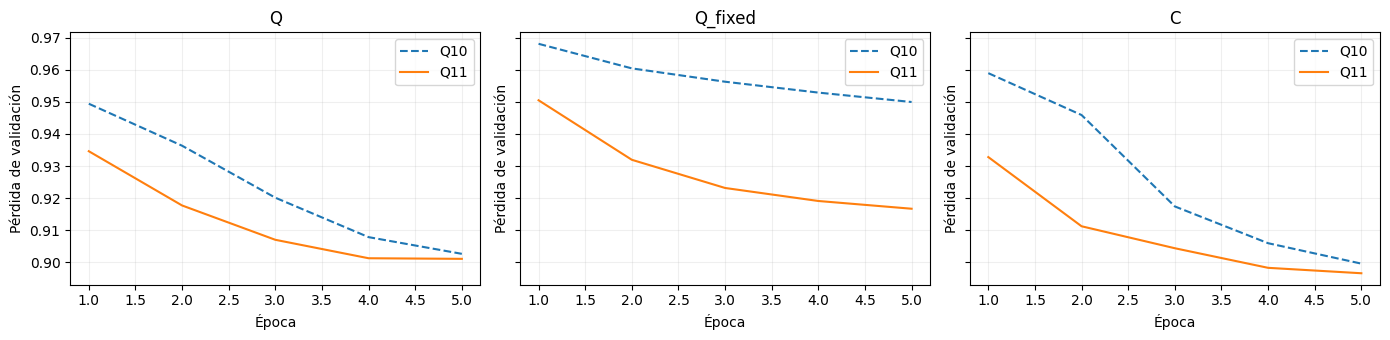

,Variante,Épocas comparadas,Mejor Q10 en ese tramo,Mejor Q11 en ese tramo,Q11 - Q10
0,Q,5,0.902609,0.901047,-0.001562
1,Q_fixed,5,0.949965,0.916677,-0.033288
2,C,5,0.899553,0.896554,-0.003000


,Modelo,Épocas completas,Mejor época,Mejor val,Tiempo acumulado (min)
0,Q11/Q,5,5,0.901047,44.182525
1,Q11/Q_fixed,5,5,0.916677,31.781578
2,Q11/C,5,5,0.896554,0.745614


In [135]:
q11_curve_rows = []
q11_figure, q11_axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

for q11_axis, q11_name in zip(q11_axes, Q11_VARIANTS):
    q11_history = q11_histories[q11_name]
    q11_old_history = q10_histories[q11_name]
    q11_common_epochs = min(len(q11_history['val']), len(q11_old_history['val']))

    if q11_common_epochs == 0:
        raise RuntimeError('Completa al menos una época de cada modelo.')

    q11_epochs = np.arange(1, q11_common_epochs + 1)
    q11_old_values = q11_old_history['val'][:q11_common_epochs]
    q11_new_values = q11_history['val'][:q11_common_epochs]

    q11_axis.plot(q11_epochs, q11_old_values, '--', label='Q10')
    q11_axis.plot(q11_epochs, q11_new_values, label='Q11')
    q11_axis.set(title=q11_name, xlabel='Época', ylabel='Pérdida de validación')
    q11_axis.legend()
    q11_axis.grid(alpha=0.2)
    q11_curve_rows.append({
        'Variante': q11_name,
        'Épocas comparadas': q11_common_epochs,
        'Mejor Q10 en ese tramo': min(q11_old_values),
        'Mejor Q11 en ese tramo': min(q11_new_values),
        'Q11 - Q10': min(q11_new_values) - min(q11_old_values),
    })

q11_figure.tight_layout()
plt.show()
q11_curve_comparison = pd.DataFrame(q11_curve_rows)
display(q11_curve_comparison.round(6))
display(pd.DataFrame([{
    'Modelo': f'Q11/{name}',
    'Épocas completas': state['epochs'],
    'Mejor época': state['best_epoch'],
    'Mejor val': state['best_val'],
    'Tiempo acumulado (min)': sum(state['history']['seconds']) / 60,
} for name, state in q11_states.items()]).round(6))

In [136]:
@torch.no_grad()
def q11_evaluate(model, bin_width=100):
    old_device = next(model.parameters(), torch.empty(0)).device
    was_training = model.training
    names = ('loss', 'v_loss', 'tail_loss')
    totals = dict.fromkeys(names, 0.0)
    bins = {start: dict(n=0, **dict.fromkeys(names, 0.0)) for start in range(0, ldm_scheduler.num_timesteps, bin_width)}
    count = 0

    try:
        model.to(device).eval()

        for index, (z0, labels) in enumerate(q11_val_loader):
            z0, labels = (z0.float().to(device), labels.long().to(device))
            t_cpu, noise_cpu = q11_val_conditions[index]
            t, noise = (t_cpu.to(device), noise_cpu.to(device))
            zt, noise = ldm_scheduler.add_noise(z0, t, noise)
            target = compute_v_target(z0, noise, t, ldm_scheduler)
            prediction = model(zt, t, labels)
            _, parts = latent_v_loss(z0, zt, prediction, target, t, ldm_scheduler)

            for key in names:
                if not torch.isfinite(parts[key]):
                    raise RuntimeError(f'Evaluación no finita en {key}.')

                totals[key] += parts[key].item() * len(z0)

            count += len(z0)

            for start, record in bins.items():
                mask = (t >= start) & (t < start + bin_width)
                n = int(mask.sum().item())

                if n:
                    _, selected = latent_v_loss(z0[mask], zt[mask], prediction[mask], target[mask], t[mask], ldm_scheduler)
                    record['n'] += n

                    for key in names:
                        record[key] += selected[key].item() * n
    finally:
        model.to(old_device).train(was_training)

    if count == 0:
        raise ValueError('Validación vacía.')

    rows = []

    for start, record in bins.items():
        end = min(start + bin_width, ldm_scheduler.num_timesteps)
        rows.append({'t_range': f'{start:03d}-{end - 1:03d}', 'n': record['n'], **{key: record[key] / record['n'] if record['n'] else np.nan for key in names}})

    return ({key: totals[key] / count for key in names}, pd.DataFrame(rows))


@torch.no_grad()
def q11_generate_images(model, initial_noise, class_labels):
    old_device = next(model.parameters()).device
    was_training = model.training
    batches = []

    try:
        model.to(device).eval()

        for start in tqdm(range(0, len(class_labels), Q11_BATCH_SIZE), desc='Generando jets', leave=False):
            stop = start + Q11_BATCH_SIZE
            z = q10_sample_ddim(model, initial_noise[start:stop], class_labels[start:stop], Q11_SAMPLING_STEPS)
            batches.append(q10_decode_standardized(z))
    finally:
        model.to(old_device).train(was_training)

    return torch.cat(batches)

In [137]:
if any((q11_states[name]['epochs'] == 0 for name in Q11_VARIANTS)):
    raise RuntimeError('Entrena las tres variantes Q11 antes de comparar.')

q11_reference_names = {'U-Net Q9': 'U-Net Q9', 'Zero-v': 'Zero-v', 'Q': 'Q10/Q', 'Q_fixed': 'Q10/Q_fixed', 'C': 'Q10/C'}
q11_epochs_by_model = {
    'U-Net Q9': len(globals().get('ldm_history_first', {}).get('train', [])),
    'Zero-v': 0,
    **{f'Q10/{name}': len(history['train']) for name, history in q10_histories.items()},
    **{f'Q11/{name}': state['epochs'] for name, state in q11_states.items()},
}
q11_reference = q10_loss_table[q10_loss_table['Modelo'].isin(q11_reference_names)].copy()
q11_reference['Modelo'] = q11_reference['Modelo'].map(q11_reference_names)
q11_reference['Épocas'] = q11_reference['Modelo'].map(q11_epochs_by_model)
q11_loss_rows = q11_reference.to_dict('records')
q11_reference_bins = q10_bin_table[q10_bin_table['Modelo'].isin(q11_reference_names)].copy()
q11_reference_bins['Modelo'] = q11_reference_bins['Modelo'].map(q11_reference_names)
q11_reference_bins['Épocas'] = q11_reference_bins['Modelo'].map(q11_epochs_by_model)
q11_bin_tables = [q11_reference_bins]

for q11_name in Q11_VARIANTS:
    q11_metrics, q11_bins = q11_evaluate(q11_models[q11_name])
    q11_label = f'Q11/{q11_name}'
    q11_loss_rows.append({'Modelo': q11_label, 'Épocas': q11_states[q11_name]['epochs'], **q11_metrics})
    q11_bins.insert(0, 'Modelo', q11_label)
    q11_bins['Épocas'] = q11_states[q11_name]['epochs']
    q11_bin_tables.append(q11_bins)

q11_angle_rows = []

for q11_name in ('Q', 'Q_fixed'):
    for q11_core_name, q11_initial in q11_initial_angles[q11_name].items():
        q11_final = q11_models[q11_name].cores[q11_core_name].theta.detach().cpu()
        q11_angle_rows.append({
            'Modelo': f'Q11/{q11_name}',
            'Circuito': q11_core_name,
            'Cambio RMS de ángulos': (q11_final - q11_initial).square().mean().sqrt().item(),
        })

q11_reset_model = deepcopy(q11_models['Q'])

with torch.no_grad():
    for q11_core_name, q11_initial in q11_initial_angles['Q'].items():
        q11_reset_model.cores[q11_core_name].theta.copy_(q11_initial)

q11_reset_metrics, _ = q11_evaluate(q11_reset_model)
q11_loss_rows.append({'Modelo': 'Q11/Q con ángulos iniciales', 'Épocas': q11_states['Q']['epochs'], **q11_reset_metrics})
del q11_reset_model
q11_loss_table = pd.DataFrame(q11_loss_rows)[['Modelo', 'Épocas', 'loss', 'v_loss', 'tail_loss']]
q11_bin_table = pd.concat(q11_bin_tables, ignore_index=True)
q11_angle_table = pd.DataFrame(q11_angle_rows)

display(q11_loss_table.round(6))
display(q11_angle_table)
display(q11_bin_table.pivot(index='t_range', columns='Modelo', values='v_loss').round(6))

,Modelo,Épocas,loss,v_loss,tail_loss
0,U-Net Q9,100,0.666561,0.633658,0.219352
1,Zero-v,0,1.047744,0.999843,0.319339
2,Q10/Q,20,0.873301,0.832905,0.269301
3,Q10/Q_fixed,20,0.923740,0.880869,0.285808
4,Q10/C,20,0.853802,0.814291,0.263406
5,Q11/Q,5,0.901047,0.859242,0.278696
6,Q11/Q_fixed,5,0.916677,0.874057,0.284132
7,Q11/C,5,0.896554,0.854981,0.277151
8,Q11/Q con ángulos iniciales,5,12.155294,11.848058,2.048239


,Modelo,Circuito,Cambio RMS de ángulos
0,Q11/Q,content,0.366800
1,Q11/Q,condition,0.162903
2,Q11/Q,fusion,0.309599
3,Q11/Q_fixed,content,0.000000
4,Q11/Q_fixed,condition,0.000000
5,Q11/Q_fixed,fusion,0.000000


Modelo,Q10/C,Q10/Q,Q10/Q_fixed,Q11/C,Q11/Q,Q11/Q_fixed,U-Net Q9,Zero-v
t_range,,,,,,,,
000-099,0.994608,1.000026,1.022821,1.002729,0.985693,0.995399,0.734651,1.000871
100-199,0.941641,0.947712,0.964746,0.923225,0.917266,0.935549,0.544236,1.000128
200-299,0.857973,0.870829,0.896890,0.857194,0.846014,0.864460,0.487198,0.993568
300-399,0.773717,0.797434,0.842998,0.809545,0.800490,0.813756,0.481896,0.999372
400-499,0.758085,0.778891,0.828387,0.799866,0.797486,0.806380,0.552548,0.987138
500-599,0.763077,0.785438,0.844145,0.821631,0.829484,0.838224,0.625597,1.012899
600-699,0.746552,0.773844,0.841654,0.816729,0.837776,0.851131,0.670964,1.009252
700-799,0.767500,0.788298,0.852004,0.840358,0.856718,0.873174,0.733681,1.001956
800-899,0.746028,0.770130,0.835693,0.817706,0.837480,0.858122,0.722677,0.977407


In [138]:
if Q11_NUM_GENERATED < NUM_CLASSES or Q11_NUM_GENERATED % NUM_CLASSES:
    raise ValueError('Q11_NUM_GENERATED debe ser un múltiplo positivo de NUM_CLASSES.')

q11_per_class = Q11_NUM_GENERATED // NUM_CLASSES
q11_generation_rng = torch.Generator().manual_seed(Q11_SEED + 14000)
q11_sample_parts = []

for q11_class_id in range(NUM_CLASSES):
    q11_available = torch.nonzero(ldm_val_labels.cpu() == q11_class_id, as_tuple=True)[0]

    if len(q11_available) < q11_per_class:
        raise ValueError(
            f'Clase {q11_class_id}: hay {len(q11_available)} ejemplos de validación. '
            'Reduce Q11_NUM_GENERATED para mantener el balance sin repetir imágenes.'
        )

    q11_order = torch.randperm(len(q11_available), generator=q11_generation_rng)
    q11_sample_parts.append(q11_available[q11_order[:q11_per_class]])

q11_sample_indices = torch.cat(q11_sample_parts)
q11_order = torch.randperm(len(q11_sample_indices), generator=q11_generation_rng)
q11_sample_indices = q11_sample_indices[q11_order]
q11_generation_labels = ldm_val_labels[q11_sample_indices].long().cpu()
q11_initial_noise = torch.randn(len(q11_sample_indices), *ldm_val_latents.shape[1:], generator=q11_generation_rng)
q11_real_items = [val_dataset[int(index)] for index in q11_sample_indices]
q11_real_labels = torch.tensor([int(item[1]) for item in q11_real_items])

if not torch.equal(q11_real_labels, q11_generation_labels):
    raise ValueError('Las imágenes reales no están alineadas con sus latentes.')

q11_real_images = ((torch.stack([item[0] for item in q11_real_items]).float() + 1.0) / 2.0).clamp(0, 1)
print('Muestras por clase:', torch.unique(q11_generation_labels, return_counts=True))

Muestras por clase: (tensor([0, 1]), tensor([250, 250]))


In [139]:
q11_generated_sets = {'VAE (reconstrucción)': torch.cat([q10_decode_standardized(ldm_val_latents[q11_sample_indices[i:i + Q11_BATCH_SIZE]]) for i in range(
    0, len(q11_sample_indices), Q11_BATCH_SIZE,
)])}
q11_generation_models = {
    'U-Net Q9': ldm_model_first,
    **{f'Q10/{name}': q10_models[name] for name in Q11_VARIANTS},
    **{f'Q11/{name}': q11_models[name] for name in Q11_VARIANTS},
}

for q11_label, q11_model in q11_generation_models.items():
    print(q11_label)
    q11_generated_sets[q11_label] = q11_generate_images(q11_model, q11_initial_noise, q11_generation_labels)

U-Net Q9


Generando jets:   0%|          | 0/63 [00:00<?, ?it/s]

Q10/Q


Generando jets:   0%|          | 0/63 [00:00<?, ?it/s]

Q10/Q_fixed


...

Generando jets:   0%|          | 0/63 [00:00<?, ?it/s]

Q11/Q_fixed


Generando jets:   0%|          | 0/63 [00:00<?, ?it/s]

Q11/C


Generando jets:   0%|          | 0/63 [00:00<?, ?it/s]

In [140]:
q11_real_diagnostics = collect_image_diagnostics(q11_real_images)
q11_global_tables, q11_class_tables = ([], [])

for q11_label, q11_images in q11_generated_sets.items():
    q11_global = summarize_real_vs_generated(q11_real_diagnostics, collect_image_diagnostics(q11_images))
    q11_global.insert(0, 'Modelo', q11_label)
    q11_global.insert(1, 'Épocas', q11_epochs_by_model.get(q11_label, np.nan))
    q11_global_tables.append(q11_global)

    q11_class_table = summarize_generation_by_class(q11_real_images, q11_real_labels, q11_images, q11_generation_labels)
    q11_class_table.insert(0, 'Modelo', q11_label)
    q11_class_table.insert(1, 'Épocas', q11_epochs_by_model.get(q11_label, np.nan))
    q11_class_tables.append(q11_class_table)

q11_physics_table = pd.concat(q11_global_tables, ignore_index=True)
q11_physics_by_class = pd.concat(q11_class_tables, ignore_index=True)
display(q11_physics_table.round(6))
display(q11_physics_by_class.round(6))

Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados


,Modelo,Épocas,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,VAE (reconstrucción),NaN,TRACKER,7.696975,8.149030,5.873164,0.454290,0.041855,0.041731,-0.012402,0.844463,0.854993,0.011904,0.004712,0.010938
1,VAE (reconstrucción),NaN,ECAL,7.563553,7.212652,-4.639375,0.362420,0.052803,0.052584,-0.021875,0.797966,0.796309,0.015053,0.001906,0.003344
2,VAE (reconstrucción),NaN,HCAL,10.206571,10.069214,-1.345768,0.168777,0.044813,0.044768,-0.004492,0.474814,0.484734,0.010905,0.000521,0.001042
3,U-Net Q9,100.0,TRACKER,7.696975,7.153322,-7.063204,0.612944,0.041855,0.035204,-0.665186,0.844463,0.810630,0.036443,0.005698,0.012370
4,U-Net Q9,100.0,ECAL,7.563553,7.202332,-4.775810,0.458671,0.052803,0.049605,-0.319775,0.797966,0.730179,0.067913,0.002487,0.004186
5,U-Net Q9,100.0,HCAL,10.206571,9.983957,-2.181079,0.567953,0.044813,0.052325,0.751221,0.474814,0.485607,0.012847,0.002649,0.004809
6,Q10/Q,20.0,TRACKER,7.696975,13.185536,71.308037,5.712166,0.041855,0.073872,3.201611,0.844463,0.752310,0.109930,0.008738,0.013566
7,Q10/Q,20.0,ECAL,7.563553,8.139628,7.616455,1.671181,0.052803,0.075225,2.242188,0.797966,0.393393,0.405108,0.008693,0.010965
8,Q10/Q,20.0,HCAL,10.206571,8.186451,-19.792345,3.070258,0.044813,0.083247,3.843359,0.474814,0.408436,0.170941,0.007074,0.012156
9,Q10/Q_fixed,20.0,TRACKER,7.696975,13.763275,78.814087,6.281454,0.041855,0.074537,3.268164,0.844463,0.573515,0.271699,0.011278,0.021255


,Modelo,Épocas,Clase,N real,N generado,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,VAE (reconstrucción),NaN,0,250,250,TRACKER,8.397616,8.744715,4.133296,0.357443,0.044096,0.043809,-0.028711,0.827258,0.838062,0.012930,0.004726,0.008819
1,VAE (reconstrucción),NaN,0,250,250,ECAL,8.010080,7.577312,-5.402790,0.436247,0.057282,0.057023,-0.025879,0.766660,0.765319,0.020351,0.001609,0.002946
2,VAE (reconstrucción),NaN,0,250,250,HCAL,10.479799,10.258310,-2.113484,0.248552,0.047986,0.047981,-0.000488,0.439190,0.448307,0.011309,0.000524,0.001050
3,VAE (reconstrucción),NaN,1,250,250,TRACKER,6.996332,7.553347,7.961520,0.557210,0.039615,0.039654,0.003906,0.861667,0.871923,0.012129,0.005060,0.014048
4,VAE (reconstrucción),NaN,1,250,250,ECAL,7.117026,6.847990,-3.780166,0.309040,0.048323,0.048145,-0.017871,0.829272,0.827299,0.014119,0.002205,0.003745
5,VAE (reconstrucción),NaN,1,250,250,HCAL,9.933343,9.880118,-0.535817,0.151356,0.041640,0.041555,-0.008496,0.510438,0.521162,0.011593,0.000528,0.001095
6,U-Net Q9,100.0,0,250,250,TRACKER,8.397616,7.383000,-12.082196,1.024255,0.044096,0.036779,-0.731641,0.827258,0.791339,0.035920,0.005244,0.009593
7,U-Net Q9,100.0,0,250,250,ECAL,8.010080,7.098606,-11.379089,0.924543,0.057282,0.053321,-0.396094,0.766660,0.677959,0.088734,0.003119,0.004357
8,U-Net Q9,100.0,0,250,250,HCAL,10.479799,9.692059,-7.516754,0.884409,0.047986,0.055929,0.794238,0.439190,0.437162,0.012668,0.004013,0.007657
9,U-Net Q9,100.0,1,250,250,TRACKER,6.996332,6.923644,-1.038959,0.296436,0.039615,0.033628,-0.598730,0.861667,0.829922,0.042510,0.006696,0.015907


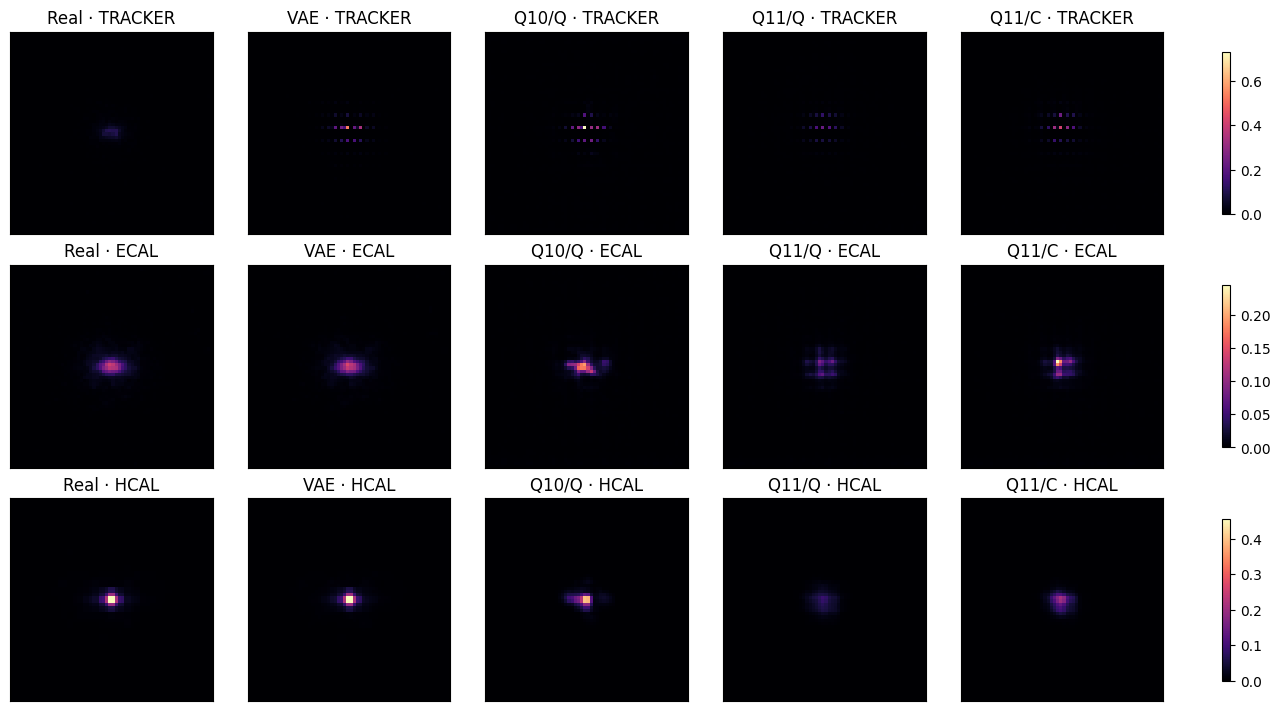

In [141]:
q11_mean_maps = {
    'Real': q11_real_images.mean(0),
    'VAE': q11_generated_sets['VAE (reconstrucción)'].mean(0),
    'Q10/Q': q11_generated_sets['Q10/Q'].mean(0),
    'Q11/Q': q11_generated_sets['Q11/Q'].mean(0),
    'Q11/C': q11_generated_sets['Q11/C'].mean(0),
}
q11_figure, q11_axes = plt.subplots(3, 5, figsize=(13, 7), constrained_layout=True)

for q11_channel, q11_channel_name in enumerate(CHANNEL_NAMES):
    q11_vmax = max((float(values[q11_channel].max()) for values in q11_mean_maps.values()))

    for q11_column, (q11_label, q11_mean) in enumerate(q11_mean_maps.items()):
        q11_axis = q11_axes[q11_channel, q11_column]
        q11_image = q11_axis.imshow(q11_mean[q11_channel].numpy(), cmap='magma', vmin=0, vmax=max(q11_vmax, 1e-08))
        q11_axis.set_title(f'{q11_label} · {q11_channel_name}')
        q11_axis.set_xticks([])
        q11_axis.set_yticks([])

    q11_figure.colorbar(q11_image, ax=q11_axes[q11_channel].tolist(), shrink=0.8)

plt.show()

## Q12 — Extended Training and Entanglement Controls

Q12 extends the Q11 variants to a common 20-epoch budget and adds $Q_{sep}$, a product-state quantum control without CNOT gates. Paired validation losses, circuit resets, swapped-class tests, entanglement diagnostics, DDIM generation, physical observables, and stratified bootstrap intervals are used to distinguish trainable-circuit, conditioning, and entanglement effects.

In [142]:
q12_required = [
    'q11_models', 'q11_states', 'q11_initial_angles', 'q11_setup', 'q11_train_until', 'q11_new_run_state',
    'q11_cpu_copy', 'q11_sync', 'QuantumCoreDenoiser16', 'ExactRYCircuit', 'Q11_CONFIG', 'Q11_SEED',
    'Q11_BATCH_SIZE', 'Q11_LEARNING_RATE', 'Q11_GRAD_CLIP', 'q11_val_loader', 'q11_val_conditions',
    'q11_generated_sets', 'q11_initial_noise', 'q11_generation_labels', 'q11_sample_indices', 'q11_real_images',
    'q11_real_labels', 'q10_sample_ddim', 'q10_decode_standardized', 'ldm_scheduler', 'ldm_val_latents',
    'ldm_val_labels', 'latent_v_loss', 'compute_v_target', 'vae_model', 'latent_mean_train', 'latent_std_train',
    'get_occupancy_thresholds', 'collect_image_diagnostics', 'summarize_real_vs_generated',
    'summarize_generation_by_class', 'wasserstein_distance', 'CHANNEL_NAMES', 'NUM_CLASSES',
    'Q11_SAMPLING_STEPS', 'device',
]
q12_missing = [name for name in q12_required if name not in globals()]

if q12_missing:
    raise RuntimeError(
        'Q12 necesita los objetos vivos del Q11 anterior. Las salidas guardadas '
        'del notebook no contienen los pesos ni el optimizador. Ejecuta aquí en '
        'el mismo kernel donde terminaste Q11. Faltan: '
        + ', '.join(q12_missing)
    )

if any((q11_states[name]['epochs'] < 1 for name in ('Q', 'Q_fixed', 'C'))):
    raise RuntimeError('Primero completa el piloto Q11 de las tres variantes.')

Q12_TARGET_EPOCHS = 20
Q12_BOOTSTRAP_LOSS = 2000
Q12_BOOTSTRAP_PHYSICS = 500
Q12_SAMPLING_STEPS = 50
Q12_VARIANTS = ('Q', 'Q_fixed', 'C', 'Q_sep')
Q12_BIN_WIDTH = 100

if Q11_CONFIG['entangle'] is not True:
    raise ValueError('Esta comparación presupone que Q11/Q utiliza CNOT.')

if NUM_CLASSES < 2:
    raise ValueError('La prueba de condición necesita al menos dos clases.')

if Q12_TARGET_EPOCHS < max((q11_states[name]['epochs'] for name in ('Q', 'Q_fixed', 'C'))):
    raise ValueError('El presupuesto Q12 no puede ser menor que el piloto recibido.')

In [143]:
class Q12ProductRYCircuit(ExactRYCircuit):
    def forward(self, angles):
        if angles.ndim != 2 or angles.shape[1] != self.n_qubits:
            raise ValueError("El circuito espera [N, n_qubits].")

        if self.entangle:
            raise RuntimeError("La fórmula de producto solo vale sin CNOT.")

        return torch.cos(self.depth * angles + self.theta.sum(dim=(0, 1)))


def q12_make_product_control():
    cuda_devices = list(range(torch.cuda.device_count())) if torch.cuda.is_available() else []

    with torch.random.fork_rng(devices=cuda_devices):
        torch.manual_seed(Q11_SEED)
        model = QuantumCoreDenoiser16(**Q11_CONFIG, variant='Q')

        for name, core in list(model.cores.items()):
            expected = q11_initial_angles['Q'][name]

            if not torch.equal(core.theta.detach().cpu(), expected):
                raise RuntimeError('No se pudo reproducir la inicialización Q11.')

            product = Q12ProductRYCircuit(core.n_qubits, core.depth, core.chunk_size, entangle=False)
            product.load_state_dict(core.state_dict())
            model.cores[name] = product

    model.variant = 'Q_sep'
    model.config.update(variant='Q_sep', entangle=False)

    return model


def q12_check_product_formula():
    with torch.random.fork_rng(devices=[]):
        torch.random.default_generator.manual_seed(Q11_SEED + 21000)
        reference = ExactRYCircuit(Q11_CONFIG['n_qubits'], Q11_CONFIG['depth'], entangle=False).double()
        product = Q12ProductRYCircuit(reference.n_qubits, reference.depth, entangle=False).double()
        product.load_state_dict(reference.state_dict())
        x = torch.randn(3, reference.n_qubits, dtype=torch.float64, requires_grad=True)
        y = x.detach().clone().requires_grad_(True)
        a, b = (reference(x), product(y))
        ga = torch.autograd.grad(a.square().sum(), (x, reference.theta))
        gb = torch.autograd.grad(b.square().sum(), (y, product.theta))
        errors = [float((a - b).detach().abs().max())]

        errors.extend((float((u - v).abs().max()) for u, v in zip(ga, gb)))

    if max(errors) > 1e-10:
        raise RuntimeError(f'El control separable no coincide con el simulador: {errors}')

    return pd.DataFrame({'Comprobación': ['Salida <Z>', 'Gradiente entrada', 'Gradiente ángulos'], 'Error máximo': errors})

display(q12_check_product_formula())

,Comprobación,Error máximo
0,Salida <Z>,1.110223e-15
1,Gradiente entrada,9.325873e-15
2,Gradiente ángulos,6.661338e-15


In [144]:
q12_requested_setup = {'q11_setup': deepcopy(q11_setup), 'starting_epochs': {name: q11_states[name]['epochs'] for name in ('Q', 'Q_fixed', 'C')}}

if 'q12_models' not in globals():
    q12_models = {name: deepcopy(q11_models[name]).cpu() for name in ('Q', 'Q_fixed', 'C')}
    q12_states = {name: q11_cpu_copy(q11_states[name]) for name in ('Q', 'Q_fixed', 'C')}
    q12_models['Q_sep'] = q12_make_product_control()
    q12_states['Q_sep'] = q11_new_run_state(q12_models['Q_sep'])
    q12_setup = deepcopy(q12_requested_setup)
    q12_generation_cache = {}
else:
    if globals().get('q12_setup') != q12_requested_setup:
        raise RuntimeError('Ya existe un Q12 con otro punto de partida; se conserva.')

    print('Se reutiliza el progreso Q12; esta celda no reinicializa los modelos.')

q12_parameter_table = pd.DataFrame([{
    'Modelo': name,
    **q12_models[name].parameter_counts(),
    'Épocas al inicio': q12_states[name]['epochs'],
} for name in Q12_VARIANTS])
display(q12_parameter_table)
q12_time_rows = []

for q12_name in ('Q', 'Q_fixed', 'C'):
    q12_seconds = np.mean(q11_states[q12_name]['history']['seconds'][-3:])
    q12_remaining = max(0, Q12_TARGET_EPOCHS - q12_states[q12_name]['epochs'])
    q12_time_rows.append({'Modelo': q12_name, 'Épocas pendientes': q12_remaining, 'Minutos estimados de entrenamiento': q12_seconds * q12_remaining / 60})

display(pd.DataFrame(q12_time_rows).round(1))
print('Estimación basada en tu piloto; no incluye Q_sep, diagnósticos ni generación.')
print('Q_sep conserva 144 ángulos almacenados, pero solo 24 sumas independientes (8 por circuito). No es un control de igual capacidad efectiva.')

,Modelo,total,trainable,quantum_total,quantum_trainable,classical_trainable,Épocas al inicio
0,Q,652,652,144,144,508,5
1,Q_fixed,652,508,144,0,508,5
2,C,685,685,0,0,685,5
3,Q_sep,652,652,144,144,508,0


,Modelo,Épocas pendientes,Minutos estimados de entrenamiento
0,Q,15,132.3
1,Q_fixed,15,95.5
2,C,15,2.2


Estimación basada en tu piloto; no incluye Q_sep, diagnósticos ni generación.
Q_sep conserva 144 ángulos almacenados, pero solo 24 sumas independientes (8 por circuito). No es un control de igual capacidad efectiva.


Q11/Q · seguimiento Q12 6/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/Q · seguimiento Q12 | época 06/20 | train=0.899951 | val=0.895876 | lr=1.00e-03 | tiempo=529.62s


Q11/Q · seguimiento Q12 7/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/Q · seguimiento Q12 | época 07/20 | train=0.896866 | val=0.892698 | lr=1.00e-03 | tiempo=524.20s


Q11/Q · seguimiento Q12 8/20:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Q11/Q_sep · seguimiento Q12 19/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/Q_sep · seguimiento Q12 | época 19/20 | train=0.891288 | val=0.887978 | lr=1.00e-03 | tiempo=7.50s


Q11/Q_sep · seguimiento Q12 20/20:   0%|          | 0/1250 [00:00<?, ?it/s]

Q11/Q_sep · seguimiento Q12 | época 20/20 | train=0.887594 | val=0.886733 | lr=1.00e-03 | tiempo=7.61s
Q11/Q_sep · seguimiento Q12: mejor val=0.886733 en la época 20.


,Modelo,Épocas de presupuesto,Mejor época,Mejor val,Minutos acumulados
0,Q,20,20,0.861606,176.692278
1,Q_fixed,20,20,0.906242,126.036734
2,C,20,20,0.862798,3.043768
3,Q_sep,20,20,0.886733,2.522816


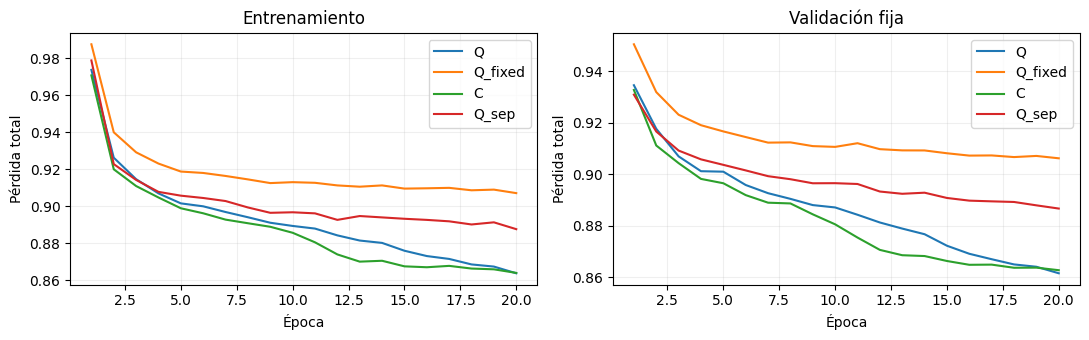

In [145]:
for q12_name in Q12_VARIANTS:
    q11_train_until(q12_models[q12_name], q12_states[q12_name], Q12_TARGET_EPOCHS, f'{q12_name} · seguimiento Q12')

q12_training_table = pd.DataFrame([{
    'Modelo': name,
    'Épocas de presupuesto': state['epochs'],
    'Mejor época': state['best_epoch'],
    'Mejor val': state['best_val'],
    'Minutos acumulados': sum(state['history']['seconds']) / 60,
} for name, state in q12_states.items()])
display(q12_training_table.round(6))
q12_fig, q12_axes = plt.subplots(1, 2, figsize=(11, 3.5))

for q12_name, q12_state in q12_states.items():
    for q12_ax, q12_key in zip(q12_axes, ('train', 'val')):
        q12_values = q12_state['history'][q12_key]
        q12_ax.plot(range(1, len(q12_values) + 1), q12_values, label=q12_name)

for q12_ax, q12_title in zip(q12_axes, ('Entrenamiento', 'Validación fija')):
    q12_ax.set(title=q12_title, xlabel='Época', ylabel='Pérdida total')
    q12_ax.legend()
    q12_ax.grid(alpha=0.2)

q12_fig.tight_layout()
plt.show()

In [146]:
from inspect import signature


@torch.no_grad()
def q12_event_losses(model, swap_classes=False):
    old_device = next(model.parameters()).device
    was_training = model.training
    rows, offset = ([], 0)
    tail_factor = float(signature(latent_v_loss).parameters['tail_loss_weight'].default)

    try:
        model.to(device).eval()

        for batch_index, (z0, labels_cpu) in enumerate(q11_val_loader):
            z0, labels = (z0.float().to(device), labels_cpu.long().to(device))
            t_cpu, noise_cpu = q11_val_conditions[batch_index]
            t, noise = (t_cpu.to(device), noise_cpu.to(device))
            zt, noise = ldm_scheduler.add_noise(z0, t, noise)
            target = compute_v_target(z0, noise, t, ldm_scheduler)
            supplied_labels = (labels + 1) % NUM_CLASSES if swap_classes else labels
            prediction = model(zt, t, supplied_labels)
            a = ldm_scheduler._extract(ldm_scheduler.sqrt_alpha_cum_prod, t, z0.shape)
            b = ldm_scheduler._extract(ldm_scheduler.sqrt_one_minus_alpha_cum_prod, t, z0.shape)
            z0_prediction = a * zt - b * prediction
            weights = 1 + 2 * ((z0.abs() - 2) / 4).clamp(0, 1)
            v = (prediction - target).square().flatten(1).mean(1)
            tail = (weights * F.smooth_l1_loss(z0_prediction, z0, reduction='none')).flatten(1).mean(1)
            total = v + tail_factor * tail

            if not torch.isfinite(total).all():
                raise RuntimeError('Pérdida no finita durante la evaluación Q12.')

            if batch_index == 0:
                original, _ = latent_v_loss(z0, zt, prediction, target, t, ldm_scheduler)
                torch.testing.assert_close(total.mean(), original, rtol=2e-05, atol=2e-06)

            rows.append(pd.DataFrame({
                'id': np.arange(offset, offset + len(z0)),
                'Clase': labels_cpu.cpu().numpy(),
                't': t_cpu.cpu().numpy(),
                'loss': total.cpu().numpy(),
                'v_loss': v.cpu().numpy(),
                'tail_loss': tail.cpu().numpy(),
            }))
            offset += len(z0)
    finally:
        model.to(old_device).train(was_training)

    return pd.concat(rows, ignore_index=True)


def q12_mean_ci(values, classes, repeats, seed):
    values, classes = (np.asarray(values, dtype=float), np.asarray(classes))

    if len(values) == 0 or repeats < 2:
        raise ValueError('Se necesitan datos y al menos dos réplicas bootstrap.')

    rng = np.random.default_rng(seed)
    boot = np.zeros(repeats)

    for class_id in np.unique(classes):
        subset = values[classes == class_id]

        for start in range(0, repeats, 100):
            stop = min(start + 100, repeats)
            indices = rng.integers(len(subset), size=(stop - start, len(subset)))
            boot[start:stop] += subset[indices].sum(axis=1) / len(values)

    lo, hi = np.quantile(boot, [0.025, 0.975])

    return (float(values.mean()), float(lo), float(hi))


def q12_compare_events(first, second, label, by_time=True):
    if not first[['id', 'Clase', 't']].equals(second[['id', 'Clase', 't']]):
        raise ValueError('Las pérdidas no corresponden a los mismos jets/timesteps.')

    groups = [('Global', np.ones(len(first), dtype=bool))]
    groups.extend(((f'Clase {c}', first['Clase'].to_numpy() == c) for c in range(NUM_CLASSES)))

    if by_time:
        groups.extend(((
            f't={start:03d}-{min(start + Q12_BIN_WIDTH, ldm_scheduler.num_timesteps) - 1:03d}',
            (first['t'].to_numpy() >= start) & (first['t'].to_numpy() < start + Q12_BIN_WIDTH),
        ) for start in range(0, ldm_scheduler.num_timesteps, Q12_BIN_WIDTH)))

    result = []

    for group, mask in groups:
        if not mask.any():
            continue

        for metric in ('loss', 'v_loss'):
            delta = first.loc[mask, metric].to_numpy() - second.loc[mask, metric].to_numpy()
            mean, lo, hi = q12_mean_ci(delta, first.loc[mask, 'Clase'].to_numpy(), Q12_BOOTSTRAP_LOSS, Q11_SEED + 22000)
            result.append({
                'Comparación (A - B)': label,
                'Grupo': group,
                'Métrica': metric,
                'N': int(mask.sum()),
                'Diferencia': mean,
                'IC95 inferior': lo,
                'IC95 superior': hi,
            })

    return pd.DataFrame(result)

In [147]:
if any((q12_states[name]['epochs'] != Q12_TARGET_EPOCHS for name in Q12_VARIANTS)):
    raise RuntimeError('Completa el mismo presupuesto de épocas para las cuatro variantes.')

q12_event_tables = {}

for q12_name in Q12_VARIANTS:
    print('Validación por jet:', q12_name)
    q12_event_tables[q12_name] = q12_event_losses(q12_models[q12_name])

q12_loss_table = pd.DataFrame([{
    'Modelo': name,
    'Épocas de presupuesto': q12_states[name]['epochs'],
    'Mejor época': q12_states[name]['best_epoch'],
    **table[['loss', 'v_loss', 'tail_loss']].mean().to_dict(),
} for name, table in q12_event_tables.items()])
q12_loss_contrasts = pd.concat(
    [q12_compare_events(q12_event_tables['Q'], q12_event_tables[name], f'Q - {name}') for name in ('C', 'Q_fixed', 'Q_sep')],
    ignore_index=True,
)
display(q12_loss_table.round(6))
display(q12_loss_contrasts[(q12_loss_contrasts['Grupo'] == 'Global') & (q12_loss_contrasts['Métrica'] == 'loss')].round(6))
q12_time_losses = pd.DataFrame({name: table.groupby(table['t'] // Q12_BIN_WIDTH * Q12_BIN_WIDTH)['v_loss'].mean() for name, table in q12_event_tables.items()})
display(q12_time_losses.round(6))
print('Diferencia Q - control < 0 favorece Q. Los IC describen esta validación y estos pesos; no incluyen variabilidad entre entrenamientos/semillas.')

Validación por jet: Q
Validación por jet: Q_fixed
Validación por jet: C
Validación por jet: Q_sep


,Modelo,Épocas de presupuesto,Mejor época,loss,v_loss,tail_loss
0,Q,20,20,0.861606,0.821363,0.268287
1,Q_fixed,20,20,0.906242,0.864224,0.280121
2,C,20,20,0.862798,0.822775,0.266819
3,Q_sep,20,20,0.886733,0.844808,0.279498


,Comparación (A - B),Grupo,Métrica,N,Diferencia,IC95 inferior,IC95 superior
0,Q - C,Global,loss,2500,-0.001192,-0.002673,0.000340
26,Q - Q_fixed,Global,loss,2500,-0.044636,-0.045890,-0.043331
52,Q - Q_sep,Global,loss,2500,-0.025127,-0.028203,-0.022016


,Q,Q_fixed,C,Q_sep
t,,,,
0,0.974899,1.005393,0.989144,0.994430
100,0.864017,0.934030,0.898796,0.805672
200,0.781042,0.853240,0.817370,0.713748
300,0.733798,0.793872,0.752199,0.703375
400,0.748534,0.789404,0.755671,0.768044
500,0.790792,0.821851,0.782868,0.858161
600,0.800603,0.832655,0.781332,0.885407
700,0.835009,0.864008,0.813153,0.900603
800,0.818380,0.850215,0.794080,0.884156


Diferencia Q - control < 0 favorece Q. Los IC describen esta validación y estos pesos; no incluyen variabilidad entre entrenamientos/semillas.


In [148]:
q12_ablation_tables = {}

for q12_core_name in ('content', 'condition', 'fusion'):
    q12_copy = deepcopy(q12_models['Q']).cpu()

    with torch.no_grad():
        q12_copy.cores[q12_core_name].theta.copy_(q11_initial_angles['Q'][q12_core_name])

    q12_label = f'Reset {q12_core_name} - Q'
    q12_ablation_tables[q12_label] = q12_compare_events(q12_event_losses(q12_copy), q12_event_tables['Q'], q12_label)
    del q12_copy

for q12_name in ('Q', 'C'):
    q12_label = f'Clase cambiada - correcta ({q12_name})'
    q12_ablation_tables[q12_label] = q12_compare_events(q12_event_losses(q12_models[q12_name], swap_classes=True), q12_event_tables[q12_name], q12_label)

q12_ablation_table = pd.concat(q12_ablation_tables.values(), ignore_index=True)
display(q12_ablation_table[(q12_ablation_table['Grupo'] == 'Global') & (q12_ablation_table['Métrica'] == 'loss')].round(6))
print('Aquí un delta positivo significa que la intervención empeora la pérdida. Un reset grande también rompe la adaptación con las interfaces clásicas.')

,Comparación (A - B),Grupo,Métrica,N,Diferencia,IC95 inferior,IC95 superior
0,Reset content - Q,Global,loss,2500,4.232099,4.128856,4.345427
26,Reset condition - Q,Global,loss,2500,0.188843,0.182139,0.195449
52,Reset fusion - Q,Global,loss,2500,15.280992,15.104881,15.453899
78,Clase cambiada - correcta (Q),Global,loss,2500,0.001600,0.001294,0.001906
104,Clase cambiada - correcta (C),Global,loss,2500,0.001130,0.000787,0.001458


Aquí un delta positivo significa que la intervención empeora la pérdida. Un reset grande también rompe la adaptación con las interfaces clásicas.


In [149]:
@torch.no_grad()
def q12_entanglement_probe(model, max_states=32):
    probe = deepcopy(model).cpu().eval()
    captured, handles = ({}, [])

    def capture(name):

        def hook(module, args):
            captured[name] = args[0][:max_states].detach().cpu().double()

        return hook

    try:
        for name, core in probe.cores.items():
            handles.append(core.register_forward_pre_hook(capture(name)))

        z0, labels = next(iter(q11_val_loader))
        t, noise = q11_val_conditions[0]
        zt, _ = ldm_scheduler.add_noise(z0.to(device), t.to(device), noise.to(device))

        probe(zt.cpu(), t.cpu(), labels.cpu())
    finally:
        for handle in handles:
            handle.remove()

    rows = []

    for name, angles in captured.items():
        core = probe.cores[name].double()

        for entangle in (True, False):
            core.entangle = entangle
            state = core.statevector(angles)
            state = state / state.norm(dim=1, keepdim=True)
            matrix = state.reshape(len(state), 2 ** (core.n_qubits // 2), -1)
            rho = matrix @ matrix.transpose(-1, -2)
            entropy = 1 - rho.square().sum(dim=(-2, -1))

            rows.append({
                'Circuito': name,
                'CNOT': entangle,
                'N estados': len(state),
                'Entropía lineal media': entropy.mean().item(),
                'Fracción > 1e-6': (entropy > 1e-06).double().mean().item(),
            })

    return pd.DataFrame(rows)

q12_entanglement_table = q12_entanglement_probe(q12_models['Q'])
display(q12_entanglement_table.round(6))
print('Entropía positiva confirma entrelazamiento en este corte y estas entradas. Por sí sola no demuestra que mejore la generación ni ventaja computacional.')

,Circuito,CNOT,N estados,Entropía lineal media,Fracción > 1e-6
0,content,True,32,0.762598,1.0
1,content,False,32,-0.000000,0.0
2,condition,True,8,0.669333,1.0
3,condition,False,8,0.000000,0.0
4,fusion,True,32,0.805426,1.0
5,fusion,False,32,-0.000000,0.0


Entropía positiva confirma entrelazamiento en este corte y estas entradas. Por sí sola no demuestra que mejore la generación ni ventaja computacional.


In [150]:
import hashlib


def q12_tensor_digest(tensors):
    digest = hashlib.sha256()

    for tensor in tensors:
        cpu = tensor.detach().cpu().contiguous()
        digest.update(str((tuple(cpu.shape), str(cpu.dtype))).encode())
        digest.update(cpu.numpy().tobytes())

    return digest.hexdigest()


@torch.no_grad()
def q12_generate(model):
    old_device, was_training = (next(model.parameters()).device, model.training)
    images, latents = ([], [])

    try:
        model.to(device).eval()

        for start in tqdm(range(0, len(q11_generation_labels), Q11_BATCH_SIZE), desc='Q12: mismos 500 jets/ruidos', leave=False):
            stop = start + Q11_BATCH_SIZE
            z = q10_sample_ddim(model, q11_initial_noise[start:stop], q11_generation_labels[start:stop], Q12_SAMPLING_STEPS)

            if not torch.isfinite(z).all():
                raise RuntimeError('Se generaron latentes no finitos.')

            latents.append(z.cpu())
            images.append(q10_decode_standardized(z))
    finally:
        model.to(old_device).train(was_training)

    return {'images': torch.cat(images), 'latents': torch.cat(latents)}

if not torch.equal(q11_real_labels.cpu(), q11_generation_labels.cpu()):
    raise ValueError('Las clases reales y el banco generado no coinciden.')

if Q12_SAMPLING_STEPS != Q11_SAMPLING_STEPS:
    raise ValueError('Conserva los pasos DDIM del piloto para reutilizar sus imágenes.')

q12_bank_digest = q12_tensor_digest([q11_initial_noise, q11_generation_labels, q11_sample_indices])
q12_decoder_digest = q12_tensor_digest([
    *vae_model.state_dict().values(), latent_mean_train, latent_std_train,
    get_occupancy_thresholds(torch.zeros(1, len(CHANNEL_NAMES), 1, 1)), ldm_scheduler.sqrt_alpha_cum_prod,
    ldm_scheduler.sqrt_one_minus_alpha_cum_prod,
])
q12_generated = {}

for q12_name in Q12_VARIANTS:
    q12_key = (q12_name, Q12_SAMPLING_STEPS, q12_bank_digest, q12_decoder_digest, q12_tensor_digest(q12_models[q12_name].state_dict().values()))

    if q12_key not in q12_generation_cache:
        print('Generando:', q12_name)
        q12_generation_cache[q12_key] = q12_generate(q12_models[q12_name])
    else:
        print('Se reutiliza la generación del mismo modelo/banco:', q12_name)

    q12_generated[q12_name] = q12_generation_cache[q12_key]

print('Banco compartido:', len(q11_generation_labels), 'jets;', Q12_SAMPLING_STEPS, 'pasos DDIM.')

Generando: Q


Q12: mismos 500 jets/ruidos:   0%|          | 0/63 [00:00<?, ?it/s]

Generando: Q_fixed


Q12: mismos 500 jets/ruidos:   0%|          | 0/63 [00:00<?, ?it/s]

Generando: C


Q12: mismos 500 jets/ruidos:   0%|          | 0/63 [00:00<?, ?it/s]

Generando: Q_sep


Q12: mismos 500 jets/ruidos:   0%|          | 0/63 [00:00<?, ?it/s]

Banco compartido: 500 jets; 50 pasos DDIM.


In [151]:
q12_real_diag = collect_image_diagnostics(q11_real_images)
q12_global_tables, q12_class_tables = ([], [])
q12_image_sets = {
    'VAE (reconstrucción)': q11_generated_sets['VAE (reconstrucción)'],
    'U-Net Q9': q11_generated_sets['U-Net Q9'],
    **{f'Piloto/{name}': q11_generated_sets[f'Q11/{name}'] for name in ('Q', 'Q_fixed', 'C')},
    **{f'Ampliado/{name}': result['images'] for name, result in q12_generated.items()},
}

for q12_label, q12_images in q12_image_sets.items():
    q12_table = summarize_real_vs_generated(q12_real_diag, collect_image_diagnostics(q12_images))
    q12_table.insert(0, 'Modelo', q12_label)
    q12_global_tables.append(q12_table)

    if q12_label.startswith('Ampliado/'):
        q12_by_class = summarize_generation_by_class(q11_real_images, q11_real_labels, q12_images, q11_generation_labels)
        q12_by_class.insert(0, 'Modelo', q12_label)
        q12_class_tables.append(q12_by_class)

q12_physics_table = pd.concat(q12_global_tables, ignore_index=True)
q12_physics_by_class = pd.concat(q12_class_tables, ignore_index=True)
display(q12_physics_table[['Modelo', 'Canal', 'Bias E (%)', 'W1 energía', 'Diferencia activa (p.p.)', 'W1 máximo', 'Radial L1']].round(6))
display(q12_physics_by_class[['Modelo', 'Clase', 'Canal', 'Bias E (%)', 'W1 energía', 'Radial L1']].round(6))
q12_latent_rows = []

for q12_label, q12_z in {
    'Validación real': ldm_val_latents[q11_sample_indices].cpu(),
    **{name: result['latents'] for name, result in q12_generated.items()},
}.items():
    for q12_channel in range(q12_z.shape[1]):
        q12_values = q12_z[:, q12_channel].float().flatten()
        q12_latent_rows.append({
            'Modelo': q12_label,
            'Canal latente': q12_channel,
            'Media': q12_values.mean().item(),
            'Desv. estándar': q12_values.std(unbiased=False).item(),
            'P99 |z|': torch.quantile(q12_values.abs(), 0.99).item(),
            'Fracción |z| > 2': (q12_values.abs() > 2).float().mean().item(),
        })

q12_latent_table = pd.DataFrame(q12_latent_rows)
display(q12_latent_table.round(5))
print('E es intensidad integrada en las unidades normalizadas del notebook, no GeV. Los canales latentes no se identifican uno a uno con TRACKER/ECAL/HCAL.')

Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados
Clase 0: 250 reales | 250 generados
Clase 1: 250 reales | 250 generados


,Modelo,Canal,Bias E (%),W1 energía,Diferencia activa (p.p.),W1 máximo,Radial L1
0,VAE (reconstrucción),TRACKER,5.873164,0.454290,-0.012402,0.011904,0.004712
1,VAE (reconstrucción),ECAL,-4.639375,0.362420,-0.021875,0.015053,0.001906
2,VAE (reconstrucción),HCAL,-1.345768,0.168777,-0.004492,0.010905,0.000521
3,U-Net Q9,TRACKER,-7.063204,0.612944,-0.665186,0.036443,0.005698
4,U-Net Q9,ECAL,-4.775810,0.458671,-0.319775,0.067913,0.002487
5,U-Net Q9,HCAL,-2.181079,0.567953,0.751221,0.012847,0.002649
6,Piloto/Q,TRACKER,23.713076,2.067864,2.167920,0.394014,0.012531
7,Piloto/Q,ECAL,-19.466906,1.559305,0.942627,0.484294,0.011570
8,Piloto/Q,HCAL,-47.947376,4.898283,3.391602,0.288885,0.014886
9,Piloto/Q_fixed,TRACKER,42.432449,3.493125,2.599170,0.349811,0.012580


,Modelo,Clase,Canal,Bias E (%),W1 energía,Radial L1
0,Ampliado/Q,0,TRACKER,18.119799,1.988744,0.006802
1,Ampliado/Q,0,ECAL,-5.986092,1.013599,0.010200
2,Ampliado/Q,0,HCAL,-23.765856,2.492122,0.017103
3,Ampliado/Q,1,TRACKER,48.246368,3.377230,0.008409
4,Ampliado/Q,1,ECAL,14.714404,1.152987,0.010075
5,Ampliado/Q,1,HCAL,-8.444445,1.185605,0.012104
6,Ampliado/Q_fixed,0,TRACKER,36.611015,3.532643,0.010063
7,Ampliado/Q_fixed,0,ECAL,-0.521236,0.778854,0.009650
8,Ampliado/Q_fixed,0,HCAL,-17.118362,1.814072,0.018219
9,Ampliado/Q_fixed,1,TRACKER,67.379868,4.714119,0.012353


,Modelo,Canal latente,Media,Desv. estándar,P99 |z|,Fracción |z| > 2
0,Validación real,0,-0.00458,0.99329,3.77726,0.02773
1,Validación real,1,0.00039,1.00431,3.96945,0.03023
2,Validación real,2,0.00049,1.00157,3.56929,0.04691
3,Validación real,3,-0.01067,0.99187,3.82748,0.05034
4,Q,0,-0.06791,0.96305,3.61353,0.02546
5,Q,1,-0.01673,0.97457,3.45835,0.03977
6,Q,2,-0.01788,0.97931,2.57262,0.04159
7,Q,3,-0.01623,0.98987,2.67544,0.04188
8,Q_fixed,0,-0.02869,1.10458,3.53716,0.04851
9,Q_fixed,1,-0.01118,1.02650,3.10478,0.04526


E es intensidad integrada en las unidades normalizadas del notebook, no GeV. Los canales latentes no se identifican uno a uno con TRACKER/ECAL/HCAL.


In [152]:
def q12_event_observables(images):
    images = images.detach().float().cpu()
    n, channels, height, width = images.shape
    yy, xx = torch.meshgrid(torch.arange(height).float(), torch.arange(width).float(), indexing='ij')
    radius = ((yy - (height - 1) / 2) ** 2 + (xx - (width - 1) / 2) ** 2).sqrt()
    edges = torch.linspace(0, radius.max().item() + 1e-06, 33)
    bins = (torch.bucketize(radius.flatten(), edges, right=False) - 1).clamp(0, 31)
    radial = torch.zeros(n, channels, 32, dtype=torch.float64)

    radial.scatter_add_(2, bins[None, None].expand(n, channels, -1), images.flatten(2).double())

    return {
        'energy': images.sum((-2, -1)).double().numpy(),
        'active': (images > 0.0001).float().mean((-2, -1)).double().numpy(),
        'maximum': images.amax((-2, -1)).double().numpy(),
        'radial': radial.numpy(),
    }


def q12_observable_errors(real, generated, real_indices, gen_indices):
    values = []

    for channel in range(len(CHANNEL_NAMES)):
        r = real['energy'][real_indices, channel]
        g = generated['energy'][gen_indices, channel]
        rp = real['radial'][real_indices, channel].sum(0)
        gp = generated['radial'][gen_indices, channel].sum(0)
        rp, gp = (rp / max(rp.sum(), 1e-12), gp / max(gp.sum(), 1e-12))

        values.append([
            abs(100 * (g.mean() - r.mean()) / max(r.mean(), 1e-12)), wasserstein_distance(r, g),
            abs(100 * (generated['active'][gen_indices, channel].mean() - real['active'][real_indices, channel].mean())),
            wasserstein_distance(real['maximum'][real_indices, channel], generated['maximum'][gen_indices, channel]),
            np.abs(gp - rp).mean(),
        ])

    return np.asarray(values)


def q12_bootstrap_physics(real, first, second, labels, comparison):
    labels = np.asarray(labels)
    groups = [('Global balanceado', np.arange(len(labels)))]
    groups += [(f'Clase {c}', np.flatnonzero(labels == c)) for c in range(NUM_CLASSES)]
    names = ('|Bias E| (%)', 'W1 energía', '|Diferencia activa| (p.p.)', 'W1 máximo', 'Radial L1')
    rows = []

    for group_name, indices in groups:
        rng = np.random.default_rng(Q11_SEED + 23000)
        point = q12_observable_errors(real, first, indices, indices) - q12_observable_errors(real, second, indices, indices)
        strata = [indices[labels[indices] == c] for c in np.unique(labels[indices])]
        boot = []

        for _ in range(Q12_BOOTSTRAP_PHYSICS):
            ri = np.concatenate([rng.choice(s, len(s), replace=True) for s in strata])
            gi = np.concatenate([rng.choice(s, len(s), replace=True) for s in strata])
            boot.append(q12_observable_errors(real, first, ri, gi) - q12_observable_errors(real, second, ri, gi))

        lo, hi = np.quantile(boot, [0.025, 0.975], axis=0)

        for channel, channel_name in enumerate(CHANNEL_NAMES):
            for metric, metric_name in enumerate(names):
                rows.append({
                    'Comparación (A - B)': comparison,
                    'Grupo': group_name,
                    'Canal': channel_name,
                    'Métrica': metric_name,
                    'Diferencia': point[channel, metric],
                    'IC95 inferior': lo[channel, metric],
                    'IC95 superior': hi[channel, metric],
                })

    return pd.DataFrame(rows)

q12_observables = {name: q12_event_observables(result['images']) for name, result in q12_generated.items()}
q12_real_observables = q12_event_observables(q11_real_images)
q12_physics_contrasts = pd.concat(
    [q12_bootstrap_physics(
        q12_real_observables, q12_observables['Q'], q12_observables[name], q11_generation_labels.cpu().numpy(),
        f'Q - {name}',
    ) for name in ('C', 'Q_fixed', 'Q_sep')],
    ignore_index=True,
)

display(q12_physics_contrasts[(q12_physics_contrasts['Grupo'] == 'Global balanceado') & q12_physics_contrasts['Métrica'].isin([
    'W1 energía', 'Radial L1',
])].round(6))
print('Delta negativo favorece Q. IC puntuales y exploratorios, sin corrección por comparaciones múltiples; tampoco incluyen variabilidad entre semillas.')

,Comparación (A - B),Grupo,Canal,Métrica,Diferencia,IC95 inferior,IC95 superior
1,Q - C,Global balanceado,TRACKER,W1 energía,-0.283621,-0.362532,-0.211663
4,Q - C,Global balanceado,TRACKER,Radial L1,-0.001248,-0.001709,-0.000773
6,Q - C,Global balanceado,ECAL,W1 energía,0.055232,-0.028565,0.131030
9,Q - C,Global balanceado,ECAL,Radial L1,-0.000328,-0.001659,0.000931
11,Q - C,Global balanceado,HCAL,W1 energía,0.296899,0.012027,0.492919
14,Q - C,Global balanceado,HCAL,Radial L1,0.002052,0.001703,0.002433
46,Q - Q_fixed,Global balanceado,TRACKER,W1 energía,-1.435137,-1.517388,-1.359117
49,Q - Q_fixed,Global balanceado,TRACKER,Radial L1,-0.003512,-0.004117,-0.002725
51,Q - Q_fixed,Global balanceado,ECAL,W1 energía,0.070720,-0.044464,0.169799
54,Q - Q_fixed,Global balanceado,ECAL,Radial L1,-0.002118,-0.002660,-0.001407


Delta negativo favorece Q. IC puntuales y exploratorios, sin corrección por comparaciones múltiples; tampoco incluyen variabilidad entre semillas.


,Modelo,Canal,Media clase 0,Media clase 1,Clase 1 - clase 0
0,Real,TRACKER,8.397617,6.996332,-1.401285
1,Real,ECAL,8.010080,7.117026,-0.893054
2,Real,HCAL,10.479799,9.933343,-0.546456
3,Q,TRACKER,9.919248,10.371808,0.452561
4,Q,ECAL,7.530589,8.164253,0.633664
5,Q,HCAL,7.989185,9.094527,1.105341
6,Q_fixed,TRACKER,11.472068,11.710452,0.238384
7,Q_fixed,ECAL,7.968329,7.960226,-0.008103
8,Q_fixed,HCAL,8.685829,8.251066,-0.434764
9,C,TRACKER,10.279506,10.591655,0.312150


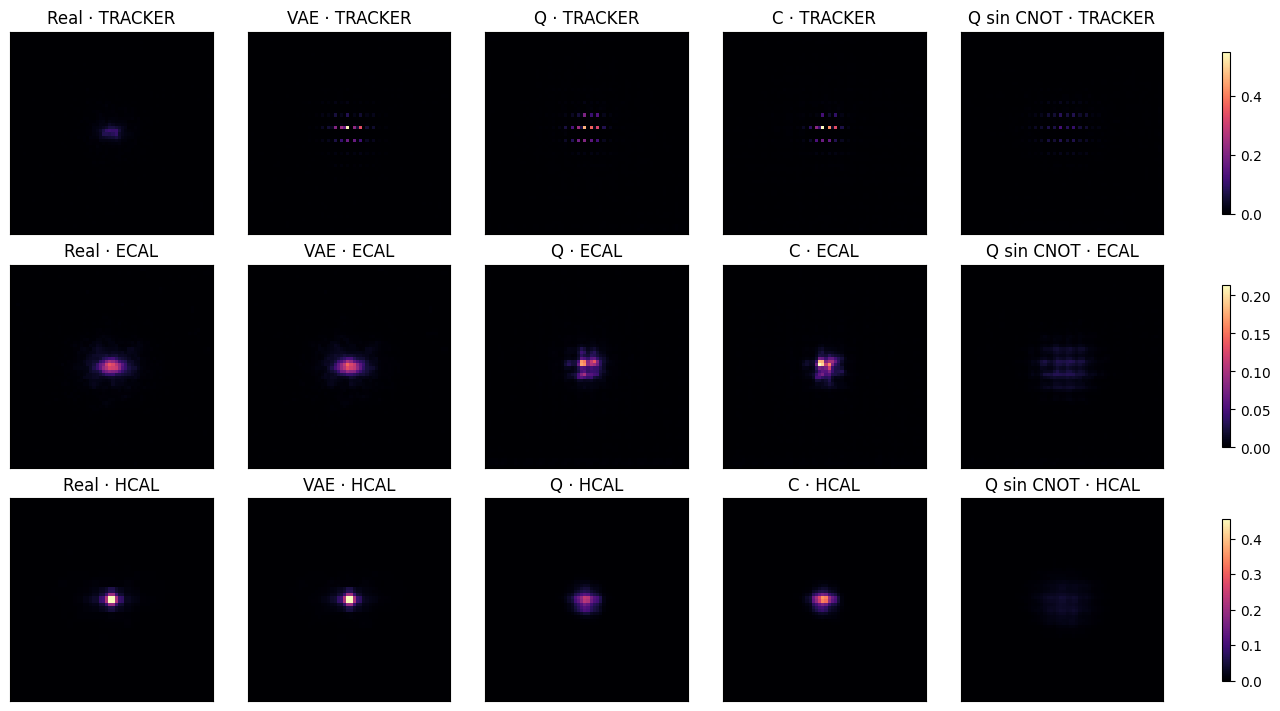

In [153]:
q12_class_rows = []

if NUM_CLASSES == 2:
    for q12_name, q12_obs in {'Real': q12_real_observables, **q12_observables}.items():
        q12_labels_np = q11_generation_labels.cpu().numpy()

        for q12_channel, q12_channel_name in enumerate(CHANNEL_NAMES):
            q12_e0 = q12_obs['energy'][q12_labels_np == 0, q12_channel].mean()
            q12_e1 = q12_obs['energy'][q12_labels_np == 1, q12_channel].mean()
            q12_class_rows.append({
                'Modelo': q12_name,
                'Canal': q12_channel_name,
                'Media clase 0': q12_e0,
                'Media clase 1': q12_e1,
                'Clase 1 - clase 0': q12_e1 - q12_e0,
            })

q12_class_contrast = pd.DataFrame(q12_class_rows)
display(q12_class_contrast.round(6))
q12_maps = {
    'Real': q11_real_images.mean(0),
    'VAE': q11_generated_sets['VAE (reconstrucción)'].mean(0),
    'Q': q12_generated['Q']['images'].mean(0),
    'C': q12_generated['C']['images'].mean(0),
    'Q sin CNOT': q12_generated['Q_sep']['images'].mean(0),
}
q12_fig, q12_axes = plt.subplots(3, 5, figsize=(13, 7), constrained_layout=True)

for q12_channel, q12_channel_name in enumerate(CHANNEL_NAMES):
    q12_vmax = max((float(values[q12_channel].max()) for values in q12_maps.values()))

    for q12_column, (q12_name, q12_mean) in enumerate(q12_maps.items()):
        q12_axis = q12_axes[q12_channel, q12_column]
        q12_image = q12_axis.imshow(q12_mean[q12_channel].numpy(), cmap='magma', vmin=0, vmax=max(q12_vmax, 1e-08))
        q12_axis.set_title(f'{q12_name} · {q12_channel_name}')
        q12_axis.set_xticks([])
        q12_axis.set_yticks([])

    q12_fig.colorbar(q12_image, ax=q12_axes[q12_channel].tolist(), shrink=0.8)

plt.show()